# LIBERO environment analysis lab

This notebook is a small, model-free lab for understanding the same interfaces used by:

- `scripts/inspect_libero_outputs.py` (observations and HDF5 structure)
- `scripts/replay_libero_demo_actions.py` (raw demonstration replay)
- `scripts/rollout_libero_rdt.py` (live policy rollout)

Run the cells in order. Start with static dataset inspection, then create a live simulator, and only then replay actions. No RDT checkpoint is loaded.

## 1. Setup

Use this repository's `.venv` as the notebook kernel. In VS Code, select `/home/ubuntu/ThinkFlow-RDT-1B/.venv/bin/python`. For browser Jupyter, install the optional UI once with `.venv/bin/pip install jupyterlab`, then launch from the repository with `.venv/bin/jupyter lab`. The environment variables must be set before importing MuJoCo/robosuite.

In [1]:
import os
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp/thinkflow-cache")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/thinkflow-matplotlib")

import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "scripts").exists():
            return candidate
    raise RuntimeError("Start Jupyter from inside the ThinkFlow-RDT-1B repository")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
LIBERO_ROOT = Path("/home/ubuntu/LIBERO")
for path in (LIBERO_ROOT, REPO_ROOT / "src", REPO_ROOT / "scripts"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

from inspect_libero_outputs import (
    install_robosuite_mujoco_compatibility,
    summarize_mapping,
)
from replay_libero_demo_actions import action_stats, find_demo_file, select_demo
from thinkflow_rdt.adapters.libero import (
    libero_image_to_rgb,
    libero_observation_to_rdt,
    libero_orientation_to_rpy,
)

install_robosuite_mujoco_compatibility()
print("Repository:", REPO_ROOT)
print("Python:", sys.executable)
print("LIBERO source:", LIBERO_ROOT)

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)


Repository: /home/ubuntu/ThinkFlow-RDT-1B
Python: /home/ubuntu/ThinkFlow-RDT-1B/.venv/bin/python
LIBERO source: /home/ubuntu/LIBERO


## 2. Choose a suite, task, and demonstration

Valid suites are `libero_spatial`, `libero_object`, `libero_goal`, `libero_10`, and `libero_90`. Change these values and rerun downward.

In [6]:
SUITE_NAME = "libero_object"
TASK_ID = 7
DEMO_NAME = None  # None selects the first demo in the task file
INIT_STATE_INDEX = 0
CAMERA_SIZE = 128

DATASET_DIR = REPO_ROOT / "libero-dataset" / SUITE_NAME
assert LIBERO_ROOT.exists(), f"Missing LIBERO checkout: {LIBERO_ROOT}"
assert DATASET_DIR.exists(), f"Missing demonstrations: {DATASET_DIR}"

In [7]:
from libero.libero.benchmark import get_benchmark

benchmark = get_benchmark(SUITE_NAME)(0)
tasks = [benchmark.get_task(i) for i in range(benchmark.n_tasks)]
for i, item in enumerate(tasks):
    print(f"{i:2d}  {item.language}")

task = tasks[TASK_ID]
demo_path = find_demo_file(DATASET_DIR, task_name=task.name)
print("\nSelected task:", task.name)
print("Instruction:  ", task.language)
print("Demo file:    ", demo_path)

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
 0  pick up the alphabet soup and place it in the basket
 1  pick up the cream cheese and place it in the basket
 2  pick up the salad dressing and place it in the basket
 3  pick up the bbq sauce and place it in the basket
 4  pick up the ketchup and place it in the basket
 5  pick up the tomato sauce and place it in the basket
 6  pick up the butter and place it in the basket
 7  pick up the milk and place it in the basket
 8  pick up the chocolate pudding and place it in the basket
 9  pick up the orange juice and place it in the basket

Selected task: pick_up_the_milk_and_place_it_in_the_basket
Instruction:   pick up the milk and place it in the basket
Demo file:     /home/ubuntu/ThinkFlow-RDT-1B/libero-dataset/libero_object/pick_up_the_milk_and_place_it_in_the_basket_demo.hdf5


## 3. Inspect the HDF5 demonstration

A demo normally contains simulator `states`, 7-D controller `actions`, and an `obs` group. The controller action is `[dx, dy, dz, drx, dry, drz, gripper]`, where **+1 opens** and **-1 closes** the gripper.

In [8]:
with h5py.File(demo_path, "r") as handle:
    selected_demo_name, demo = select_demo(handle, DEMO_NAME)
    print("Root keys:", list(handle.keys()))
    print("Demo:", selected_demo_name)
    print("Demo keys:", list(demo.keys()))
    print("Observation keys:", sorted(demo["obs"].keys()))
    attrs = dict(demo.attrs)
    if "model_file" in attrs:
        attrs["model_file"] = f"<MuJoCo XML: {len(attrs['model_file']):,} characters>"
    print("Attributes:", attrs)
    actions = np.asarray(demo["actions"], dtype=np.float32)[:, :7]
    simulator_states = np.asarray(demo["states"], dtype=np.float64)
    obs_shapes = {key: tuple(value.shape) for key, value in demo["obs"].items()}

print("Actions:", actions.shape)
print("Simulator states:", simulator_states.shape)
display(obs_shapes)
display(action_stats(actions))

Root keys: ['data']
Demo: demo_0
Demo keys: ['actions', 'dones', 'obs', 'rewards', 'robot_states', 'states']
Observation keys: ['agentview_rgb', 'ee_ori', 'ee_pos', 'ee_states', 'eye_in_hand_rgb', 'gripper_states', 'joint_states']
Attributes: {'init_state': array([ 2.50000000e-01,  2.66595152e-03, -1.62370073e-01, -2.45249473e-02,
       -2.45263594e+00,  1.87589130e-02,  2.19695967e+00,  8.10475545e-01,
        3.40349674e-02, -3.40649449e-02, -1.21042064e-01, -2.38814422e-01,
        6.71277175e-02,  4.99985641e-01,  5.00014392e-01,  4.99990653e-01,
        5.00009313e-01,  1.06022842e-02,  2.45721241e-01, -4.58262675e-03,
        7.07104752e-01, -1.69384343e-03,  1.69371900e-03,  7.07104753e-01,
        4.85320954e-02, -9.98939031e-02,  8.92147605e-03,  1.60411515e-10,
       -3.16300943e-07, -1.06977855e-06,  1.00000000e+00, -1.49761042e-01,
        6.00616533e-02,  3.83925827e-02, -2.26091850e-03,  2.26138195e-03,
        7.07684121e-01,  7.06521733e-01,  9.66811913e-02, -1.957245

{'agentview_rgb': (150, 128, 128, 3),
 'ee_ori': (150, 3),
 'ee_pos': (150, 3),
 'ee_states': (150, 6),
 'eye_in_hand_rgb': (150, 128, 128, 3),
 'gripper_states': (150, 2),
 'joint_states': (150, 7)}

{'shape': [150, 7],
 'min': [-0.5169642567634583,
  -0.8598214387893677,
  -0.7258928418159485,
  -0.051428571343421936,
  -0.05892857164144516,
  -0.07928571105003357,
  -1.0],
 'max': [0.4955357015132904,
  0.8196428418159485,
  0.9375,
  0.07500000298023224,
  0.10821428894996643,
  0.09107142686843872,
  1.0],
 'mean': [0.058321431279182434,
  0.12530356645584106,
  -0.07466071844100952,
  0.007928570732474327,
  0.02052856795489788,
  0.0022571419831365347,
  0.2666666805744171],
 'std': [0.2566051185131073,
  0.493630975484848,
  0.4137324392795563,
  0.023636598140001297,
  0.04631383344531059,
  0.039589956402778625,
  0.9637897610664368],
 'gripper_command_counts': {'open_plus_1': 95, 'close_minus_1': 55, 'zero': 0}}

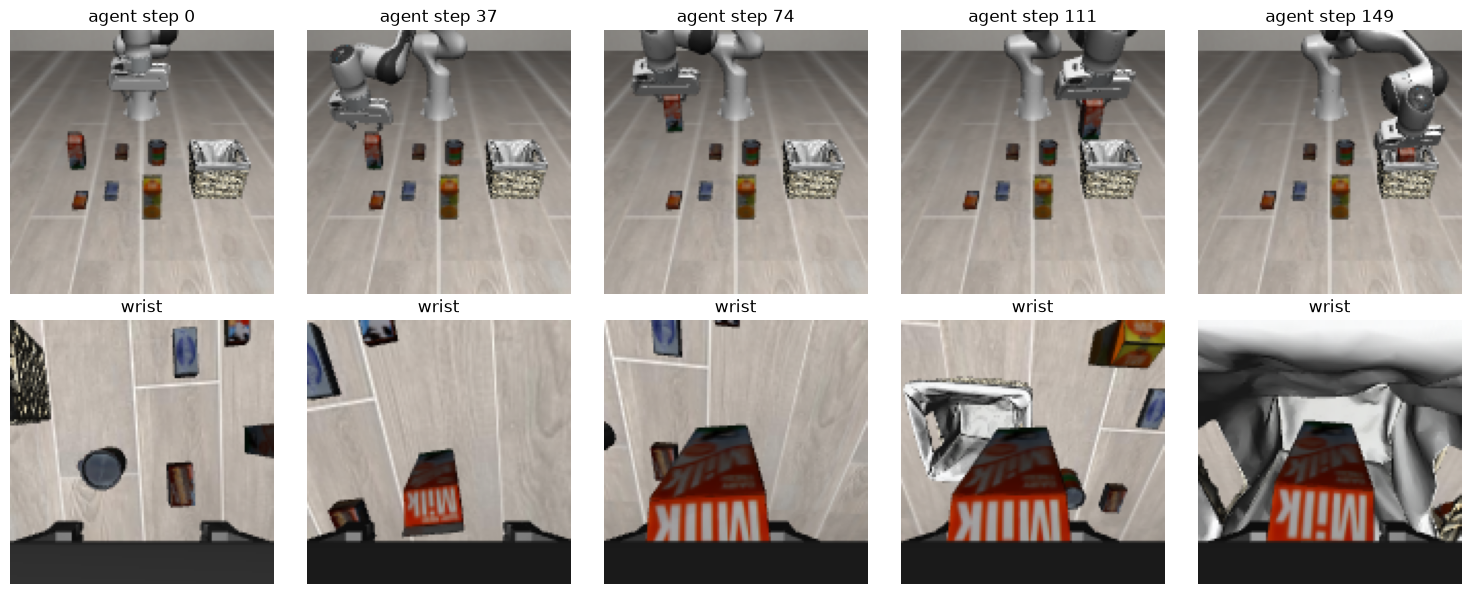

In [9]:
with h5py.File(demo_path, "r") as handle:
    _, demo = select_demo(handle, selected_demo_name)
    obs = demo["obs"]
    primary_key = "agentview_rgb" if "agentview_rgb" in obs else "agentview_image"
    wrist_key = next((k for k in ("eye_in_hand_rgb", "robot0_eye_in_hand_image") if k in obs), None)
    indices = np.linspace(0, len(actions) - 1, 5, dtype=int)
    primary_frames = libero_image_to_rgb(obs[primary_key][indices])
    wrist_frames = None if wrist_key is None else libero_image_to_rgb(obs[wrist_key][indices])

rows = 2 if wrist_frames is not None else 1
fig, axes = plt.subplots(rows, len(indices), figsize=(15, 3 * rows), squeeze=False)
for col, step in enumerate(indices):
    axes[0, col].imshow(primary_frames[col])
    axes[0, col].set_title(f"agent step {step}")
    axes[0, col].axis("off")
    if wrist_frames is not None:
        axes[1, col].imshow(wrist_frames[col])
        axes[1, col].set_title("wrist")
        axes[1, col].axis("off")
plt.tight_layout()

In [10]:
handle = h5py.File(demo_path, "r")

In [11]:
selected_demo_name, demo = select_demo(handle, DEMO_NAME)

In [12]:
print("Root keys:", list(handle.keys()))
print("Demo:", selected_demo_name)
print("Demo keys:", list(demo.keys()))

Root keys: ['data']
Demo: demo_0
Demo keys: ['actions', 'dones', 'obs', 'rewards', 'robot_states', 'states']


In [13]:
actions[:, 6][55]

1.0

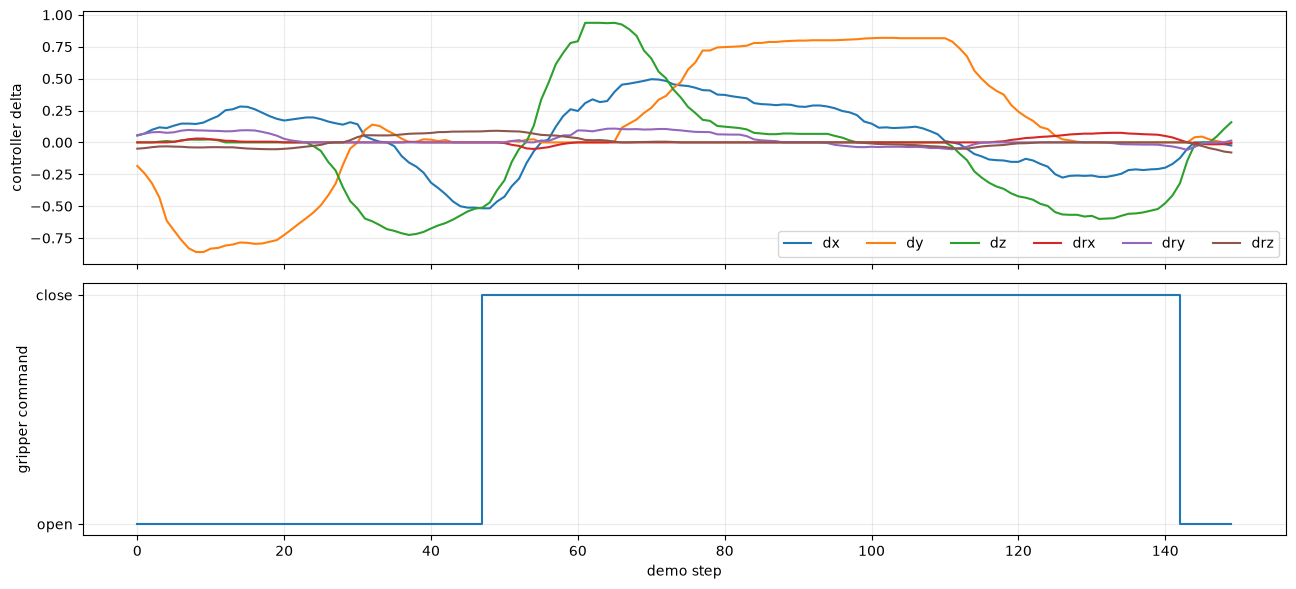

In [15]:
action_names = ["dx", "dy", "dz", "drx", "dry", "drz", "gripper"]
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(actions[:, :6])
axes[0].legend(action_names[:6], ncol=6)
axes[0].set_ylabel("controller delta")
axes[0].grid(alpha=0.25)
axes[1].step(np.arange(len(actions)), actions[:, 6], where="post")
axes[1].set_yticks([-1, 1], ["open", "close"])
axes[1].set_xlabel("demo step")
axes[1].set_ylabel("gripper command")
axes[1].grid(alpha=0.25)
plt.tight_layout()

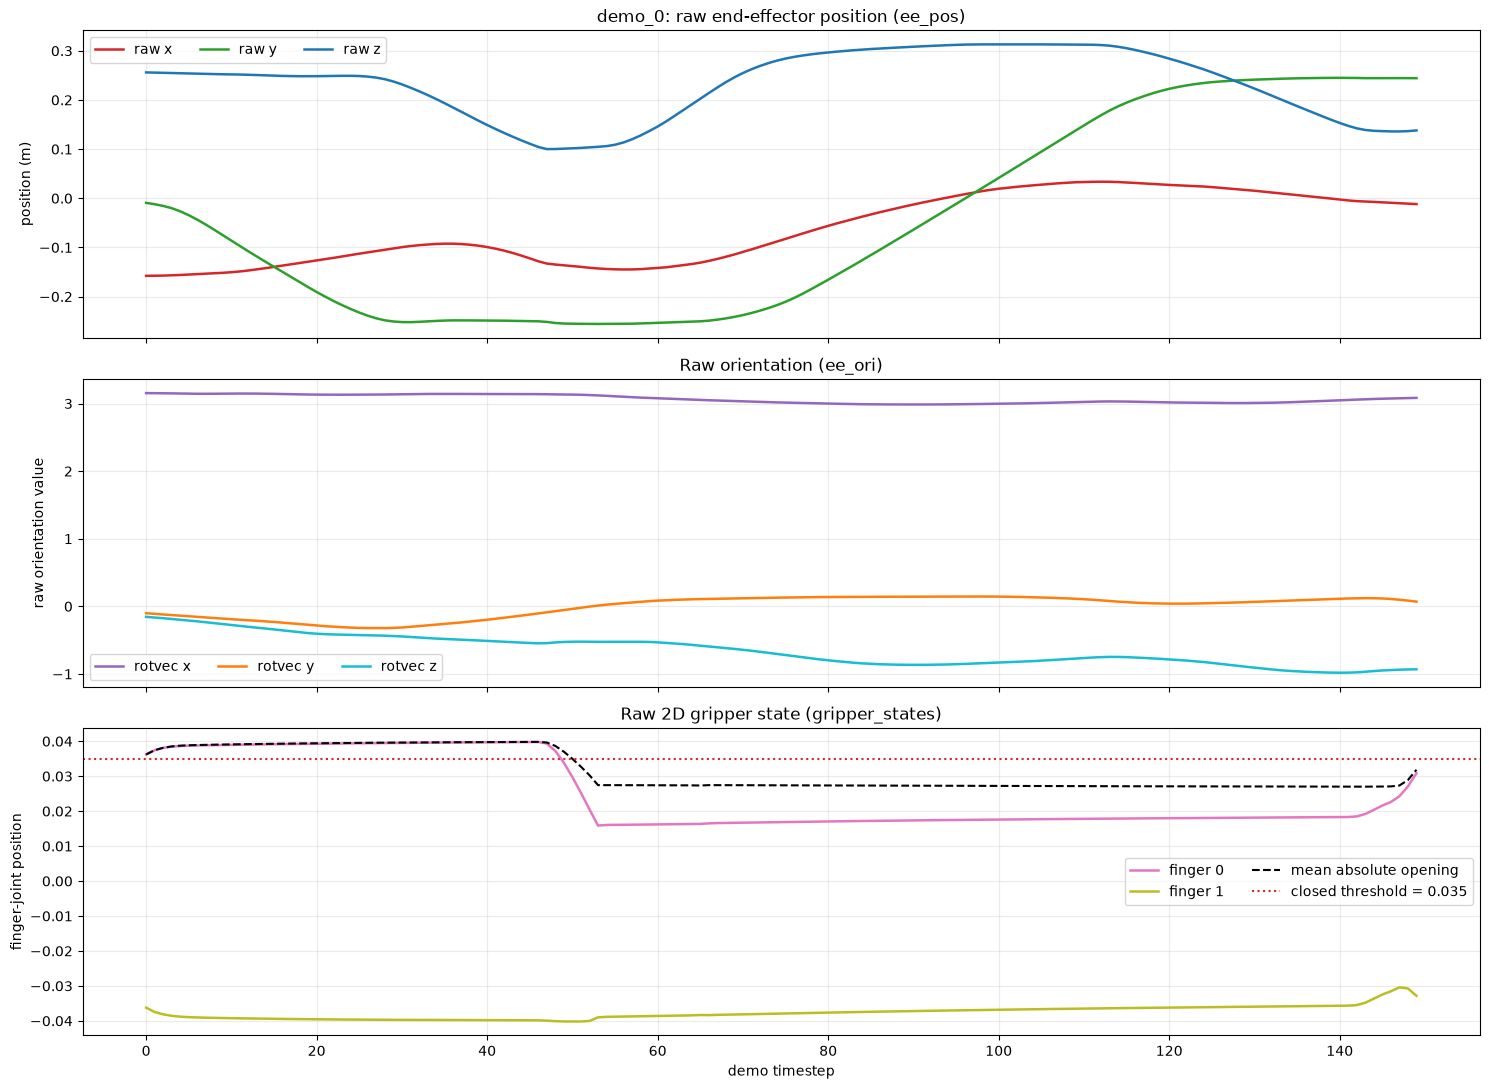

Demo: demo_0
Timesteps: 150
XYZ shape: (150, 3)
Orientation shape: (150, 3)
Gripper shape: (150, 2)


In [16]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


def read_first(group, *names):
    for name in names:
        if name in group:
            return np.asarray(group[name]).copy(), name
    raise KeyError(f"None of these datasets exist: {names}")


# Copy everything while the HDF5 file is open.
with h5py.File(demo_path, "r") as handle:
    selected_demo_name, demo_group = select_demo(handle, DEMO_NAME)
    obs = demo_group["obs"]

    raw_xyz, xyz_key = read_first(
        obs,
        "ee_pos",
        "robot0_eef_pos",
    )
    raw_orientation, orientation_key = read_first(
        obs,
        "ee_ori",
        "robot0_eef_quat",
    )
    raw_gripper, gripper_key = read_first(
        obs,
        "gripper_states",
        "robot0_gripper_qpos",
    )

# These are now NumPy arrays and remain valid after the file closes.
raw_xyz = np.asarray(raw_xyz)
raw_orientation = np.asarray(raw_orientation)
raw_gripper = np.asarray(raw_gripper)

if raw_gripper.ndim == 1:
    raw_gripper = raw_gripper[:, None]

length = min(
    len(raw_xyz),
    len(raw_orientation),
    len(raw_gripper),
)

raw_xyz = raw_xyz[:length]
raw_orientation = raw_orientation[:length]
raw_gripper = raw_gripper[:length]
timesteps = np.arange(length)

# LIBERO ee_ori is usually a rotation vector; quaternion fallback is supported.
if raw_orientation.shape[1] == 3:
    orientation_labels = ["rotvec x", "rotvec y", "rotvec z"]
elif raw_orientation.shape[1] == 4:
    orientation_labels = ["quat x", "quat y", "quat z", "quat w"]
else:
    orientation_labels = [
        f"orientation {index}"
        for index in range(raw_orientation.shape[1])
    ]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 11),
    sharex=True,
)

# Raw end-effector position
xyz_colors = ["tab:red", "tab:green", "tab:blue"]
for index, (label, color) in enumerate(
    zip(["raw x", "raw y", "raw z"], xyz_colors)
):
    axes[0].plot(
        timesteps,
        raw_xyz[:, index],
        color=color,
        linewidth=1.8,
        label=label,
    )

axes[0].set_title(f"{selected_demo_name}: raw end-effector position ({xyz_key})")
axes[0].set_ylabel("position (m)")
axes[0].legend(ncol=3)
axes[0].grid(alpha=0.25)

# Raw orientation — no RPY conversion
orientation_colors = [
    "tab:purple",
    "tab:orange",
    "tab:cyan",
    "tab:brown",
]
for index, label in enumerate(orientation_labels):
    axes[1].plot(
        timesteps,
        raw_orientation[:, index],
        color=orientation_colors[index % len(orientation_colors)],
        linewidth=1.8,
        label=label,
    )

axes[1].set_title(f"Raw orientation ({orientation_key})")
axes[1].set_ylabel("raw orientation value")
axes[1].legend(ncol=min(4, len(orientation_labels)))
axes[1].grid(alpha=0.25)

# Both Panda finger-joint positions
gripper_colors = ["tab:pink", "tab:olive"]
for index in range(raw_gripper.shape[1]):
    axes[2].plot(
        timesteps,
        raw_gripper[:, index],
        color=gripper_colors[index % len(gripper_colors)],
        linewidth=1.8,
        label=f"finger {index}",
    )

# Also show the mean absolute opening used by the threshold function.
mean_abs_opening = np.mean(np.abs(raw_gripper), axis=1)
axes[2].plot(
    timesteps,
    mean_abs_opening,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="mean absolute opening",
)

axes[2].axhline(
    0.035,
    color="tab:red",
    linestyle=":",
    linewidth=1.5,
    label="closed threshold = 0.035",
)

axes[2].set_title(f"Raw 2D gripper state ({gripper_key})")
axes[2].set_xlabel("demo timestep")
axes[2].set_ylabel("finger-joint position")
axes[2].legend(ncol=2)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Demo:", selected_demo_name)
print("Timesteps:", length)
print("XYZ shape:", raw_xyz.shape)
print("Orientation shape:", raw_orientation.shape)
print("Gripper shape:", raw_gripper.shape)

## 4. Compare raw observations with ThinkFlow/RDT state

The adapter state is `[x, y, z, roll, pitch, yaw, gripper_closed]`. Cached training then flips the last value for the pretrained RDT convention, where it means `gripper_open`. Keep this distinction separate from the LIBERO controller command (+1 open / -1 close).

Instruction: pick up the milk and place it in the basket
Episode length: 150


{'x': -0.1577732264995575,
 'y': -0.009332574903964996,
 'z': 0.25604841113090515,
 'roll': -3.126091480255127,
 'pitch': 0.09902290999889374,
 'yaw': -0.06315944343805313,
 'gripper_closed': 0.0}

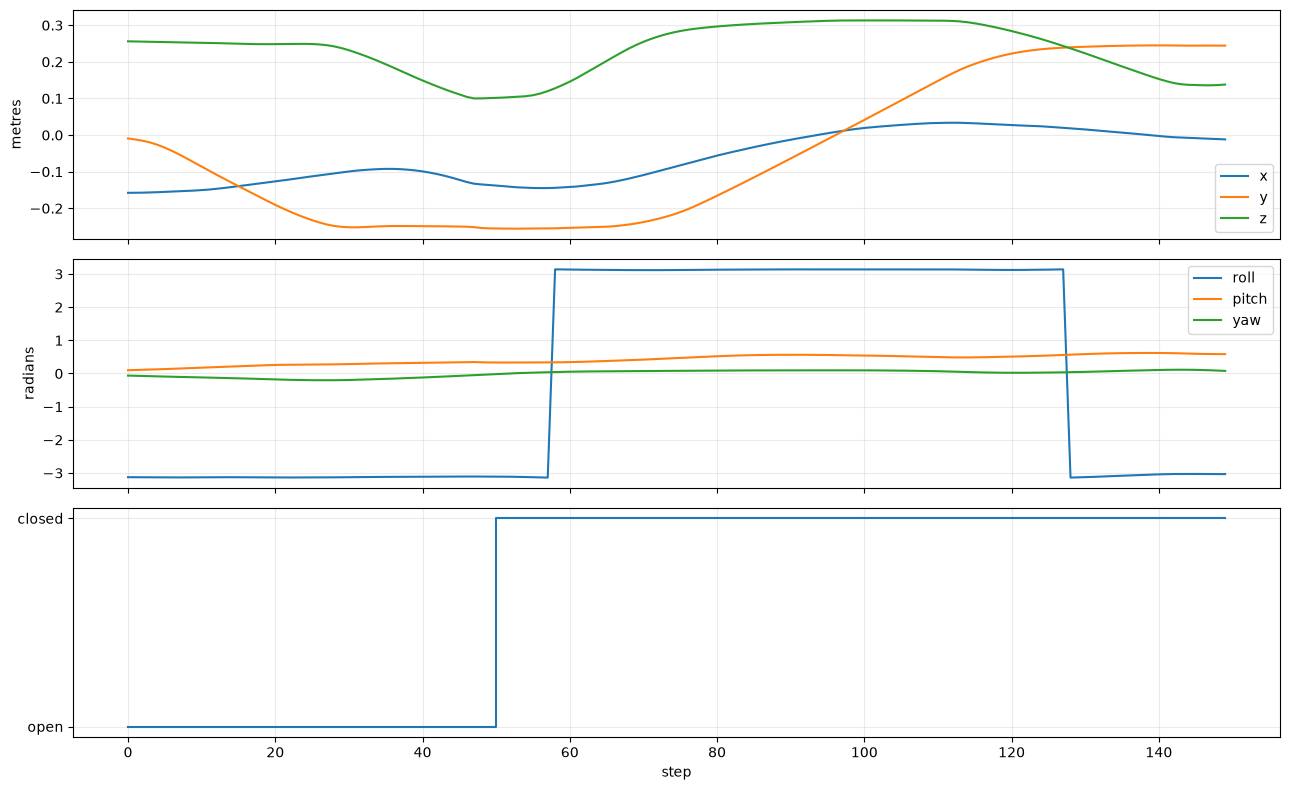

In [10]:
from thinkflow_rdt.adapters.libero import iter_libero_episodes

episode = next(ep for ep in iter_libero_episodes(demo_path) if ep.episode_id.endswith(selected_demo_name))
state_names = ["x", "y", "z", "roll", "pitch", "yaw", "gripper_closed"]
print("Instruction:", episode.instruction)
print("Episode length:", len(episode.actions))
display(dict(zip(state_names, episode.states[0].tolist())))

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
axes[0].plot(episode.states[:, :3]); axes[0].legend(state_names[:3]); axes[0].set_ylabel("metres")
axes[1].plot(episode.states[:, 3:6]); axes[1].legend(state_names[3:6]); axes[1].set_ylabel("radians")
axes[2].step(np.arange(len(episode.states)), episode.states[:, 6], where="post")
axes[2].set_yticks([0, 1], ["open", "closed"]); axes[2].set_xlabel("step")
for ax in axes: ax.grid(alpha=0.25)
plt.tight_layout()

In [51]:
import numpy as np
from scipy.spatial.transform import Rotation


def rotvec_to_matrix(rotvec):
    """Rotvec [..., 3] -> rotation matrix [..., 3, 3]."""
    rotvec = np.asarray(rotvec, dtype=np.float64)

    if rotvec.shape[-1] != 3:
        raise ValueError(f"Expected rotvec [..., 3], got {rotvec.shape}")

    leading_shape = rotvec.shape[:-1]

    matrices = Rotation.from_rotvec(
        rotvec.reshape(-1, 3)
    ).as_matrix()

    return matrices.reshape(leading_shape + (3, 3))


def matrix_to_rotvec(matrix):
    """Rotation matrix [..., 3, 3] -> canonical rotvec [..., 3]."""
    matrix = np.asarray(matrix, dtype=np.float64)

    if matrix.shape[-2:] != (3, 3):
        raise ValueError(f"Expected matrix [..., 3, 3], got {matrix.shape}")

    leading_shape = matrix.shape[:-2]

    rotvec = Rotation.from_matrix(
        matrix.reshape(-1, 3, 3)
    ).as_rotvec()

    return rotvec.reshape(leading_shape + (3,))


def rotvec_to_ortho6d(rotvec):
    """
    Rotvec [..., 3] -> orthogonal 6D representation [..., 6].

    Convention:
        ortho6d = concatenate(R[:, 0], R[:, 1])
    """
    matrix = rotvec_to_matrix(rotvec)

    first_column = matrix[..., :, 0]
    second_column = matrix[..., :, 1]

    return np.concatenate(
        [first_column, second_column],
        axis=-1,
    )


def ortho6d_to_matrix(ortho6d, eps=1e-8):
    """
    Arbitrary 6D vector [..., 6] -> valid rotation matrix [..., 3, 3].

    Gram-Schmidt projection:
        b1 = normalize(a1)
        b2 = normalize(a2 - projection onto b1)
        b3 = cross(b1, b2)
    """
    ortho6d = np.asarray(ortho6d, dtype=np.float64)

    if ortho6d.shape[-1] != 6:
        raise ValueError(f"Expected ortho6d [..., 6], got {ortho6d.shape}")

    a1 = ortho6d[..., 0:3]
    a2 = ortho6d[..., 3:6]

    norm_a1 = np.linalg.norm(a1, axis=-1, keepdims=True)
    if np.any(norm_a1 < eps):
        raise ValueError("Degenerate 6D rotation: first vector is nearly zero")

    b1 = a1 / norm_a1

    # Remove from a2 the component parallel to b1.
    projection = np.sum(b1 * a2, axis=-1, keepdims=True)
    a2_orthogonal = a2 - projection * b1

    norm_a2 = np.linalg.norm(a2_orthogonal, axis=-1, keepdims=True)
    if np.any(norm_a2 < eps):
        raise ValueError(
            "Degenerate 6D rotation: the two vectors are nearly collinear"
        )

    b2 = a2_orthogonal / norm_a2
    b3 = np.cross(b1, b2)

    # b1, b2 and b3 become the columns of the rotation matrix.
    return np.stack([b1, b2, b3], axis=-1)


def ortho6d_to_rotvec(ortho6d):
    """Orthogonal 6D [..., 6] -> canonical rotvec [..., 3]."""
    return matrix_to_rotvec(ortho6d_to_matrix(ortho6d))

In [52]:
if raw_orientation.shape[-1] != 3:
    raise ValueError(
        "This test expects raw_orientation to contain rotvecs [..., 3], "
        f"but got {raw_orientation.shape}"
    )

raw_rotvec = raw_orientation.astype(np.float64)

# Forward and inverse conversions.
raw_rot6d = rotvec_to_ortho6d(raw_rotvec)
reconstructed_rotvec = ortho6d_to_rotvec(raw_rot6d)

# Compare rotations geometrically, not by subtracting rotvec components.
original_rotation = Rotation.from_rotvec(raw_rotvec)
reconstructed_rotation = Rotation.from_rotvec(reconstructed_rotvec)

relative_rotation = reconstructed_rotation.inv() * original_rotation
angular_error = relative_rotation.magnitude()

# Verify that reconstructed matrices are orthogonal.
reconstructed_matrix = ortho6d_to_matrix(raw_rot6d)

identity = np.eye(3)
gram_matrix = (
    np.swapaxes(reconstructed_matrix, -1, -2)
    @ reconstructed_matrix
)

orthogonality_error = np.max(
    np.abs(gram_matrix - identity),
    axis=(-2, -1),
)
determinants = np.linalg.det(reconstructed_matrix)

print("Shapes")
print("  raw rotvec:         ", raw_rotvec.shape)
print("  orthogonal 6D:      ", raw_rot6d.shape)
print("  reconstructed rotvec:", reconstructed_rotvec.shape)

print("\nRotation round-trip error")
print("  mean angular error:", angular_error.mean(), "rad")
print("  max angular error: ", angular_error.max(), "rad")

print("\nRotation-matrix validity")
print("  max orthogonality error:", orthogonality_error.max())
print("  determinant range:", determinants.min(), determinants.max())

step = 0
print(f"\nExample at timestep {step}")
print("  raw rotvec:         ", raw_rotvec[step])
print("  orthogonal 6D:      ", raw_rot6d[step])
print("  reconstructed rotvec:", reconstructed_rotvec[step])
print("  angular error:      ", angular_error[step], "rad")

Shapes
  raw rotvec:          (150, 3)
  orthogonal 6D:       (150, 6)
  reconstructed rotvec: (150, 3)

Rotation round-trip error
  mean angular error: 2.802483908649468e-16 rad
  max angular error:  1.0859331343709514e-15 rad

Rotation-matrix validity
  max orthogonality error: 6.661338147750939e-16
  determinant range: 0.9999999999999997 1.0000000000000009

Example at timestep 0
  raw rotvec:          [ 3.15474959 -0.1008721  -0.15555345]
  orthogonal 6D:       [ 0.99311711 -0.06280826 -0.09886116 -0.06463923 -0.99778948 -0.01542473]
  reconstructed rotvec: [-3.11761385  0.0996847   0.15372237]
  angular error:       1.9809358765670231e-16 rad


In [53]:
OSC_ROTATION_SCALE = 0.5  # From Robosuite osc_pose.json


def libero_rot_command_to_ortho6d(
    rotation_command,
    rotation_scale=OSC_ROTATION_SCALE,
):
    """
    Normalized LIBERO rotation command [..., 3]
    -> relative delta rotation in orthogonal 6D [..., 6].
    """
    rotation_command = np.asarray(rotation_command, dtype=np.float64)

    if rotation_command.shape[-1] != 3:
        raise ValueError(
            f"Expected rotation command [..., 3], got {rotation_command.shape}"
        )

    rotation_command = np.clip(rotation_command, -1.0, 1.0)
    delta_rotvec = rotation_command * float(rotation_scale)

    return rotvec_to_ortho6d(delta_rotvec)


def ortho6d_to_libero_rot_command(
    delta_rotation_6d,
    rotation_scale=OSC_ROTATION_SCALE,
):
    """
    Predicted relative delta rotation [..., 6]
    -> normalized LIBERO OSC_POSE rotation command [..., 3].
    """
    delta_rotvec = ortho6d_to_rotvec(delta_rotation_6d)

    rotation_command = delta_rotvec / float(rotation_scale)

    return np.clip(rotation_command, -1.0, 1.0)

In [54]:
import h5py

with h5py.File(demo_path, "r") as handle:
    selected_demo_name, demo_group = select_demo(handle, DEMO_NAME)
    raw_demo_actions = np.asarray(demo_group["actions"]).copy()

raw_rotation_commands = raw_demo_actions[:, 3:6]

command_rot6d = libero_rot_command_to_ortho6d(
    raw_rotation_commands
)

reconstructed_rotation_commands = ortho6d_to_libero_rot_command(
    command_rot6d
)

command_error = (
    reconstructed_rotation_commands - raw_rotation_commands
)

print("Raw rotation command shape:", raw_rotation_commands.shape)
print("6D rotation command shape: ", command_rot6d.shape)

print(
    "Command RMSE:",
    np.sqrt(np.mean(command_error**2)),
)
print(
    "Maximum absolute command error:",
    np.max(np.abs(command_error)),
)

step = 0
print(f"\nExample at timestep {step}")
print("  recorded command:", raw_rotation_commands[step])
print("  delta rotation 6D:", command_rot6d[step])
print("  recovered command:", reconstructed_rotation_commands[step])

Raw rotation command shape: (150, 3)
6D rotation command shape:  (150, 6)
Command RMSE: 5.718488973371575e-18
Maximum absolute command error: 4.163336342344337e-17

Example at timestep 0
  recorded command: [ 0.          0.05678571 -0.04928571]
  delta rotation 6D: [ 9.99293371e-01 -2.46370524e-02 -2.83861691e-02  2.46370524e-02
  9.99696401e-01 -3.49799357e-04]
  recovered command: [ 0.          0.05678571 -0.04928571]


In [11]:
step = 80

raw_pos = demo["obs"]["ee_pos"][step]
raw_orientation = demo["obs"]["ee_ori"][step]
raw_gripper = demo["obs"]["gripper_states"][step]

print("Raw position:", raw_pos)
print("Raw orientation:", raw_orientation)
print("Raw gripper:", raw_gripper)

print("\nExtracted state:")
print(episode.states[step])

Raw position: [-0.05602818 -0.1656372   0.29665633]
Raw orientation: [ 3.00006223  0.13808189 -0.79814635]
Raw gripper: [ 0.01705246 -0.03763835]

Extracted state:
[-0.05602818 -0.1656372   0.29665634  3.12995     0.5204899   0.08888753
  1.        ]


In [12]:
from thinkflow_rdt.adapters.libero import (
    libero_gripper_state_to_closed,
    libero_orientation_to_rpy,
)

step = 50

expected_state = np.concatenate([
    np.asarray(demo["obs"]["ee_pos"][step])[:3],
    libero_orientation_to_rpy(demo["obs"]["ee_ori"][step]),
    [
        libero_gripper_state_to_closed(
            demo["obs"]["gripper_states"][step]
        )
    ],
]).astype(np.float32)

print("Manually extracted:", expected_state)
print("Episode state:     ", episode.states[step])
print("Exact match:       ", np.allclose(expected_state, episode.states[step]))

Manually extracted: [-0.13789725 -0.25522608  0.10156761 -3.1090736   0.33114383 -0.01819294
  1.        ]
Episode state:      [-0.13789725 -0.25522608  0.10156761 -3.1090736   0.33114383 -0.01819294
  1.        ]
Exact match:        True


In [13]:
# Close an earlier handle if it is still open
if "handle" in globals() and handle.id.valid:
    handle.close()

# Keep this handle open across notebook cells
handle = h5py.File(demo_path, "r")
selected_demo_name, demo = select_demo(handle, DEMO_NAME)

print("File open:", bool(handle.id.valid))
print("Selected demo:", selected_demo_name)

File open: True
Selected demo: demo_0


In [14]:
from scipy.spatial.transform import Rotation
from thinkflow_rdt.adapters.libero import libero_orientation_to_rpy
import numpy as np
import matplotlib.pyplot as plt

# Requires the HDF5 handle to still be open
raw_orientations = np.asarray(
    demo["obs"]["ee_ori"][:],
    dtype=np.float64,
)

print("Shape:", raw_orientations.shape)
print("First raw orientation:", raw_orientations[0])

Shape: (150, 3)
First raw orientation: [ 3.15474959 -0.1008721  -0.15555345]


In [15]:
def rpy_to_libero_orientation(rpy, representation="rotvec"):
    """
    Convert XYZ roll/pitch/yaw back to a LIBERO orientation.

    representation:
      - "rotvec" for demo obs["ee_ori"]
      - "quat" for live robot0_eef_quat, using SciPy's xyzw order
    """
    rotation = Rotation.from_euler("xyz", np.asarray(rpy))

    if representation == "rotvec":
        return rotation.as_rotvec().astype(np.float32)

    if representation == "quat":
        return rotation.as_quat().astype(np.float32)  # xyzw

    raise ValueError(f"Unknown representation: {representation}")

In [16]:
step = 50

raw_orientation = raw_orientations[step]

rpy = libero_orientation_to_rpy(raw_orientation)
reconstructed_orientation = rpy_to_libero_orientation(
    rpy,
    representation="rotvec",
)

print("Raw rotvec:         ", raw_orientation)
print("Converted RPY:      ", rpy)
print("Reconstructed rotvec:", reconstructed_orientation)
print(
    "Directly close:",
    np.allclose(
        raw_orientation,
        reconstructed_orientation,
        atol=1e-6,
    ),
)

Raw rotvec:          [ 3.13308132 -0.03701499 -0.52309265]
Converted RPY:       [-3.1090736   0.33114383 -0.01819294]
Reconstructed rotvec: [-3.063901    0.03619768  0.51154244]
Directly close: False


In [17]:
from scipy.spatial.transform import Rotation
import numpy as np

raw_rotation = Rotation.from_rotvec(raw_orientation)
reconstructed_rotation = Rotation.from_rotvec(
    reconstructed_orientation
)

relative_rotation = reconstructed_rotation.inv() * raw_rotation
angular_error_rad = relative_rotation.magnitude()

print("Raw rotvec magnitude:", np.linalg.norm(raw_orientation))
print(
    "Reconstructed magnitude:",
    np.linalg.norm(reconstructed_orientation),
)
print("Angular error (rad):", angular_error_rad)
print("Angular error (deg):", np.degrees(angular_error_rad))
print("Same physical rotation:", angular_error_rad < 1e-6)

Raw rotvec magnitude: 3.1766640624851514
Reconstructed magnitude: 3.1065214
Angular error (rad): 1.1459817032771324e-07
Angular error (deg): 6.5659914996993105e-06
Same physical rotation: True


In [18]:
raw_matrix = raw_rotation.as_matrix()
reconstructed_matrix = reconstructed_rotation.as_matrix()

print(
    "Rotation matrices match:",
    np.allclose(raw_matrix, reconstructed_matrix, atol=1e-6),
)

Rotation matrices match: True


In [19]:
raw_rotation = Rotation.from_rotvec(raw_orientation)
reconstructed_rotation = Rotation.from_rotvec(
    reconstructed_orientation
)

relative_rotation = (
    reconstructed_rotation.inv() * raw_rotation
)

angular_error_rad = relative_rotation.magnitude()

print("Angular error (rad):", angular_error_rad)
print("Angular error (deg):", np.degrees(angular_error_rad))

Angular error (rad): 1.1459817032771324e-07
Angular error (deg): 6.5659914996993105e-06


Mean angular error (rad): 8.474649902799115e-08
Maximum angular error (rad): 2.2472721978992098e-07
Mean angular error (deg): 4.855616722813427e-06
Maximum angular error (deg): 1.2875921235671302e-05


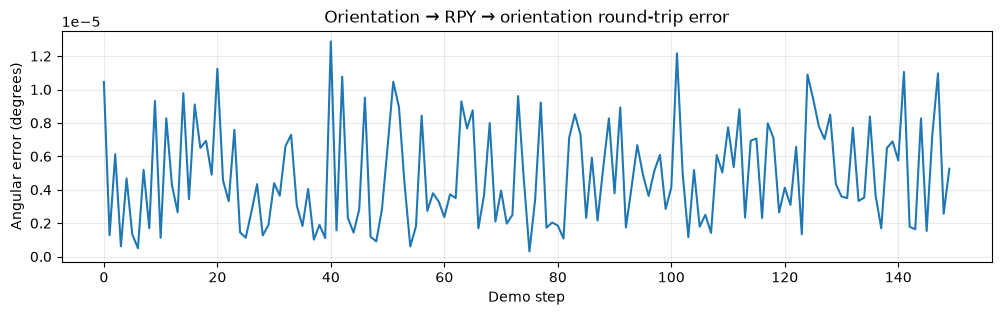

In [20]:
rpy_all = libero_orientation_to_rpy(raw_orientations)

reconstructed_all = rpy_to_libero_orientation(
    rpy_all,
    representation="rotvec",
)

raw_rotations = Rotation.from_rotvec(raw_orientations)
reconstructed_rotations = Rotation.from_rotvec(reconstructed_all)

relative_rotations = reconstructed_rotations.inv() * raw_rotations
angular_errors = relative_rotations.magnitude()

print("Mean angular error (rad):", angular_errors.mean())
print("Maximum angular error (rad):", angular_errors.max())
print("Mean angular error (deg):", np.degrees(angular_errors).mean())
print("Maximum angular error (deg):", np.degrees(angular_errors).max())

plt.figure(figsize=(12, 3))
plt.plot(np.degrees(angular_errors))
plt.xlabel("Demo step")
plt.ylabel("Angular error (degrees)")
plt.title("Orientation → RPY → orientation round-trip error")
plt.grid(alpha=0.25)
plt.show()

In [21]:
from scipy.spatial.transform import Rotation
import numpy as np

def rotvec_to_ortho6d(rotvec):
    rotvec = np.asarray(rotvec, dtype=np.float64)
    matrix = Rotation.from_rotvec(
        rotvec.reshape(-1, 3)
    ).as_matrix()

    # RDT convention: first column followed by second column
    ortho6d = np.concatenate(
        [matrix[:, :, 0], matrix[:, :, 1]],
        axis=-1,
    )

    return ortho6d.reshape(*rotvec.shape[:-1], 6).astype(np.float32)

In [22]:
raw_rotvec = np.asarray(demo["obs"]["ee_ori"][0])

ortho6d = rotvec_to_ortho6d(raw_rotvec)

print("Raw rotvec:", raw_rotvec)
print("Ortho6D:", ortho6d)
print("Shape:", ortho6d.shape)

Raw rotvec: [ 3.15474959 -0.1008721  -0.15555345]
Ortho6D: [ 0.9931171  -0.06280826 -0.09886116 -0.06463923 -0.9977895  -0.01542473]
Shape: (6,)


In [23]:
raw_rotvecs = np.asarray(demo["obs"]["ee_ori"][:])

ortho6d_all = rotvec_to_ortho6d(raw_rotvecs)

print("Raw shape:", raw_rotvecs.shape)
print("Ortho6D shape:", ortho6d_all.shape)

Raw shape: (150, 3)
Ortho6D shape: (150, 6)


## 5. Start and inspect a live environment

This uses the official task BDDL and its saved initialization. LIBERO init files are local trusted artifacts; `weights_only=False` is required with PyTorch 2.6+. Always close an old environment before rerunning this cell.

In [ ]:
from libero.libero.envs import OffScreenRenderEnv

if "env" in globals():
    env.close()

init_path = (
    LIBERO_ROOT / "libero" / "libero" / "init_files"
    / task.problem_folder / task.init_states_file
)
init_states = torch.load(init_path, map_location="cpu", weights_only=False)
env = OffScreenRenderEnv(
    bddl_file_name=benchmark.get_task_bddl_file_path(TASK_ID),
    camera_heights=CAMERA_SIZE,
    camera_widths=CAMERA_SIZE,
    horizon=500,
)
live_obs = env.reset()
live_obs = env.set_init_state(init_states[INIT_STATE_INDEX % len(init_states)])
print("Init file:", init_path)
print("Observation keys:", sorted(live_obs))
live_summary = summarize_mapping(live_obs)
compact_summary = {
    key: {name: value for name, value in summary.items() if name in ("shape", "dtype", "min", "max")}
    for key, summary in live_summary.items()
}
display(compact_summary)

In [ ]:
converted = libero_observation_to_rdt(live_obs)
live_state_closed = converted["state"]
model_state_open = live_state_closed.copy()
model_state_open[6] = 1.0 - model_state_open[6]

print("Adapter state (closed convention):", live_state_closed)
print("Model state   (open convention):  ", model_state_open)

fig, axes = plt.subplots(1, 2 if converted["wrist"] is not None else 1, figsize=(9, 4), squeeze=False)
axes[0, 0].imshow(np.asarray(converted["primary"]))
axes[0, 0].set_title("live agent view")
axes[0, 0].axis("off")
if converted["wrist"] is not None:
    axes[0, 1].imshow(np.asarray(converted["wrist"]))
    axes[0, 1].set_title("live wrist view")
    axes[0, 1].axis("off")
plt.tight_layout()

## 6. Step safely and observe state changes

Start with zero actions. Random actions are a poor simulator test because they can saturate the controller or hit objects. For a deliberate motion, change one translational component slightly (for example `action[0] = 0.05`) and reset before each experiment.

In [ ]:
live_obs = env.set_init_state(init_states[INIT_STATE_INDEX % len(init_states)])
trace = []
for step in range(20):
    action = np.zeros(7, dtype=np.float32)
    # Try after the zero-action baseline: action[0] = 0.05
    live_obs, reward, done, info = env.step(action)
    trace.append(libero_observation_to_rdt(live_obs)["state"])
    if done:
        break
trace = np.asarray(trace)
print("steps:", len(trace), "reward:", reward, "success:", env.check_success())
plt.figure(figsize=(12, 3))
plt.plot(trace[:, :3])
plt.legend(["x", "y", "z"]); plt.xlabel("step"); plt.ylabel("EEF position"); plt.grid(alpha=0.25);

## 7. Replay recorded actions exactly

A faithful replay must initialize from `demo/states[0]`, not merely from the task's default init state. The cell below runs only `REPLAY_STEPS` actions and compares live end-effector position with the recorded observation. Increase it to `len(actions)` for the full demo.

In [ ]:
REPLAY_STEPS = min(100, len(actions))

with h5py.File(demo_path, "r") as handle:
    _, demo = select_demo(handle, selected_demo_name)
    initial_demo_state = np.asarray(demo["states"][0], dtype=np.float64)
    demo_actions = np.asarray(demo["actions"], dtype=np.float32)[:, :7]
    obs_group = demo["obs"]
    pos_key = "ee_pos" if "ee_pos" in obs_group else "robot0_eef_pos"
    recorded_positions = np.asarray(obs_group[pos_key], dtype=np.float32)

live_obs = env.set_init_state(initial_demo_state)
live_positions, errors, rewards = [], [], []
for step, action in enumerate(demo_actions[:REPLAY_STEPS]):
    live_obs, reward, done, info = env.step(action)
    live_pos = libero_observation_to_rdt(live_obs)["state"][:3]
    expected_pos = recorded_positions[min(step + 1, len(recorded_positions) - 1), :3]
    live_positions.append(live_pos)
    errors.append(np.linalg.norm(live_pos - expected_pos))
    rewards.append(reward)
    if done or env.check_success():
        break

live_positions = np.asarray(live_positions)
errors = np.asarray(errors)
print(f"replayed={len(errors)} success={env.check_success()} mean_error={errors.mean():.6f} m max_error={errors.max():.6f} m")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(errors); axes[0].set_title("Live vs recorded EEF L2 error"); axes[0].set_ylabel("metres"); axes[0].set_xlabel("step")
axes[1].imshow(np.asarray(libero_observation_to_rdt(live_obs)["primary"])); axes[1].set_title("final replay frame"); axes[1].axis("off")
for ax in axes[:1]: ax.grid(alpha=0.25)
plt.tight_layout()

## 8. How this connects to RDT rollout

`rollout_libero_rdt.py` adds the expensive model path on top of this loop:

1. Convert the live observation to images plus a 7-D state.
2. Flip `gripper_closed` to the model's `gripper_open` convention.
3. Sample a horizon of target states.
4. Convert every absolute target to a delta controller action using current-to-target position/orientation error.
5. Convert model gripper-open to LIBERO command: open becomes +1, close becomes -1.
6. Execute a short action chunk, observe again, and replan.

Only add checkpoint/model inference after raw demonstration replay has low tracking error; otherwise an environment/controller mismatch can look like a model failure.

In [ ]:
# Always release the MuJoCo renderer when finished.
env.close()
del env
print("Environment closed")

## 9. Full-timestep state and target-state action audit

This section performs two separate tests across the whole demonstration:

1. **Extraction consistency:** compare raw HDF5 observations with the 7-D states produced by the adapter. This proves the code is internally consistent, but it does not prove that a heuristic such as the gripper threshold is semantically correct.
2. **Controller-conversion consistency:** treat recorded future states as perfect/oracle RDT target-state predictions, convert them with the exact rollout formula, and compare the resulting commands with recorded LIBERO actions. These are called `oracle_commands`; they are not outputs from the trained RDT model.

In [24]:
from scipy.spatial.transform import Rotation
from thinkflow_rdt.adapters.libero import (
    libero_gripper_state_to_closed,
    libero_orientation_to_rpy,
    iter_libero_episodes,
)

# Load every raw array into memory so no h5py object is used after the file closes.
with h5py.File(demo_path, "r") as audit_handle:
    audit_demo_name, audit_demo = select_demo(audit_handle, DEMO_NAME)
    audit_obs = audit_demo["obs"]
    pos_key = next(k for k in ("ee_pos", "robot0_eef_pos") if k in audit_obs)
    ori_key = next(k for k in ("ee_ori", "robot0_eef_quat") if k in audit_obs)
    grip_key = next(k for k in ("gripper_states", "robot0_gripper_qpos") if k in audit_obs)
    raw_xyz = np.asarray(audit_obs[pos_key][:], dtype=np.float32)[..., :3]
    raw_orientation = np.asarray(audit_obs[ori_key][:])
    raw_gripper_joints = np.asarray(audit_obs[grip_key][:], dtype=np.float32)
    recorded_actions = np.asarray(audit_demo["actions"][:], dtype=np.float32)[:, :7]

audit_episode = next(
    ep for ep in iter_libero_episodes(demo_path)
    if ep.episode_id.endswith(audit_demo_name)
)
extracted_states_closed = np.asarray(audit_episode.states, dtype=np.float32)
length = min(len(raw_xyz), len(raw_orientation), len(raw_gripper_joints), len(extracted_states_closed))
raw_xyz = raw_xyz[:length]
raw_orientation = raw_orientation[:length]
raw_gripper_joints = raw_gripper_joints[:length]
extracted_states_closed = extracted_states_closed[:length]
raw_rpy = libero_orientation_to_rpy(raw_orientation)
raw_gripper_opening = np.mean(np.abs(raw_gripper_joints), axis=-1)
heuristic_closed = libero_gripper_state_to_closed(raw_gripper_joints)
manual_states_closed = np.concatenate(
    [raw_xyz, raw_rpy, heuristic_closed[:, None]], axis=-1
).astype(np.float32)
print(f"demo={audit_demo_name} timesteps={length}")
print("raw orientation representation:", ori_key, raw_orientation.shape)
print("maximum raw-vs-extracted absolute difference:", np.max(np.abs(manual_states_closed - extracted_states_closed), axis=0))

demo=demo_0 timesteps=150
raw orientation representation: ee_ori (150, 3)
maximum raw-vs-extracted absolute difference: [0. 0. 0. 0. 0. 0. 0.]


maximum rotation error (degrees): 6.838926292752284e-06
maximum ortho6D absolute error: 1.1217194101700856e-07


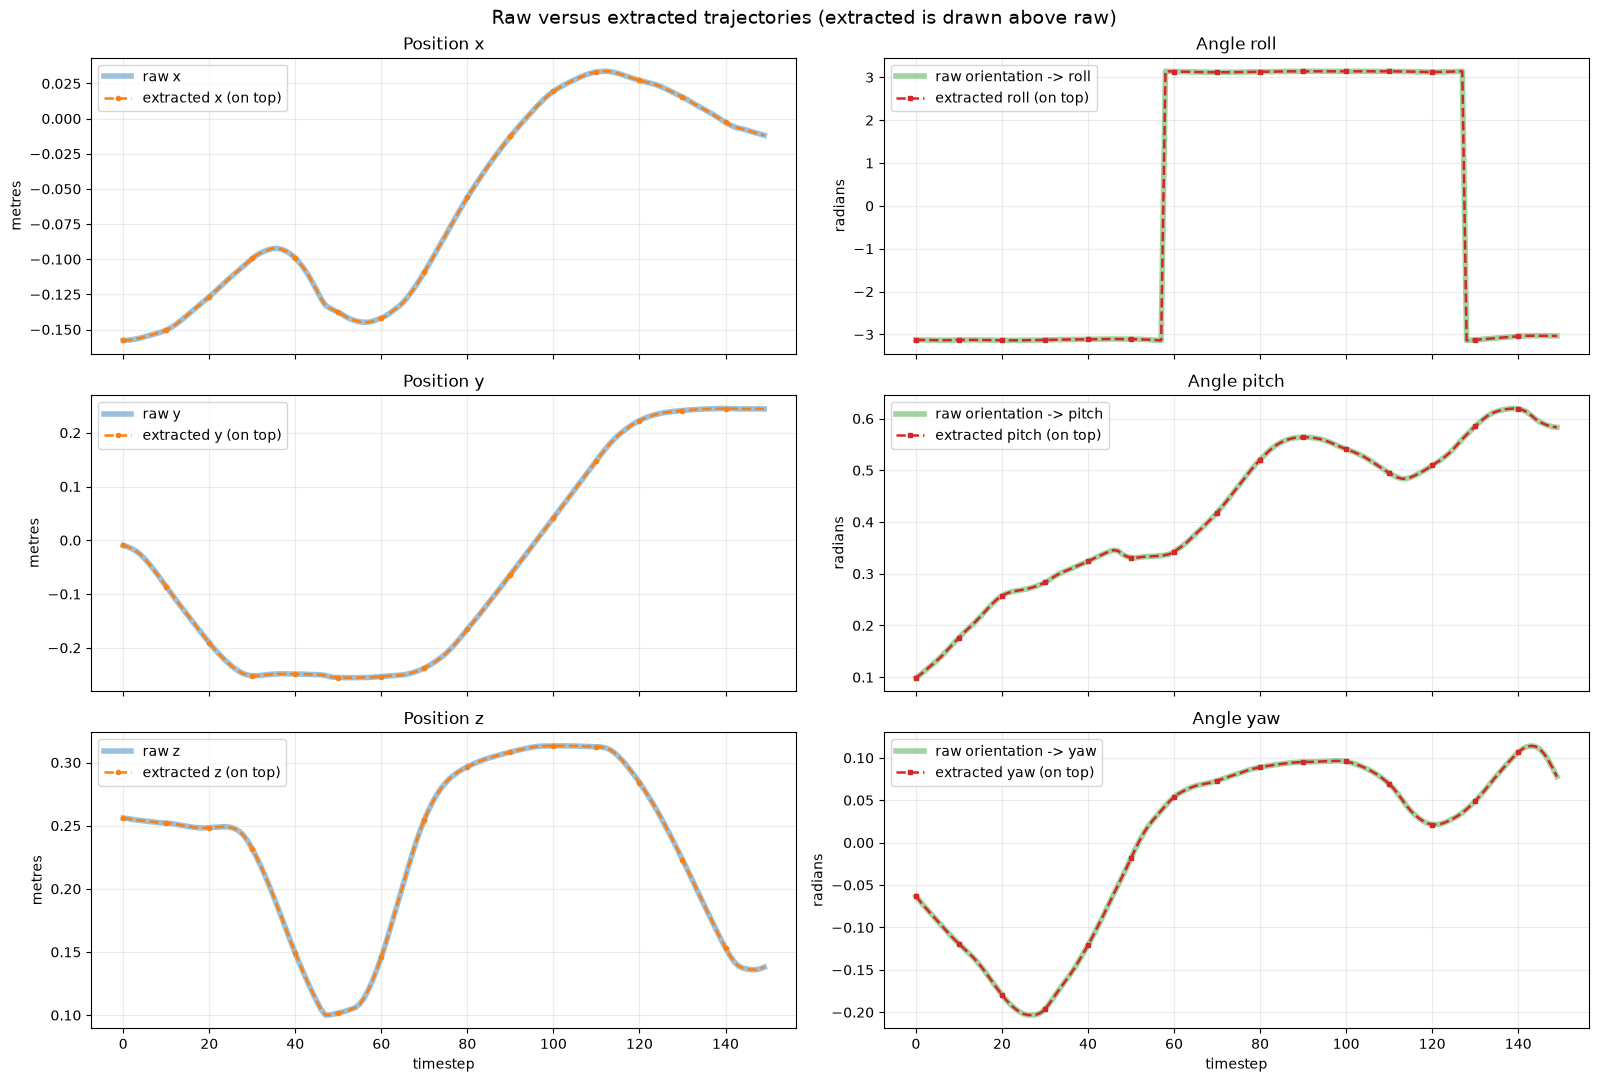

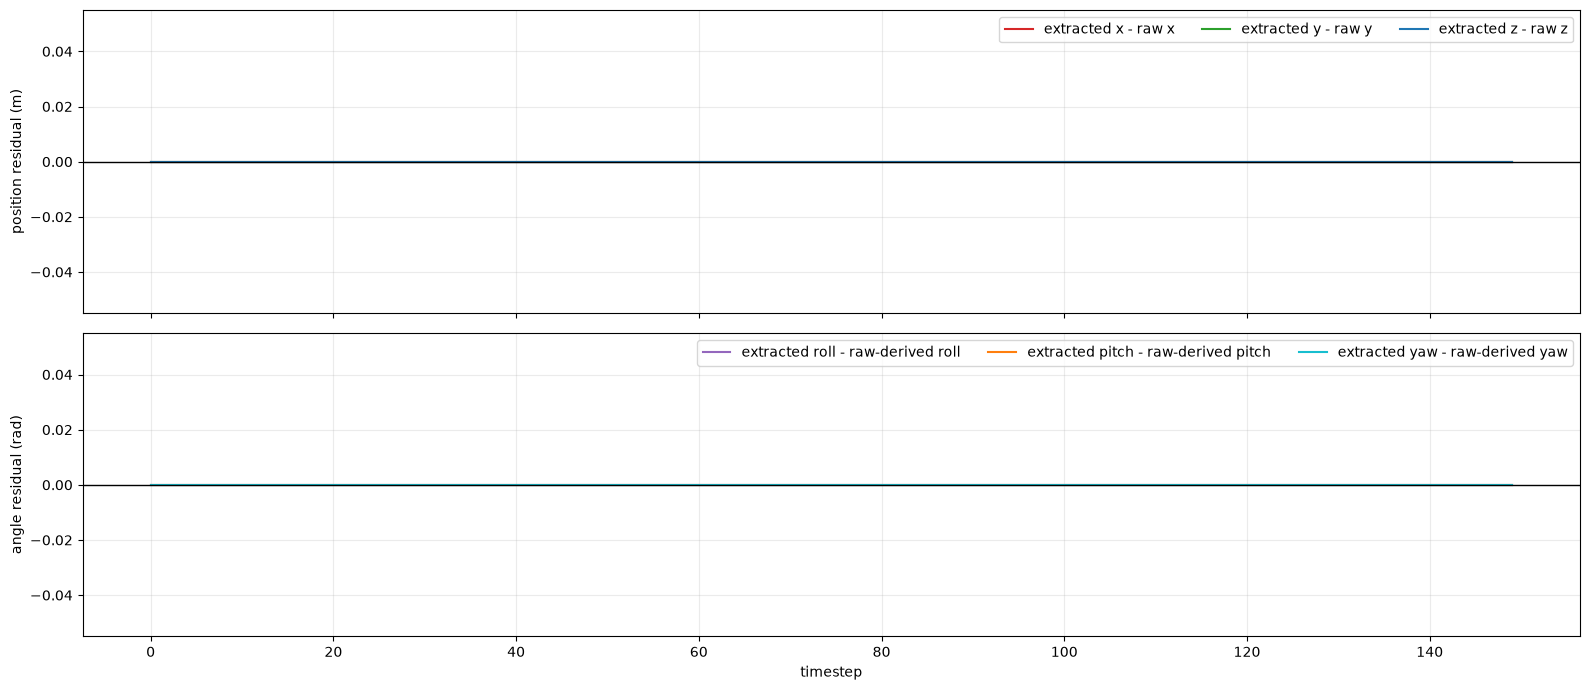

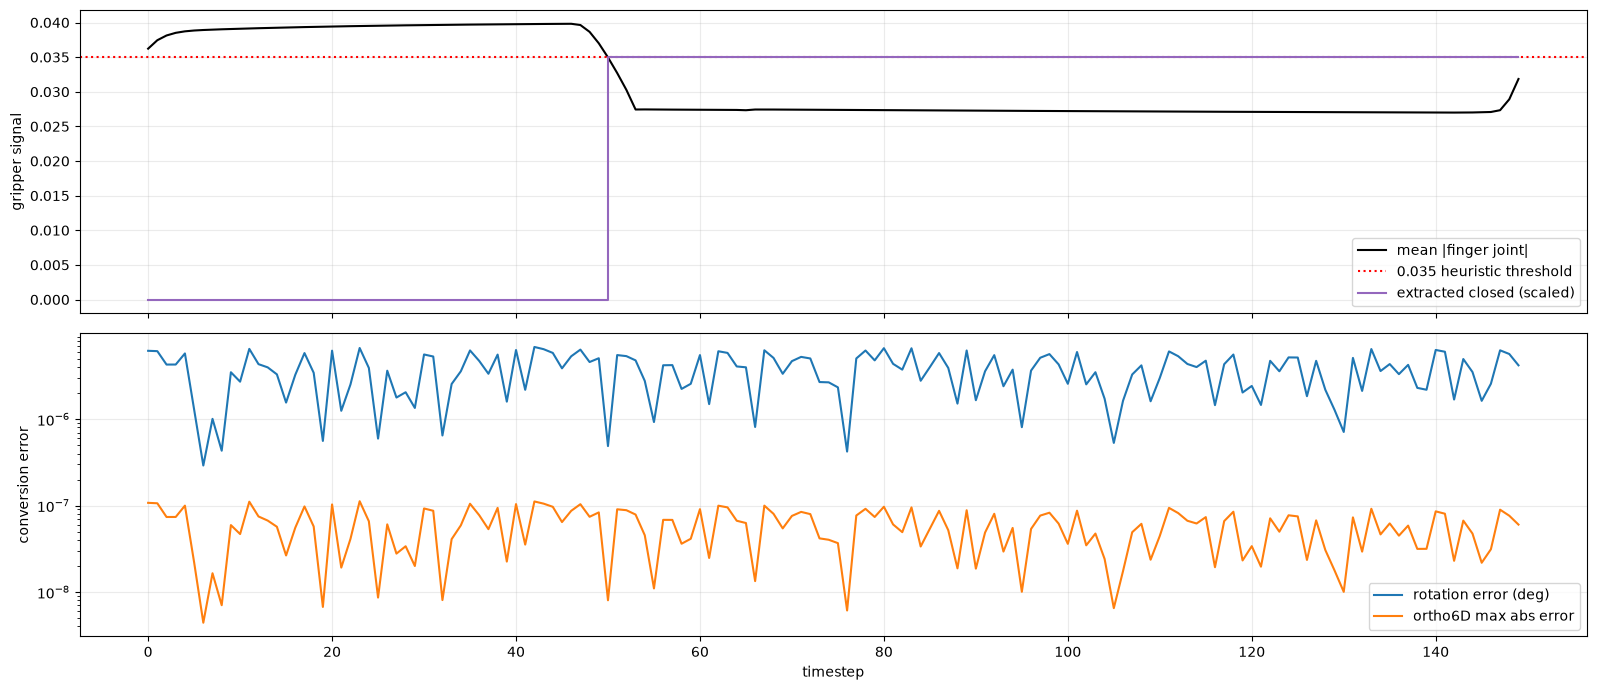

In [28]:
# Independent rotation-equivalence check: raw orientation -> matrix versus extracted RPY -> matrix.
if raw_orientation.shape[-1] == 3:
    raw_rotations = Rotation.from_rotvec(raw_orientation)
elif raw_orientation.shape[-1] == 4:
    raw_rotations = Rotation.from_quat(raw_orientation)  # LIBERO/SciPy xyzw
else:
    raise ValueError(f"Unexpected orientation shape: {raw_orientation.shape}")
extracted_rotations = Rotation.from_euler("xyz", extracted_states_closed[:, 3:6])
orientation_error_deg = np.degrees((extracted_rotations.inv() * raw_rotations).magnitude())
raw_matrix = raw_rotations.as_matrix()
extracted_matrix = extracted_rotations.as_matrix()
raw_ortho6d = np.concatenate([raw_matrix[:, :, 0], raw_matrix[:, :, 1]], axis=-1)
extracted_ortho6d = np.concatenate([extracted_matrix[:, :, 0], extracted_matrix[:, :, 1]], axis=-1)
ortho6d_error = np.max(np.abs(raw_ortho6d - extracted_ortho6d), axis=-1)

# Plot every dimension separately. Raw is a wide blue background line; extracted
# is orange, dashed, marked, and drawn above raw with the larger zorder.
fig, axes = plt.subplots(3, 2, figsize=(16, 11), sharex=True)
position_names = ["x", "y", "z"]
angle_names = ["roll", "pitch", "yaw"]
marker_spacing = max(1, length // 15)
for dim in range(3):
    position_ax = axes[dim, 0]
    position_ax.plot(raw_xyz[:, dim], color="tab:blue", linewidth=4.0, alpha=0.45, zorder=1, label=f"raw {position_names[dim]}")
    position_ax.plot(extracted_states_closed[:, dim], color="tab:orange", linewidth=1.8, linestyle="--", marker="o", markersize=3, markevery=marker_spacing, zorder=3, label=f"extracted {position_names[dim]} (on top)")
    position_ax.set_title(f"Position {position_names[dim]}")
    position_ax.set_ylabel("metres")
    position_ax.legend(loc="best")

    angle_ax = axes[dim, 1]
    angle_ax.plot(raw_rpy[:, dim], color="tab:green", linewidth=4.0, alpha=0.45, zorder=1, label=f"raw orientation -> {angle_names[dim]}")
    angle_ax.plot(extracted_states_closed[:, dim + 3], color="tab:red", linewidth=1.8, linestyle="--", marker="s", markersize=3, markevery=marker_spacing, zorder=3, label=f"extracted {angle_names[dim]} (on top)")
    angle_ax.set_title(f"Angle {angle_names[dim]}")
    angle_ax.set_ylabel("radians")
    angle_ax.legend(loc="best")
for ax in axes[-1]: ax.set_xlabel("timestep")
for ax in axes.ravel(): ax.grid(alpha=0.25)
fig.suptitle("Raw versus extracted trajectories (extracted is drawn above raw)", fontsize=14)
plt.tight_layout()

# Residuals remove all visual ambiguity: a flat zero line means exact overlap.
position_residual = extracted_states_closed[:, :3] - raw_xyz
angle_difference = extracted_states_closed[:, 3:6] - raw_rpy
angle_residual = np.arctan2(np.sin(angle_difference), np.cos(angle_difference))
fig, residual_axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
for dim, (name, color) in enumerate(zip(position_names, ["tab:red", "tab:green", "tab:blue"])):
    residual_axes[0].plot(position_residual[:, dim], color=color, label=f"extracted {name} - raw {name}")
for dim, (name, color) in enumerate(zip(angle_names, ["tab:purple", "tab:orange", "tab:cyan"])):
    residual_axes[1].plot(angle_residual[:, dim], color=color, label=f"extracted {name} - raw-derived {name}")
residual_axes[0].axhline(0, color="black", linewidth=1); residual_axes[0].set_ylabel("position residual (m)"); residual_axes[0].legend(ncol=3)
residual_axes[1].axhline(0, color="black", linewidth=1); residual_axes[1].set_ylabel("angle residual (rad)"); residual_axes[1].set_xlabel("timestep"); residual_axes[1].legend(ncol=3)
for ax in residual_axes: ax.grid(alpha=0.25)
plt.tight_layout()

# Keep gripper and representation-conversion checks in a separate figure.
fig, diagnostic_axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
diagnostic_axes[0].plot(raw_gripper_opening, color="black", label="mean |finger joint|")
diagnostic_axes[0].axhline(0.035, color="red", linestyle=":", label="0.035 heuristic threshold")
diagnostic_axes[0].step(np.arange(length), extracted_states_closed[:, 6] * 0.035, where="post", color="tab:purple", label="extracted closed (scaled)")
diagnostic_axes[0].set_ylabel("gripper signal"); diagnostic_axes[0].legend()
diagnostic_axes[1].semilogy(np.maximum(orientation_error_deg, 1e-14), label="rotation error (deg)")
diagnostic_axes[1].semilogy(np.maximum(ortho6d_error, 1e-14), label="ortho6D max abs error")
diagnostic_axes[1].set_ylabel("conversion error"); diagnostic_axes[1].set_xlabel("timestep"); diagnostic_axes[1].legend()
for ax in diagnostic_axes: ax.grid(alpha=0.25)
plt.tight_layout()
print("maximum rotation error (degrees):", orientation_error_deg.max())
print("maximum ortho6D absolute error:", ortho6d_error.max())

### Convert recorded future states into oracle LIBERO commands

Training target token 0 is the current state, so rollout normally starts with target token 1. For this offline audit, timestep `t + TARGET_OFFSET` is treated as the perfect future target for timestep `t`. The current and target gripper values are changed from the dataset's `closed` convention to the RDT model's `open` convention before applying the production formula.

A mismatch here does **not automatically mean that RDT is wrong**. Demonstration actions are controller inputs, while observed state differences are controller outputs affected by dynamics, controller gains, contacts, and temporal alignment. This test isolates whether scale, clipping, alignment, or gripper convention can explain the mismatch.

In [34]:
TARGET_OFFSET = 1
POS_SCALE = 80.0
ROT_SCALE = 7.0
MAX_DELTA_POS = 1.0
MAX_DELTA_ROT = 1.0

def wrap_to_pi(angle):
    angle = np.asarray(angle, dtype=np.float32)
    return np.arctan2(np.sin(angle), np.cos(angle)).astype(np.float32)

def absolute_targets_to_libero_commands(
    target_states_open, current_states_open, *, pos_scale=10.0, rot_scale=10.0,
    max_delta_pos=1.0, max_delta_rot=1.0,
):
    target = np.asarray(target_states_open, dtype=np.float32)
    current = np.asarray(current_states_open, dtype=np.float32)
    commands = np.zeros_like(target, dtype=np.float32)
    commands[..., :3] = (target[..., :3] - current[..., :3]) * pos_scale
    commands[..., 3:6] = wrap_to_pi(target[..., 3:6] - current[..., 3:6]) * rot_scale
    if max_delta_pos is not None:
        commands[..., :3] = np.clip(commands[..., :3], -max_delta_pos, max_delta_pos)
    if max_delta_rot is not None:
        commands[..., 3:6] = np.clip(commands[..., 3:6], -max_delta_rot, max_delta_rot)
    commands[..., 6] = np.where(target[..., 6] >= 0.5, 1.0, -1.0)
    return commands

states_open = extracted_states_closed.copy()
states_open[:, 6] = 1.0 - states_open[:, 6]
usable = min(len(recorded_actions), len(states_open) - TARGET_OFFSET)
current_open = states_open[:usable]
oracle_target_open = states_open[TARGET_OFFSET:TARGET_OFFSET + usable]
oracle_commands = absolute_targets_to_libero_commands(
    oracle_target_open, current_open,
    pos_scale=POS_SCALE, rot_scale=ROT_SCALE,
    max_delta_pos=MAX_DELTA_POS, max_delta_rot=MAX_DELTA_ROT,
)
actual_commands = recorded_actions[:usable]
command_error = oracle_commands - actual_commands
command_names = ["dx", "dy", "dz", "droll", "dpitch", "dyaw", "gripper"]
metrics = []
for dim, name in enumerate(command_names):
    actual_dim, oracle_dim = actual_commands[:, dim], oracle_commands[:, dim]
    correlation = np.corrcoef(actual_dim, oracle_dim)[0, 1] if actual_dim.std() > 1e-8 and oracle_dim.std() > 1e-8 else np.nan
    metrics.append({
        "dimension": name,
        "MAE": float(np.mean(np.abs(command_error[:, dim]))),
        "RMSE": float(np.sqrt(np.mean(command_error[:, dim] ** 2))),
        "correlation": float(correlation),
    })
display(metrics)
print("gripper exact agreement:", np.mean(oracle_commands[:, 6] == actual_commands[:, 6]))
print("position clip fraction:", np.mean(np.abs(oracle_commands[:, :3]) >= MAX_DELTA_POS))
print("rotation clip fraction:", np.mean(np.abs(oracle_commands[:, 3:6]) >= MAX_DELTA_ROT))

[{'dimension': 'dx',
  'MAE': 0.06437128782272339,
  'RMSE': 0.09042692184448242,
  'correlation': 0.9512066485421034},
 {'dimension': 'dy',
  'MAE': 0.03876924887299538,
  'RMSE': 0.043937910348176956,
  'correlation': 0.9977667873600244},
 {'dimension': 'dz',
  'MAE': 0.03442738950252533,
  'RMSE': 0.0850469246506691,
  'correlation': 0.9792452311025559},
 {'dimension': 'droll',
  'MAE': 0.009348426014184952,
  'RMSE': 0.011589343659579754,
  'correlation': 0.886335915186328},
 {'dimension': 'dpitch',
  'MAE': 0.02323094569146633,
  'RMSE': 0.02825125865638256,
  'correlation': 0.7989552641400034},
 {'dimension': 'dyaw',
  'MAE': 0.009698580019176006,
  'RMSE': 0.014340603724122047,
  'correlation': 0.9356192002161555},
 {'dimension': 'gripper',
  'MAE': 1.8791946172714233,
  'RMSE': 1.9386565685272217,
  'correlation': -0.8690221325842461}]

gripper exact agreement: 0.06040268456375839
position clip fraction: 0.0
rotation clip fraction: 0.0


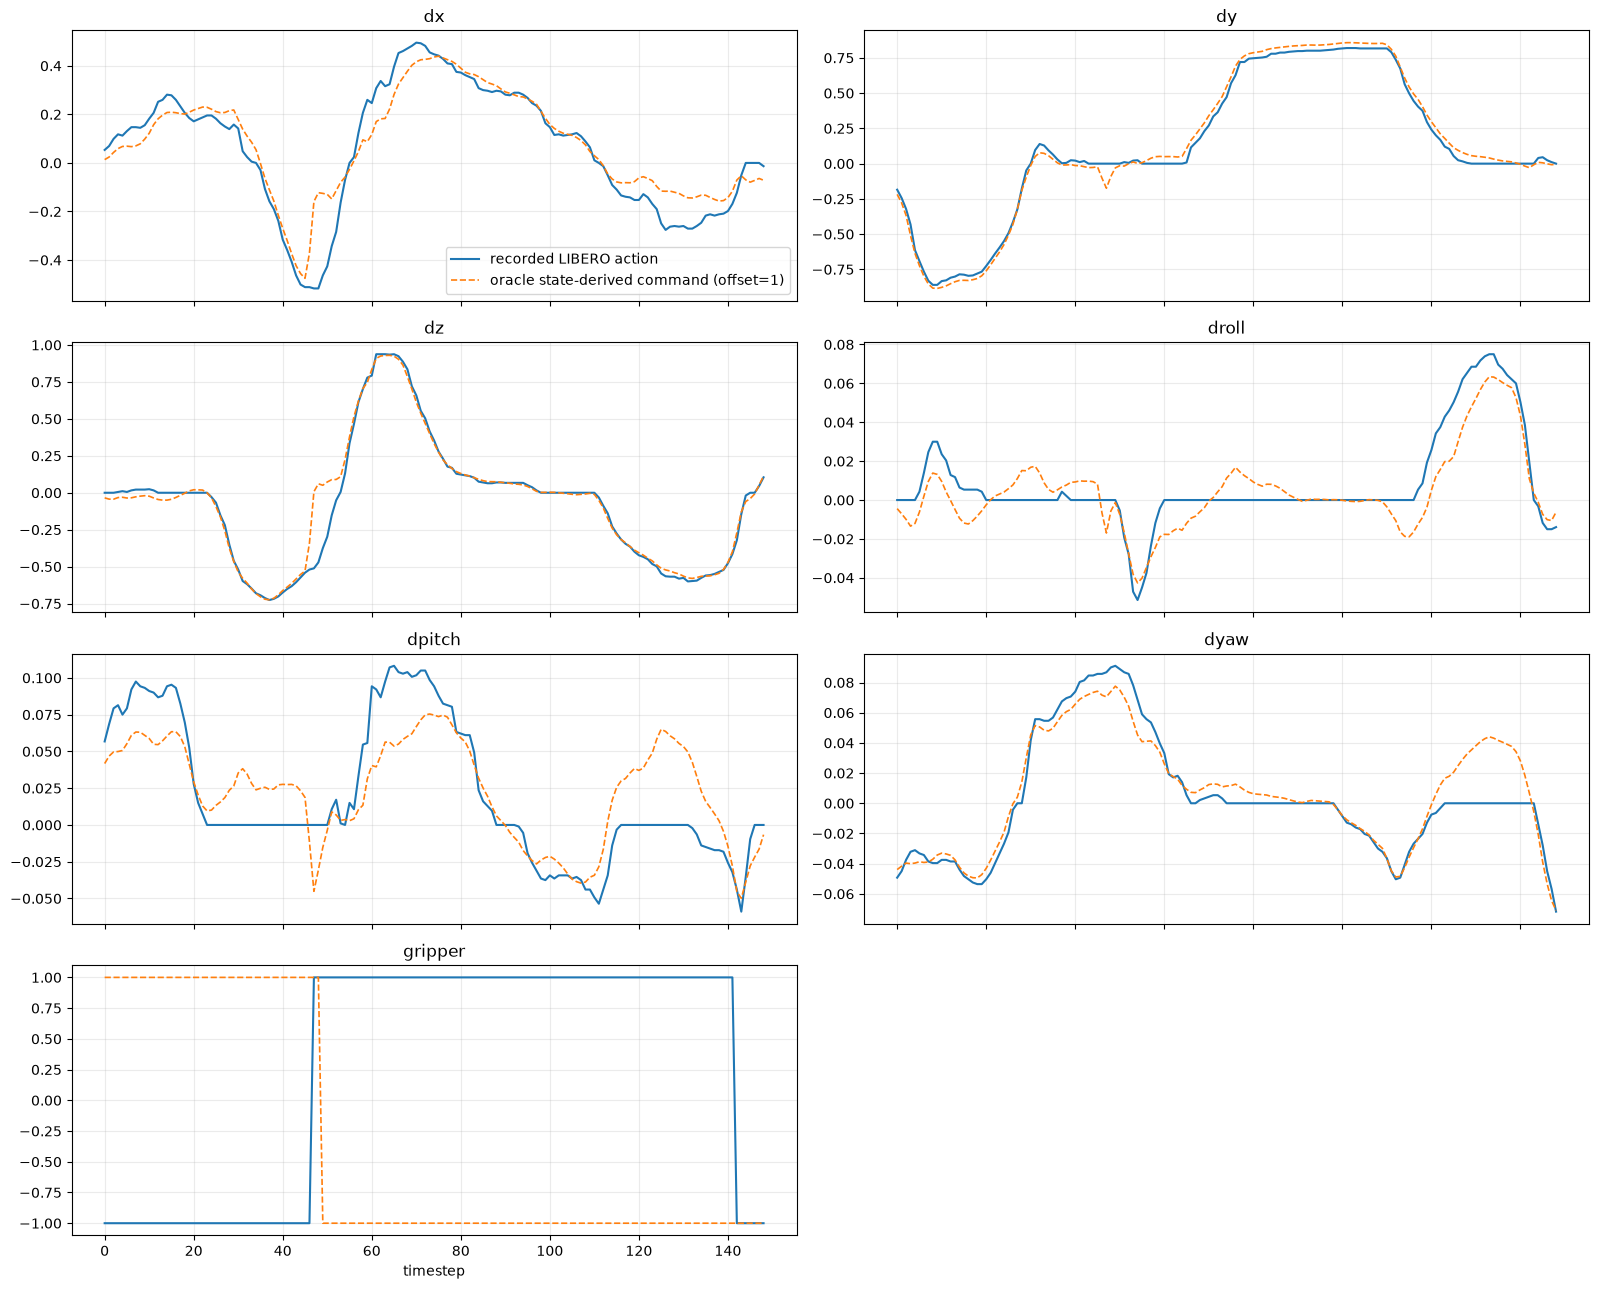

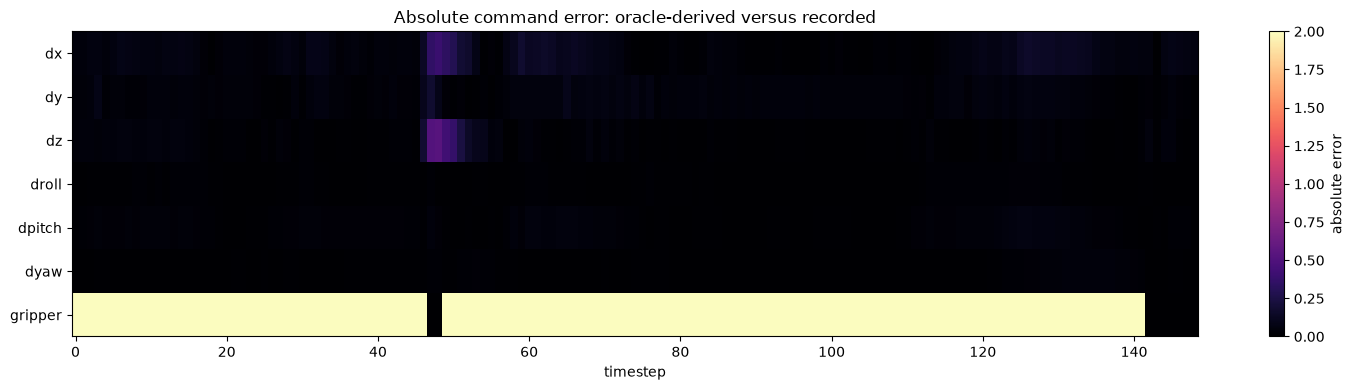

In [35]:
fig, axes = plt.subplots(4, 2, figsize=(16, 13), sharex=True)
axes = axes.ravel()
for dim, name in enumerate(command_names):
    axes[dim].plot(actual_commands[:, dim], label="recorded LIBERO action", linewidth=1.5)
    axes[dim].plot(oracle_commands[:, dim], label=f"oracle state-derived command (offset={TARGET_OFFSET})", linestyle="--", linewidth=1.2)
    axes[dim].set_title(name)
    axes[dim].grid(alpha=0.25)
    if dim == 0: axes[dim].legend()
axes[-1].axis("off")
for ax in axes[-2:]: ax.set_xlabel("timestep")
plt.tight_layout()

plt.figure(figsize=(15, 4))
plt.imshow(np.abs(command_error).T, aspect="auto", interpolation="nearest", cmap="magma")
plt.yticks(np.arange(7), command_names)
plt.xlabel("timestep"); plt.title("Absolute command error: oracle-derived versus recorded")
plt.colorbar(label="absolute error")
plt.tight_layout()

### Diagnose scale and temporal alignment

The next plot sweeps future-state offsets 1–10. It reports the least-squares position and rotation scales that best reproduce the recorded commands, the RMSE when the production scale remains 10, and gripper agreement. Treat fitted scales as diagnostics rather than automatic rollout settings: the state transition is produced by controller dynamics and is not an exact algebraic inverse of the command.

[{'offset': 1,
  'best_pos_scale': 78.82398905616367,
  'best_rot_scale': 7.1629141274061165,
  'fixed_scale10_pos_RMSE': 0.3613978624343872,
  'fixed_scale10_rot_RMSE': 0.02382529526948929,
  'gripper_agreement': 0.06040268456375839},
 {'offset': 2,
  'best_pos_scale': 39.37551159823526,
  'best_rot_scale': 3.593366570813597,
  'fixed_scale10_pos_RMSE': 0.312884122133255,
  'fixed_scale10_rot_RMSE': 0.06480111926794052,
  'gripper_agreement': 0.0472972972972973},
 {'offset': 3,
  'best_pos_scale': 26.1987325284425,
  'best_rot_scale': 2.40435244350327,
  'fixed_scale10_pos_RMSE': 0.2657647430896759,
  'fixed_scale10_rot_RMSE': 0.11101997643709183,
  'gripper_agreement': 0.034013605442176874},
 {'offset': 4,
  'best_pos_scale': 19.588989000664586,
  'best_rot_scale': 1.8090831627833015,
  'fixed_scale10_pos_RMSE': 0.2215135544538498,
  'fixed_scale10_rot_RMSE': 0.1573106348514557,
  'gripper_agreement': 0.03424657534246575},
 {'offset': 5,
  'best_pos_scale': 15.607389576149625,
  'bes

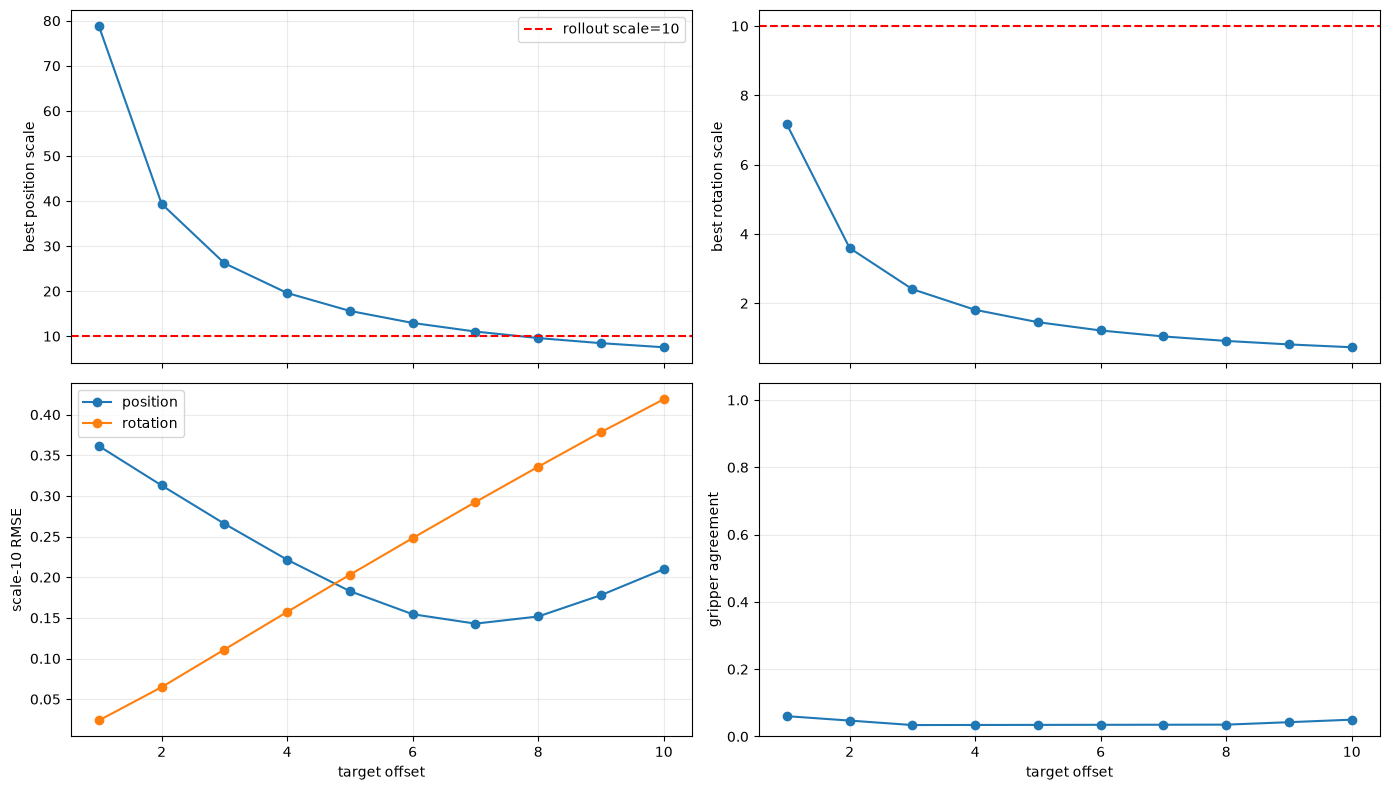

In [33]:
def least_squares_scale(delta, command):
    denominator = float(np.sum(delta * delta))
    return float(np.sum(delta * command) / denominator) if denominator > 1e-12 else np.nan

offset_rows = []
for offset in range(1, min(11, len(states_open))):
    count = min(len(recorded_actions), len(states_open) - offset)
    current = states_open[:count]
    target = states_open[offset:offset + count]
    actual = recorded_actions[:count]
    delta_pos = target[:, :3] - current[:, :3]
    delta_rot = wrap_to_pi(target[:, 3:6] - current[:, 3:6])
    fixed = absolute_targets_to_libero_commands(target, current)
    offset_rows.append({
        "offset": offset,
        "best_pos_scale": least_squares_scale(delta_pos, actual[:, :3]),
        "best_rot_scale": least_squares_scale(delta_rot, actual[:, 3:6]),
        "fixed_scale10_pos_RMSE": float(np.sqrt(np.mean((fixed[:, :3] - actual[:, :3]) ** 2))),
        "fixed_scale10_rot_RMSE": float(np.sqrt(np.mean((fixed[:, 3:6] - actual[:, 3:6]) ** 2))),
        "gripper_agreement": float(np.mean(fixed[:, 6] == actual[:, 6])),
    })
display(offset_rows)

offsets = np.array([row["offset"] for row in offset_rows])
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes[0, 0].plot(offsets, [row["best_pos_scale"] for row in offset_rows], marker="o"); axes[0, 0].axhline(10, color="red", linestyle="--", label="rollout scale=10"); axes[0, 0].set_ylabel("best position scale"); axes[0, 0].legend()
axes[0, 1].plot(offsets, [row["best_rot_scale"] for row in offset_rows], marker="o"); axes[0, 1].axhline(10, color="red", linestyle="--"); axes[0, 1].set_ylabel("best rotation scale")
axes[1, 0].plot(offsets, [row["fixed_scale10_pos_RMSE"] for row in offset_rows], marker="o", label="position"); axes[1, 0].plot(offsets, [row["fixed_scale10_rot_RMSE"] for row in offset_rows], marker="o", label="rotation"); axes[1, 0].set_ylabel("scale-10 RMSE"); axes[1, 0].set_xlabel("target offset"); axes[1, 0].legend()
axes[1, 1].plot(offsets, [row["gripper_agreement"] for row in offset_rows], marker="o"); axes[1, 1].set_ylim(0, 1.05); axes[1, 1].set_ylabel("gripper agreement"); axes[1, 1].set_xlabel("target offset")
for ax in axes.ravel(): ax.grid(alpha=0.25)
plt.tight_layout()

### Comparing actual RDT outputs

The plots above deliberately use perfect recorded future states. To compare the trained model, run `rollout_libero_rdt.py` from this exact demo state with `--demo-hdf5`, `--demo-name`, and `--action-debug-jsonl`. Each JSONL row contains `model_outputs`, `planned_libero_actions_at_replan_start`, and `executed_libero_actions`. The executed commands are the correct quantity to compare with recorded actions because production recomputes each command from the latest live state. Once the rollout diverges from the demonstration, a same-timestep comparison is descriptive rather than a strict error metric—the model and demonstration are then visiting different states.

## 10. Real RDT inference versus recorded LIBERO actions

This section performs actual inference with the trained RDT checkpoint. It uses the exact feature contract used during training:

- **Qwen KV:** loaded from the per-timestep feature cache.
- **T5 language embedding:** loaded from the same cache.
- **SigLIP image features:** recomputed online from the cached current/history camera JPEG slots.
- **RDT:** reconstructed from the configuration embedded inside the selected checkpoint, then loaded with its LoRA and interface weights.

For each selected demonstration timestep, RDT predicts 64 absolute future states. Target index 1 is converted to a LIBERO command using the production scale/clipping formula and compared with the recorded action at that timestep. This is open-loop teacher-forced analysis: every prediction is conditioned on the recorded demonstration observation, so errors do not accumulate between sampled timesteps.

This section requires CUDA. Start with a stride such as 5 because full 126-timestep diffusion inference is expensive. Set `RDT_TIMESTEP_STRIDE = 1` only when the smaller run works.

In [36]:
import json

RDT_BASE_ARTIFACT = REPO_ROOT / "oxe_b0_merged_for_libero"
RDT_ARTIFACT = REPO_ROOT / "outputs/libero_object_all_suites_from_oxe/checkpoint-1000"
RDT_CACHE_ROOT = REPO_ROOT / "thinkflow-libero-features-b0" / SUITE_NAME
RDT_TIMESTEP_STRIDE = 5       # Use 1 for every available timestep
RDT_MAX_TIMESTEPS = None      # Example: 10 for a quick smoke test
RDT_BATCH_SIZE = 1            # Increase cautiously; RDT-1B and image tokens use substantial VRAM
RDT_TARGET_INDEX = 1          # target[0] is current state; target[1] is the first future state
RDT_POS_SCALE = 80.0
RDT_ROT_SCALE = 7.0
RDT_MAX_DELTA_POS = 1.0
RDT_MAX_DELTA_ROT = 1.0
RDT_RANDOM_SEED = 42

with h5py.File(demo_path, "r") as rdt_demo_handle:
    rdt_demo_name, rdt_demo = select_demo(rdt_demo_handle, DEMO_NAME)
    rdt_recorded_actions_all = np.asarray(rdt_demo["actions"][:], dtype=np.float32)[:, :7]

assert RDT_ARTIFACT.exists(), f"Checkpoint not found: {RDT_ARTIFACT}"
assert RDT_CACHE_ROOT.exists(), f"Feature cache not found: {RDT_CACHE_ROOT}"
if not torch.cuda.is_available():
    raise RuntimeError("Real RDT-1B inference requires a CUDA-enabled notebook kernel")
RDT_DEVICE = torch.device("cuda")
print("CUDA device:", torch.cuda.get_device_name(RDT_DEVICE))
print("Artifact:", RDT_ARTIFACT)
print("Cache:", RDT_CACHE_ROOT)

CUDA device: NVIDIA RTX 6000 Ada Generation
Artifact: /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_all_suites_from_oxe/checkpoint-1000
Cache: /home/ubuntu/ThinkFlow-RDT-1B/thinkflow-libero-features-b0/libero_object


In [37]:
from thinkflow_rdt.config import (
    DataConfig, ExperimentConfig, LoraConfigData, ModelConfig, NoiseSchedulerConfig, TrainingConfig,
)

# The repository YAML has evolved since this artifact was trained. Reconstructing
# from metadata prevents a state-layout/Qwen-fusion mismatch.
checkpoint_metadata = json.loads((RDT_ARTIFACT / "metadata.json").read_text(encoding="utf-8"))
saved = checkpoint_metadata["config"]
rdt_cfg = ExperimentConfig(
    seed=int(saved["seed"]),
    rdt_repo=str(saved["rdt_repo"]),
    pretrained_model=saved.get("pretrained_model"),
    output_dir=str(saved["output_dir"]),
    model=ModelConfig(**saved["model"]),
    lora=LoraConfigData(**saved["lora"]),
    noise_scheduler=NoiseSchedulerConfig(**saved["noise_scheduler"]),
    data=DataConfig(**saved["data"]),
    training=TrainingConfig(**saved["training"]),
)
rdt_cfg.validate()
feature_metadata = json.loads((RDT_CACHE_ROOT / "precompute_metadata.json").read_text(encoding="utf-8"))
print("checkpoint step:", checkpoint_metadata["global_step"])
print("prediction horizon:", rdt_cfg.model.pred_horizon)
print("Qwen fusion:", rdt_cfg.model.qwen_fusion)
print("state/action layouts:", rdt_cfg.model.state_encoder_layout, rdt_cfg.model.action_encoder_layout)
print("cached feature set:", feature_metadata.get("feature_set"))

checkpoint step: 1000
prediction horizon: 64
Qwen fusion: cross_attention_kv
state/action layouts: rdt_eef rdt_eef
cached feature set: qwen_t5


In [38]:
from thinkflow_rdt.data import CachedFeatureDataset, ONLINE_SIGLIP_REQUIRED_KEYS

cached_episode_id = f"{demo_path.stem}:{rdt_demo_name}"
cached_matches = []
cached_split = None
cached_manifest = None
for split_name in ("train", "validation", "test"):
    manifest_path = RDT_CACHE_ROOT / split_name / "manifest.jsonl"
    if not manifest_path.exists():
        continue
    global_index = 0
    split_matches = []
    with manifest_path.open("r", encoding="utf-8") as manifest_handle:
        for line in manifest_handle:
            row = json.loads(line)
            shard_path = Path(row["path"])
            if not shard_path.is_absolute():
                shard_path = manifest_path.parent / shard_path
            pack = torch.load(shard_path, map_location="cpu", weights_only=True)
            metadata_rows = pack.get("metadata", [])
            for local_index, metadata_row in enumerate(metadata_rows):
                if metadata_row.get("episode_id") == cached_episode_id:
                    split_matches.append((int(metadata_row["step_idx"]), global_index + local_index))
            global_index += int(row.get("num_samples", 1))
    if split_matches:
        if cached_matches:
            raise RuntimeError(f"Episode unexpectedly appears in multiple splits: {cached_episode_id}")
        cached_matches = sorted(split_matches)
        cached_split = split_name
        cached_manifest = manifest_path

if not cached_matches or cached_manifest is None:
    raise LookupError(f"No cached samples found for {cached_episode_id}")
rdt_cached_dataset = CachedFeatureDataset(
    cached_manifest, required_keys=ONLINE_SIGLIP_REQUIRED_KEYS,
)
cached_index_by_step = dict(cached_matches)
rdt_inference_steps = np.asarray(sorted(cached_index_by_step), dtype=int)[::RDT_TIMESTEP_STRIDE]
rdt_inference_steps = rdt_inference_steps[rdt_inference_steps < len(rdt_recorded_actions_all)]
if RDT_MAX_TIMESTEPS is not None:
    rdt_inference_steps = rdt_inference_steps[:RDT_MAX_TIMESTEPS]
print("cached episode:", cached_episode_id)
print("split:", cached_split)
print("cached timesteps:", len(cached_matches))
print("inference timesteps:", rdt_inference_steps.tolist())

cached episode: pick_up_the_milk_and_place_it_in_the_basket_demo:demo_0
split: validation
cached timesteps: 150
inference timesteps: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145]


### Load RDT and frozen SigLIP

This is the memory-intensive cell. Qwen and T5 models are intentionally not loaded because their exact cached outputs are used; loading the encoders again would consume memory without changing the conditioning tensors. SigLIP must be loaded because this checkpoint was trained with online SigLIP extraction. If you rerun the cell, the previous model objects are deleted first.

In [39]:
import gc
from thinkflow_rdt.checkpoint import load_trainable_artifact
from thinkflow_rdt.model import SFTConditionedRDT
from thinkflow_rdt.train import add_online_siglip_features, load_online_siglip

for object_name in ("rdt_model", "rdt_siglip", "rdt_siglip_processor"):
    if object_name in globals():
        del globals()[object_name]
gc.collect(); torch.cuda.empty_cache()

siglip_id = feature_metadata.get("siglip_model_id", "google/siglip-so400m-patch14-384")
rdt_siglip_processor, rdt_siglip = load_online_siglip(
    model_id=siglip_id, fallback_model_id="google/siglip-so400m-patch14-384",
    cfg=rdt_cfg, device=RDT_DEVICE,
)
print("Loaded SigLIP:", siglip_id)
rdt_model = SFTConditionedRDT(rdt_cfg, load_pretrained=True, base_artifact=str(RDT_BASE_ARTIFACT))
load_trainable_artifact(rdt_model, RDT_ARTIFACT, trainable=False)
rdt_model.to(RDT_DEVICE).eval()
print("Loaded RDT artifact; model dtype:", rdt_model.model_dtype)
print("Allocated CUDA memory (GiB):", torch.cuda.memory_allocated() / 2**30)

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 448/448 [00:01<00:00, 291.53it/s]
[transformers] SiglipVisionModel LOAD REPORT from: google/siglip-so400m-patch14-384
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...26}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder

Loaded SigLIP: google/siglip-so400m-patch14-384
Diffusion params: 1.217844e+09
Diffusion params: 1.228320e+09
Loaded RDT artifact; model dtype: torch.bfloat16
Allocated CUDA memory (GiB): 3.24820613861084


In [40]:
from thinkflow_rdt.data import RDTOnlineSiglipBatchCollator

rdt_collator = RDTOnlineSiglipBatchCollator(
    max_lang_tokens=rdt_cfg.model.max_lang_tokens,
    pred_horizon=rdt_cfg.model.pred_horizon,
    feature_dim=rdt_cfg.model.qwen_hidden_size,
    state_dim=rdt_cfg.model.state_dim,
    action_dim=rdt_cfg.model.action_dim,
    lang_token_dim=rdt_cfg.model.lang_token_dim,
    qwen_kv_dim=rdt_cfg.model.qwen_kv_dim,
)
rdt_predicted_horizons = {}
rdt_predicted_commands = []
rdt_recorded_commands = []
rdt_predicted_next_states = []
rdt_recorded_next_states = []

def rdt_target_states_to_commands(target_open, current_open):
    target_open = np.asarray(target_open, dtype=np.float32)
    current_open = np.asarray(current_open, dtype=np.float32)
    command = np.zeros_like(target_open, dtype=np.float32)
    command[..., :3] = np.clip(
        (target_open[..., :3] - current_open[..., :3]) * RDT_POS_SCALE,
        -RDT_MAX_DELTA_POS, RDT_MAX_DELTA_POS,
    )
    rotation_difference = target_open[..., 3:6] - current_open[..., 3:6]
    wrapped_rotation = np.arctan2(np.sin(rotation_difference), np.cos(rotation_difference))
    command[..., 3:6] = np.clip(
        wrapped_rotation * RDT_ROT_SCALE, -RDT_MAX_DELTA_ROT, RDT_MAX_DELTA_ROT,
    )
    command[..., 6] = np.where(target_open[..., 6] >= 0.5, 1.0, -1.0)
    return command

for batch_start in range(0, len(rdt_inference_steps), RDT_BATCH_SIZE):
    batch_steps = rdt_inference_steps[batch_start:batch_start + RDT_BATCH_SIZE]
    samples = [rdt_cached_dataset[cached_index_by_step[int(step)]] for step in batch_steps]
    batch = rdt_collator(samples)
    batch = add_online_siglip_features(
        batch, processor=rdt_siglip_processor, encoder=rdt_siglip,
        cfg=rdt_cfg, device=RDT_DEVICE,
    )
    batch_on_device = {
        key: value.to(RDT_DEVICE) if isinstance(value, torch.Tensor) else value
        for key, value in batch.items()
    }
    torch.manual_seed(RDT_RANDOM_SEED + int(batch_steps[0]))
    torch.cuda.manual_seed_all(RDT_RANDOM_SEED + int(batch_steps[0]))
    with torch.inference_mode():
        predicted_horizons = rdt_model.sample_actions(batch_on_device).float().cpu().numpy()

    current_open = batch["state"].float().cpu().numpy()
    recorded_targets_open = batch["actions"].float().cpu().numpy()
    for local_index, step in enumerate(batch_steps):
        step = int(step)
        predicted_horizon = predicted_horizons[local_index]
        rdt_predicted_horizons[step] = predicted_horizon
        predicted_target_open = predicted_horizon[RDT_TARGET_INDEX]
        predicted_command = rdt_target_states_to_commands(
            predicted_target_open[None], current_open[local_index:local_index + 1],
        )[0]
        rdt_predicted_commands.append(predicted_command)
        rdt_recorded_commands.append(rdt_recorded_actions_all[step])
        rdt_predicted_next_states.append(predicted_target_open)
        rdt_recorded_next_states.append(recorded_targets_open[local_index, RDT_TARGET_INDEX])
    print(f"inferred {min(batch_start + len(batch_steps), len(rdt_inference_steps))}/{len(rdt_inference_steps)} timesteps", flush=True)
    del batch_on_device, predicted_horizons
    torch.cuda.empty_cache()

rdt_predicted_commands = np.asarray(rdt_predicted_commands, dtype=np.float32)
rdt_recorded_commands = np.asarray(rdt_recorded_commands, dtype=np.float32)
rdt_predicted_next_states = np.asarray(rdt_predicted_next_states, dtype=np.float32)
rdt_recorded_next_states = np.asarray(rdt_recorded_next_states, dtype=np.float32)
print("predicted horizons:", len(rdt_predicted_horizons), "x", next(iter(rdt_predicted_horizons.values())).shape)
print("converted commands:", rdt_predicted_commands.shape)

inferred 1/30 timesteps
inferred 2/30 timesteps
inferred 3/30 timesteps
inferred 4/30 timesteps
inferred 5/30 timesteps
inferred 6/30 timesteps
inferred 7/30 timesteps
inferred 8/30 timesteps
inferred 9/30 timesteps
inferred 10/30 timesteps
inferred 11/30 timesteps
inferred 12/30 timesteps
inferred 13/30 timesteps
inferred 14/30 timesteps
inferred 15/30 timesteps
inferred 16/30 timesteps
inferred 17/30 timesteps
inferred 18/30 timesteps
inferred 19/30 timesteps
inferred 20/30 timesteps
inferred 21/30 timesteps
inferred 22/30 timesteps
inferred 23/30 timesteps
inferred 24/30 timesteps
inferred 25/30 timesteps
inferred 26/30 timesteps
inferred 27/30 timesteps
inferred 28/30 timesteps
inferred 29/30 timesteps
inferred 30/30 timesteps
predicted horizons: 30 x (64, 7)
converted commands: (30, 7)


[{'dimension': 'dx',
  'MAE': 0.8685497641563416,
  'RMSE': 0.9138340353965759,
  'correlation': 0.18568975774496},
 {'dimension': 'dy',
  'MAE': 0.5601826906204224,
  'RMSE': 0.6868178248405457,
  'correlation': 0.5808103927644863},
 {'dimension': 'dz',
  'MAE': 0.932521641254425,
  'RMSE': 1.0650585889816284,
  'correlation': -0.01454319179336568},
 {'dimension': 'droll',
  'MAE': 0.09905720502138138,
  'RMSE': 0.12086758762598038,
  'correlation': 0.2265425581488425},
 {'dimension': 'dpitch',
  'MAE': 0.08707089722156525,
  'RMSE': 0.1085718423128128,
  'correlation': 0.45820899646829427},
 {'dimension': 'dyaw',
  'MAE': 0.46387940645217896,
  'RMSE': 0.49073609709739685,
  'correlation': 0.3659355286391536},
 {'dimension': 'gripper',
  'MAE': 0.7333333492279053,
  'RMSE': 1.2110601663589478,
  'correlation': nan}]

RDT gripper command agreement: 0.6333333333333333


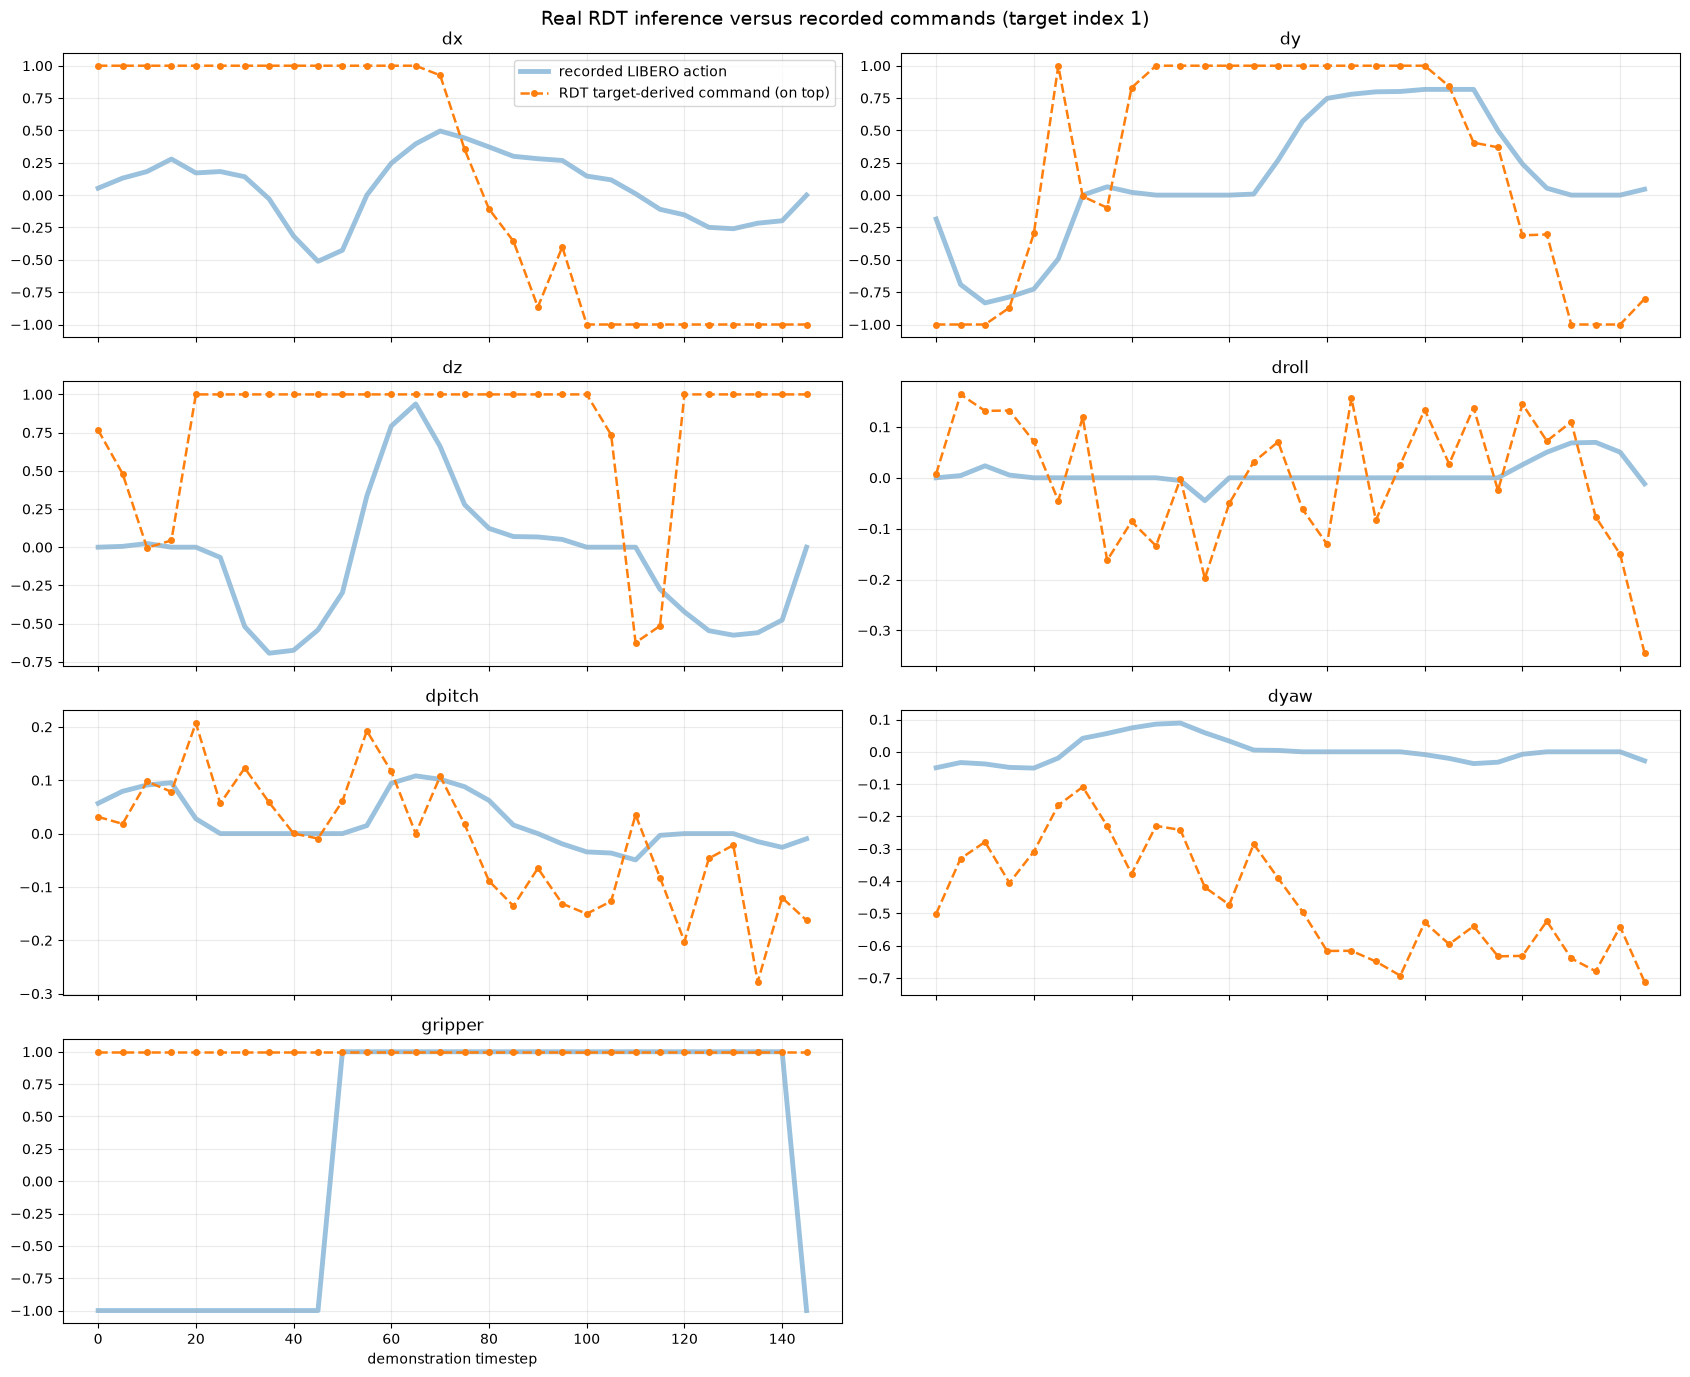

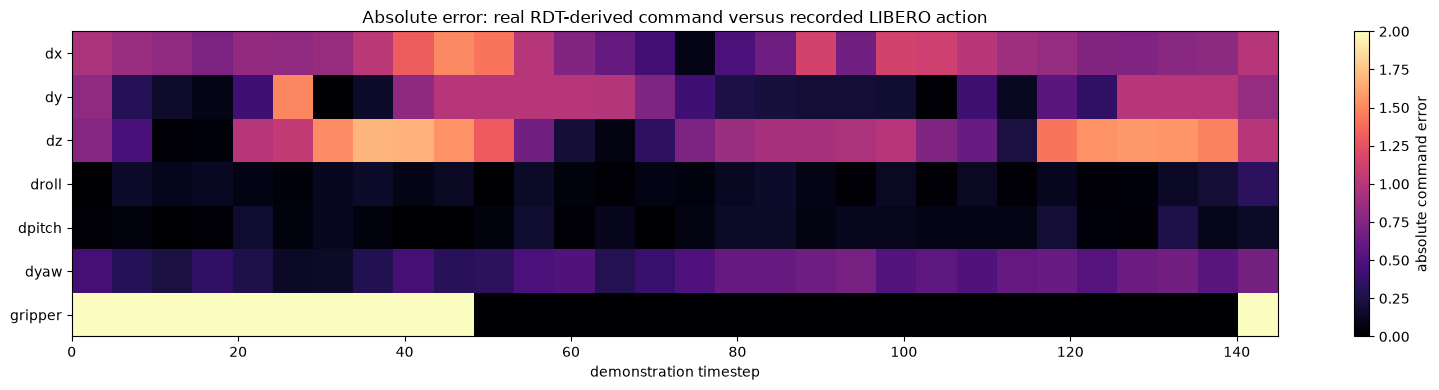

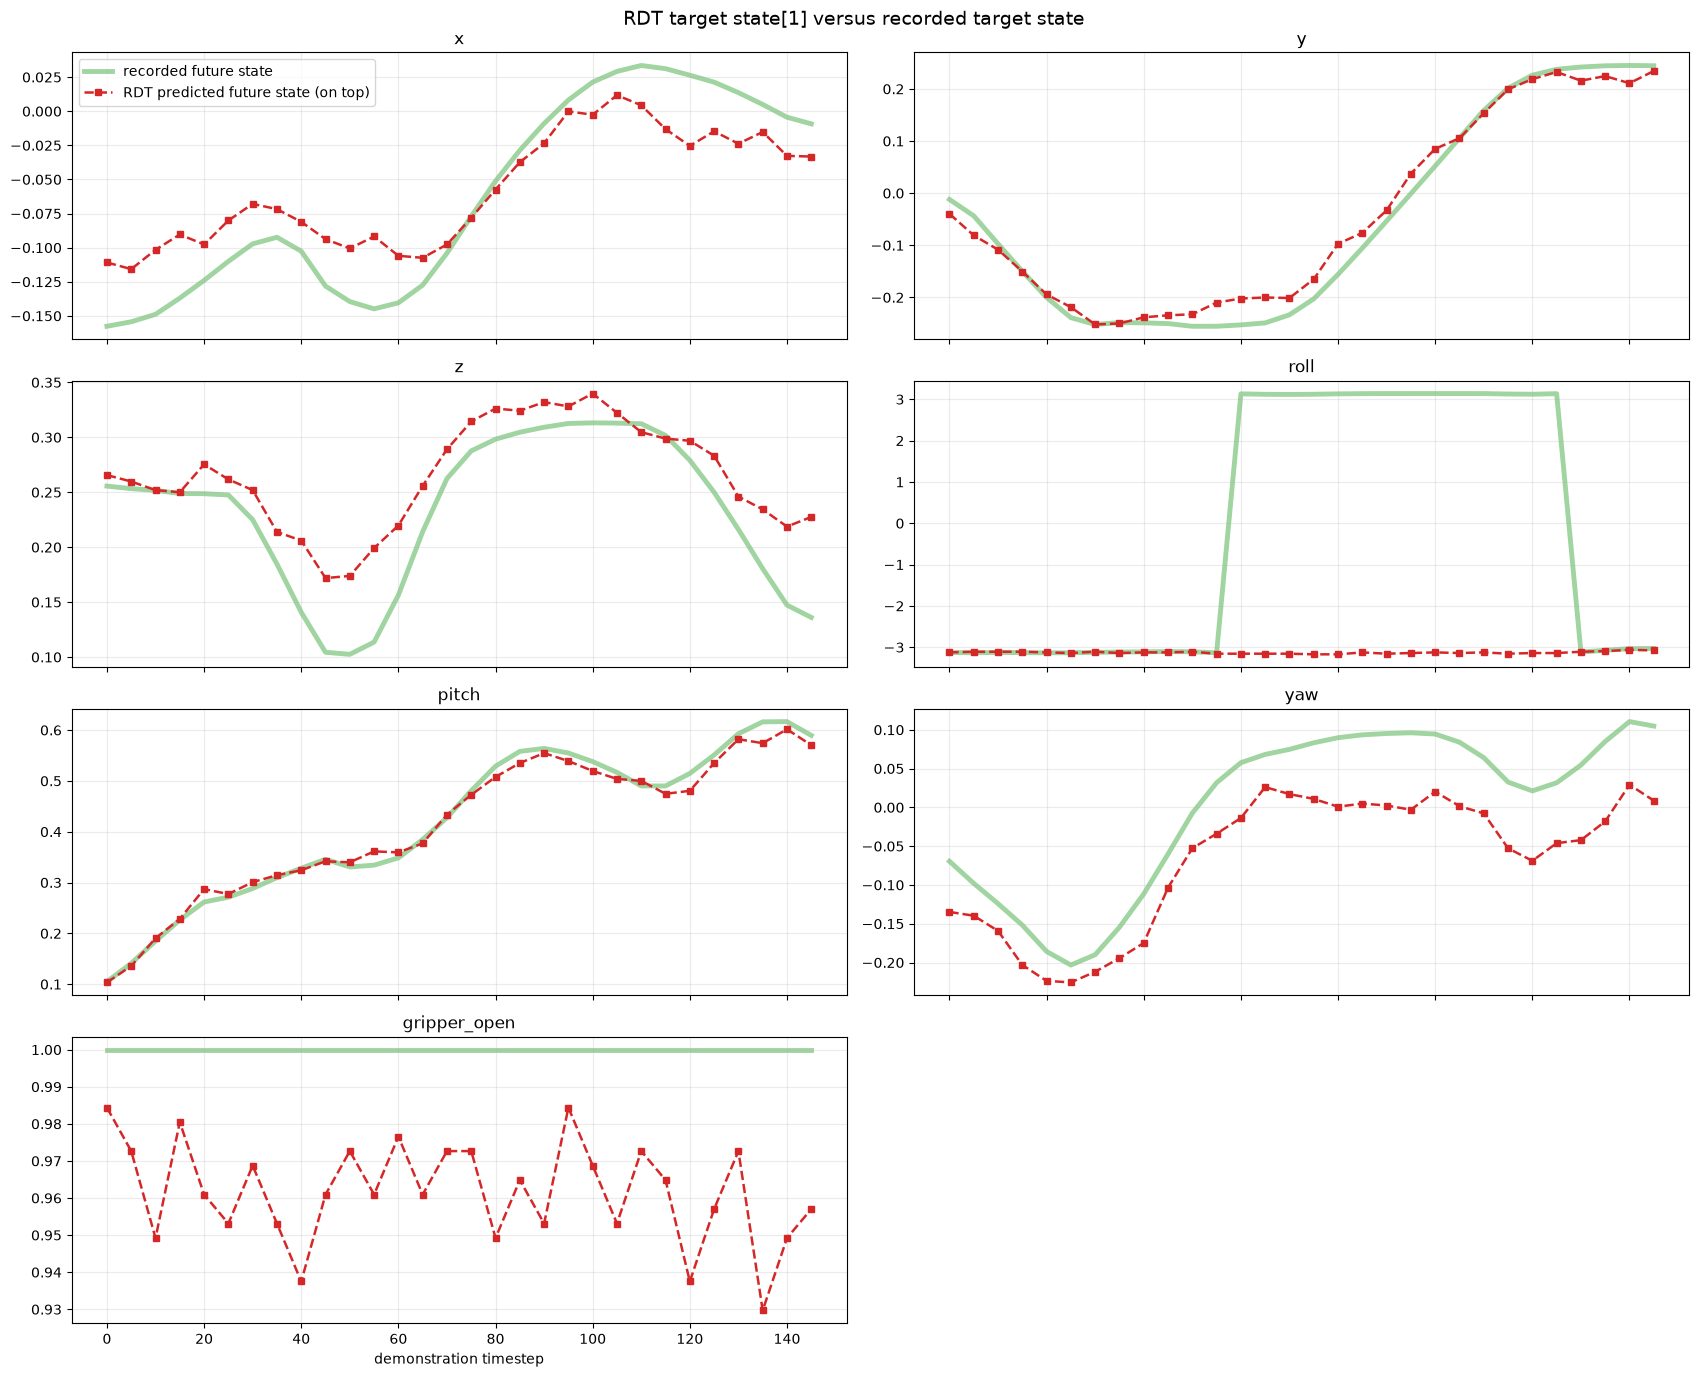

In [41]:
command_names = ["dx", "dy", "dz", "droll", "dpitch", "dyaw", "gripper"]
rdt_command_error = rdt_predicted_commands - rdt_recorded_commands
rdt_metrics = []
for dim, name in enumerate(command_names):
    actual_dim = rdt_recorded_commands[:, dim]
    predicted_dim = rdt_predicted_commands[:, dim]
    correlation = np.corrcoef(actual_dim, predicted_dim)[0, 1] if actual_dim.std() > 1e-8 and predicted_dim.std() > 1e-8 else np.nan
    rdt_metrics.append({
        "dimension": name,
        "MAE": float(np.mean(np.abs(rdt_command_error[:, dim]))),
        "RMSE": float(np.sqrt(np.mean(rdt_command_error[:, dim] ** 2))),
        "correlation": float(correlation),
    })
display(rdt_metrics)
print("RDT gripper command agreement:", np.mean(rdt_predicted_commands[:, 6] == rdt_recorded_commands[:, 6]))

fig, axes = plt.subplots(4, 2, figsize=(17, 14), sharex=True)
axes = axes.ravel()
for dim, name in enumerate(command_names):
    axes[dim].plot(rdt_inference_steps, rdt_recorded_commands[:, dim], color="tab:blue", linewidth=3.5, alpha=0.45, zorder=1, label="recorded LIBERO action")
    axes[dim].plot(rdt_inference_steps, rdt_predicted_commands[:, dim], color="tab:orange", linestyle="--", marker="o", markersize=4, linewidth=1.8, zorder=3, label="RDT target-derived command (on top)")
    axes[dim].set_title(name); axes[dim].grid(alpha=0.25)
    if dim == 0: axes[dim].legend()
axes[-1].axis("off")
for ax in axes[-2:]: ax.set_xlabel("demonstration timestep")
fig.suptitle(f"Real RDT inference versus recorded commands (target index {RDT_TARGET_INDEX})", fontsize=14)
plt.tight_layout()

plt.figure(figsize=(16, 4))
plt.imshow(np.abs(rdt_command_error).T, aspect="auto", interpolation="nearest", cmap="magma", extent=[rdt_inference_steps[0], rdt_inference_steps[-1], 6.5, -0.5])
plt.yticks(np.arange(7), command_names); plt.xlabel("demonstration timestep")
plt.title("Absolute error: real RDT-derived command versus recorded LIBERO action")
plt.colorbar(label="absolute command error"); plt.tight_layout()

# Separate model target-state error from target-state-to-command conversion error.
target_state_names = ["x", "y", "z", "roll", "pitch", "yaw", "gripper_open"]
fig, axes = plt.subplots(4, 2, figsize=(17, 14), sharex=True)
axes = axes.ravel()
for dim, name in enumerate(target_state_names):
    axes[dim].plot(rdt_inference_steps, rdt_recorded_next_states[:, dim], color="tab:green", linewidth=3.5, alpha=0.45, zorder=1, label="recorded future state")
    axes[dim].plot(rdt_inference_steps, rdt_predicted_next_states[:, dim], color="tab:red", linestyle="--", marker="s", markersize=4, linewidth=1.8, zorder=3, label="RDT predicted future state (on top)")
    axes[dim].set_title(name); axes[dim].grid(alpha=0.25)
    if dim == 0: axes[dim].legend()
axes[-1].axis("off")
for ax in axes[-2:]: ax.set_xlabel("demonstration timestep")
fig.suptitle(f"RDT target state[{RDT_TARGET_INDEX}] versus recorded target state", fontsize=14)
plt.tight_layout()

## 11. RDT action-chunk comparison: re-infer every 4 or 8 steps

This evaluates the rollout schedule you described while remaining aligned to the recorded demonstration. For chunk size 4:

```text
anchor 0: infer horizon, compare predicted targets 1–4 with recorded actions 0–3
anchor 4: infer horizon, compare predicted targets 1–4 with recorded actions 4–7
anchor 8: infer horizon, compare predicted targets 1–4 with recorded actions 8–11
```

Chunk size 8 follows the same pattern at anchors 0, 8, 16, and so on. Predicted target `j` is converted using the recorded current state at `anchor + j - 1`, matching rollout's behavior of recomputing the command from the latest state before every executed action.

This is a **teacher-forced chunk evaluation**: each re-inference anchor uses the recorded cached observation, Qwen KV, T5 embedding, and SigLIP images. It measures model/conversion quality without compounding simulator drift. The RDT and SigLIP objects must still be loaded, so run this section before the GPU cleanup cell.

In [42]:
RDT_ACTION_CHUNK_SIZES = (4, 8)
RDT_CHUNK_MAX_ANCHORS = None  # Example: 3 for a quick smoke test per chunk size

if "rdt_model" not in globals() or "rdt_siglip" not in globals():
    raise RuntimeError("Run the 'Load RDT and frozen SigLIP' cell before chunked inference")

# Make the chunk section usable even if the earlier single-step inference cell was skipped.
if "rdt_collator" not in globals():
    from thinkflow_rdt.data import RDTOnlineSiglipBatchCollator
    rdt_collator = RDTOnlineSiglipBatchCollator(
        max_lang_tokens=rdt_cfg.model.max_lang_tokens,
        pred_horizon=rdt_cfg.model.pred_horizon,
        feature_dim=rdt_cfg.model.qwen_hidden_size,
        state_dim=rdt_cfg.model.state_dim,
        action_dim=rdt_cfg.model.action_dim,
        lang_token_dim=rdt_cfg.model.lang_token_dim,
        qwen_kv_dim=rdt_cfg.model.qwen_kv_dim,
    )
if "rdt_target_states_to_commands" not in globals():
    def rdt_target_states_to_commands(target_open, current_open):
        target_open = np.asarray(target_open, dtype=np.float32)
        current_open = np.asarray(current_open, dtype=np.float32)
        command = np.zeros_like(target_open, dtype=np.float32)
        command[..., :3] = np.clip((target_open[..., :3] - current_open[..., :3]) * RDT_POS_SCALE, -RDT_MAX_DELTA_POS, RDT_MAX_DELTA_POS)
        rotation_difference = target_open[..., 3:6] - current_open[..., 3:6]
        wrapped_rotation = np.arctan2(np.sin(rotation_difference), np.cos(rotation_difference))
        command[..., 3:6] = np.clip(wrapped_rotation * RDT_ROT_SCALE, -RDT_MAX_DELTA_ROT, RDT_MAX_DELTA_ROT)
        command[..., 6] = np.where(target_open[..., 6] >= 0.5, 1.0, -1.0)
        return command

available_cached_steps = set(cached_index_by_step)
last_action_step = min(len(rdt_recorded_actions_all), max(available_cached_steps))
chunk_anchors_by_size = {}
for chunk_size in RDT_ACTION_CHUNK_SIZES:
    anchors = [
        anchor for anchor in range(0, last_action_step, chunk_size)
        if anchor in available_cached_steps and anchor + 1 in available_cached_steps
    ]
    if RDT_CHUNK_MAX_ANCHORS is not None:
        anchors = anchors[:RDT_CHUNK_MAX_ANCHORS]
    chunk_anchors_by_size[chunk_size] = anchors

all_chunk_anchors = sorted(set().union(*chunk_anchors_by_size.values()))
# Reuse any horizons already sampled by Section 10 with the same per-anchor seed.
chunk_horizons = dict(globals().get("rdt_predicted_horizons", {}))
missing_chunk_anchors = [anchor for anchor in all_chunk_anchors if anchor not in chunk_horizons]
print("chunk anchors required:", len(all_chunk_anchors))
print("reusing existing horizons:", len(all_chunk_anchors) - len(missing_chunk_anchors))
print("new horizons to infer:", len(missing_chunk_anchors))

for batch_start in range(0, len(missing_chunk_anchors), RDT_BATCH_SIZE):
    batch_anchors = missing_chunk_anchors[batch_start:batch_start + RDT_BATCH_SIZE]
    samples = [rdt_cached_dataset[cached_index_by_step[anchor]] for anchor in batch_anchors]
    batch = rdt_collator(samples)
    batch = add_online_siglip_features(
        batch, processor=rdt_siglip_processor, encoder=rdt_siglip,
        cfg=rdt_cfg, device=RDT_DEVICE,
    )
    batch_on_device = {
        key: value.to(RDT_DEVICE) if isinstance(value, torch.Tensor) else value
        for key, value in batch.items()
    }
    torch.manual_seed(RDT_RANDOM_SEED + int(batch_anchors[0]))
    torch.cuda.manual_seed_all(RDT_RANDOM_SEED + int(batch_anchors[0]))
    with torch.inference_mode():
        inferred = rdt_model.sample_actions(batch_on_device).float().cpu().numpy()
    for local_index, anchor in enumerate(batch_anchors):
        chunk_horizons[int(anchor)] = inferred[local_index]
    completed = min(batch_start + len(batch_anchors), len(missing_chunk_anchors))
    print(f"inferred missing chunk anchors {completed}/{len(missing_chunk_anchors)}", flush=True)
    del batch_on_device, inferred
    torch.cuda.empty_cache()

# Load recorded current states once and flip cached closed -> model open convention.
recorded_open_state_by_step = {}
for step in sorted(available_cached_steps):
    sample_state = np.asarray(
        rdt_cached_dataset[cached_index_by_step[step]]["state"], dtype=np.float32,
    ).copy()
    sample_state[6] = 1.0 - sample_state[6]
    recorded_open_state_by_step[int(step)] = sample_state

rdt_chunk_results = {}
for chunk_size, anchors in chunk_anchors_by_size.items():
    rows = []
    for anchor in anchors:
        predicted_horizon = chunk_horizons[anchor]
        usable_offsets = min(chunk_size, rdt_cfg.model.pred_horizon - 1)
        for target_offset in range(1, usable_offsets + 1):
            action_step = anchor + target_offset - 1
            target_step = anchor + target_offset
            if (
                action_step >= len(rdt_recorded_actions_all)
                or action_step not in recorded_open_state_by_step
                or target_step not in recorded_open_state_by_step
            ):
                break
            predicted_target_open = predicted_horizon[target_offset]
            recorded_current_open = recorded_open_state_by_step[action_step]
            predicted_command = rdt_target_states_to_commands(
                predicted_target_open[None], recorded_current_open[None],
            )[0]
            rows.append({
                "anchor": anchor,
                "target_offset": target_offset,
                "action_step": action_step,
                "display_step": target_step,
                "predicted_command": predicted_command,
                "recorded_command": rdt_recorded_actions_all[action_step].copy(),
                "predicted_target_open": predicted_target_open.copy(),
                "recorded_target_open": recorded_open_state_by_step[target_step].copy(),
            })
    rdt_chunk_results[chunk_size] = rows
    print(f"chunk={chunk_size}: anchors={len(anchors)}, compared actions={len(rows)}")

chunk anchors required: 38
reusing existing horizons: 8
new horizons to infer: 30
inferred missing chunk anchors 1/30
inferred missing chunk anchors 2/30
inferred missing chunk anchors 3/30
inferred missing chunk anchors 4/30
inferred missing chunk anchors 5/30
inferred missing chunk anchors 6/30
inferred missing chunk anchors 7/30
inferred missing chunk anchors 8/30
inferred missing chunk anchors 9/30
inferred missing chunk anchors 10/30
inferred missing chunk anchors 11/30
inferred missing chunk anchors 12/30
inferred missing chunk anchors 13/30
inferred missing chunk anchors 14/30
inferred missing chunk anchors 15/30
inferred missing chunk anchors 16/30
inferred missing chunk anchors 17/30
inferred missing chunk anchors 18/30
inferred missing chunk anchors 19/30
inferred missing chunk anchors 20/30
inferred missing chunk anchors 21/30
inferred missing chunk anchors 22/30
inferred missing chunk anchors 23/30
inferred missing chunk anchors 24/30
inferred missing chunk anchors 25/30
in

chunk=4 overall RMSE=0.79959 gripper agreement=0.638
chunk=8 overall RMSE=0.82716 gripper agreement=0.638


[{'chunk_size': 4,
  'dimension': 'dx',
  'MAE': 0.906141459941864,
  'RMSE': 0.9547557234764099,
  'correlation': 0.15565594323641768},
 {'chunk_size': 4,
  'dimension': 'dy',
  'MAE': 0.688666045665741,
  'RMSE': 0.8174411654472351,
  'correlation': 0.36188865473157794},
 {'chunk_size': 4,
  'dimension': 'dz',
  'MAE': 0.9258864521980286,
  'RMSE': 1.0573301315307617,
  'correlation': -0.007588543468736084},
 {'chunk_size': 4,
  'dimension': 'droll',
  'MAE': 0.11553338170051575,
  'RMSE': 0.14650599658489227,
  'correlation': 0.04258711378172905},
 {'chunk_size': 4,
  'dimension': 'dpitch',
  'MAE': 0.11164795607328415,
  'RMSE': 0.13772104680538177,
  'correlation': 0.03077778914663802},
 {'chunk_size': 4,
  'dimension': 'dyaw',
  'MAE': 0.5083427429199219,
  'RMSE': 0.5362741351127625,
  'correlation': 0.014721368282325037},
 {'chunk_size': 4,
  'dimension': 'gripper',
  'MAE': 0.7248322367668152,
  'RMSE': 1.2040201425552368,
  'correlation': nan},
 {'chunk_size': 8,
  'dimension

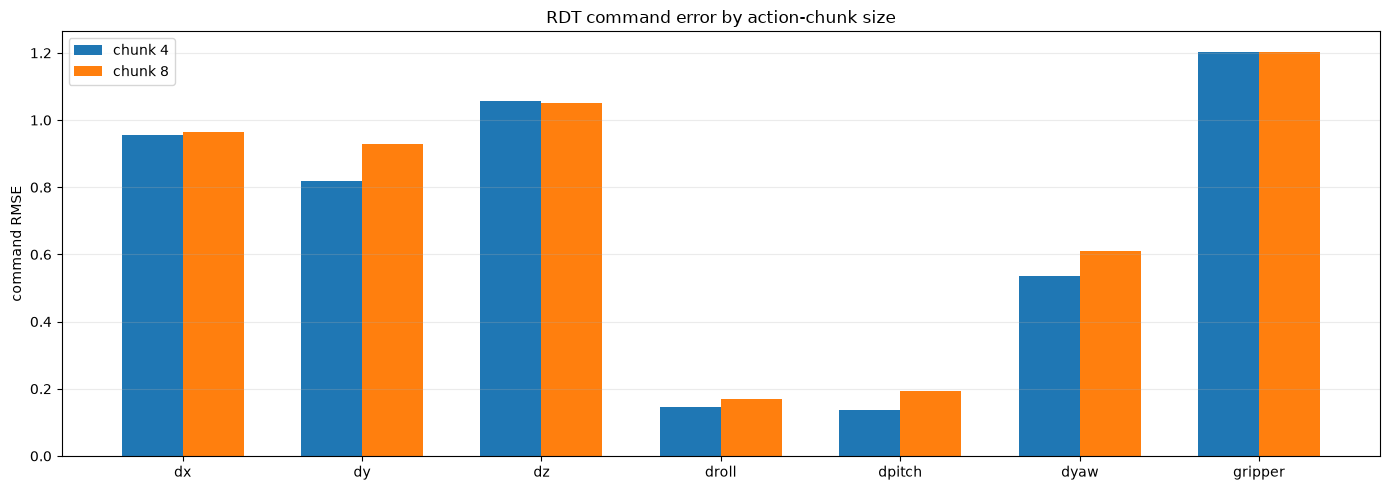

In [43]:
chunk_command_names = ["dx", "dy", "dz", "droll", "dpitch", "dyaw", "gripper"]
rdt_chunk_metrics = []
for chunk_size, rows in rdt_chunk_results.items():
    predicted = np.stack([row["predicted_command"] for row in rows])
    recorded = np.stack([row["recorded_command"] for row in rows])
    error = predicted - recorded
    for dim, name in enumerate(chunk_command_names):
        actual_dim, predicted_dim = recorded[:, dim], predicted[:, dim]
        correlation = np.corrcoef(actual_dim, predicted_dim)[0, 1] if actual_dim.std() > 1e-8 and predicted_dim.std() > 1e-8 else np.nan
        rdt_chunk_metrics.append({
            "chunk_size": chunk_size,
            "dimension": name,
            "MAE": float(np.mean(np.abs(error[:, dim]))),
            "RMSE": float(np.sqrt(np.mean(error[:, dim] ** 2))),
            "correlation": float(correlation),
        })
    print(
        f"chunk={chunk_size} overall RMSE={np.sqrt(np.mean(error ** 2)):.5f} "
        f"gripper agreement={np.mean(predicted[:, 6] == recorded[:, 6]):.3f}"
    )
display(rdt_chunk_metrics)

# Direct chunk-4 versus chunk-8 RMSE comparison by command dimension.
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(chunk_command_names)); width = 0.34
for plot_index, chunk_size in enumerate(RDT_ACTION_CHUNK_SIZES):
    values = [
        next(row["RMSE"] for row in rdt_chunk_metrics if row["chunk_size"] == chunk_size and row["dimension"] == name)
        for name in chunk_command_names
    ]
    ax.bar(x + (plot_index - 0.5) * width, values, width=width, label=f"chunk {chunk_size}")
ax.set_xticks(x, chunk_command_names); ax.set_ylabel("command RMSE")
ax.set_title("RDT command error by action-chunk size"); ax.legend(); ax.grid(axis="y", alpha=0.25)
plt.tight_layout()

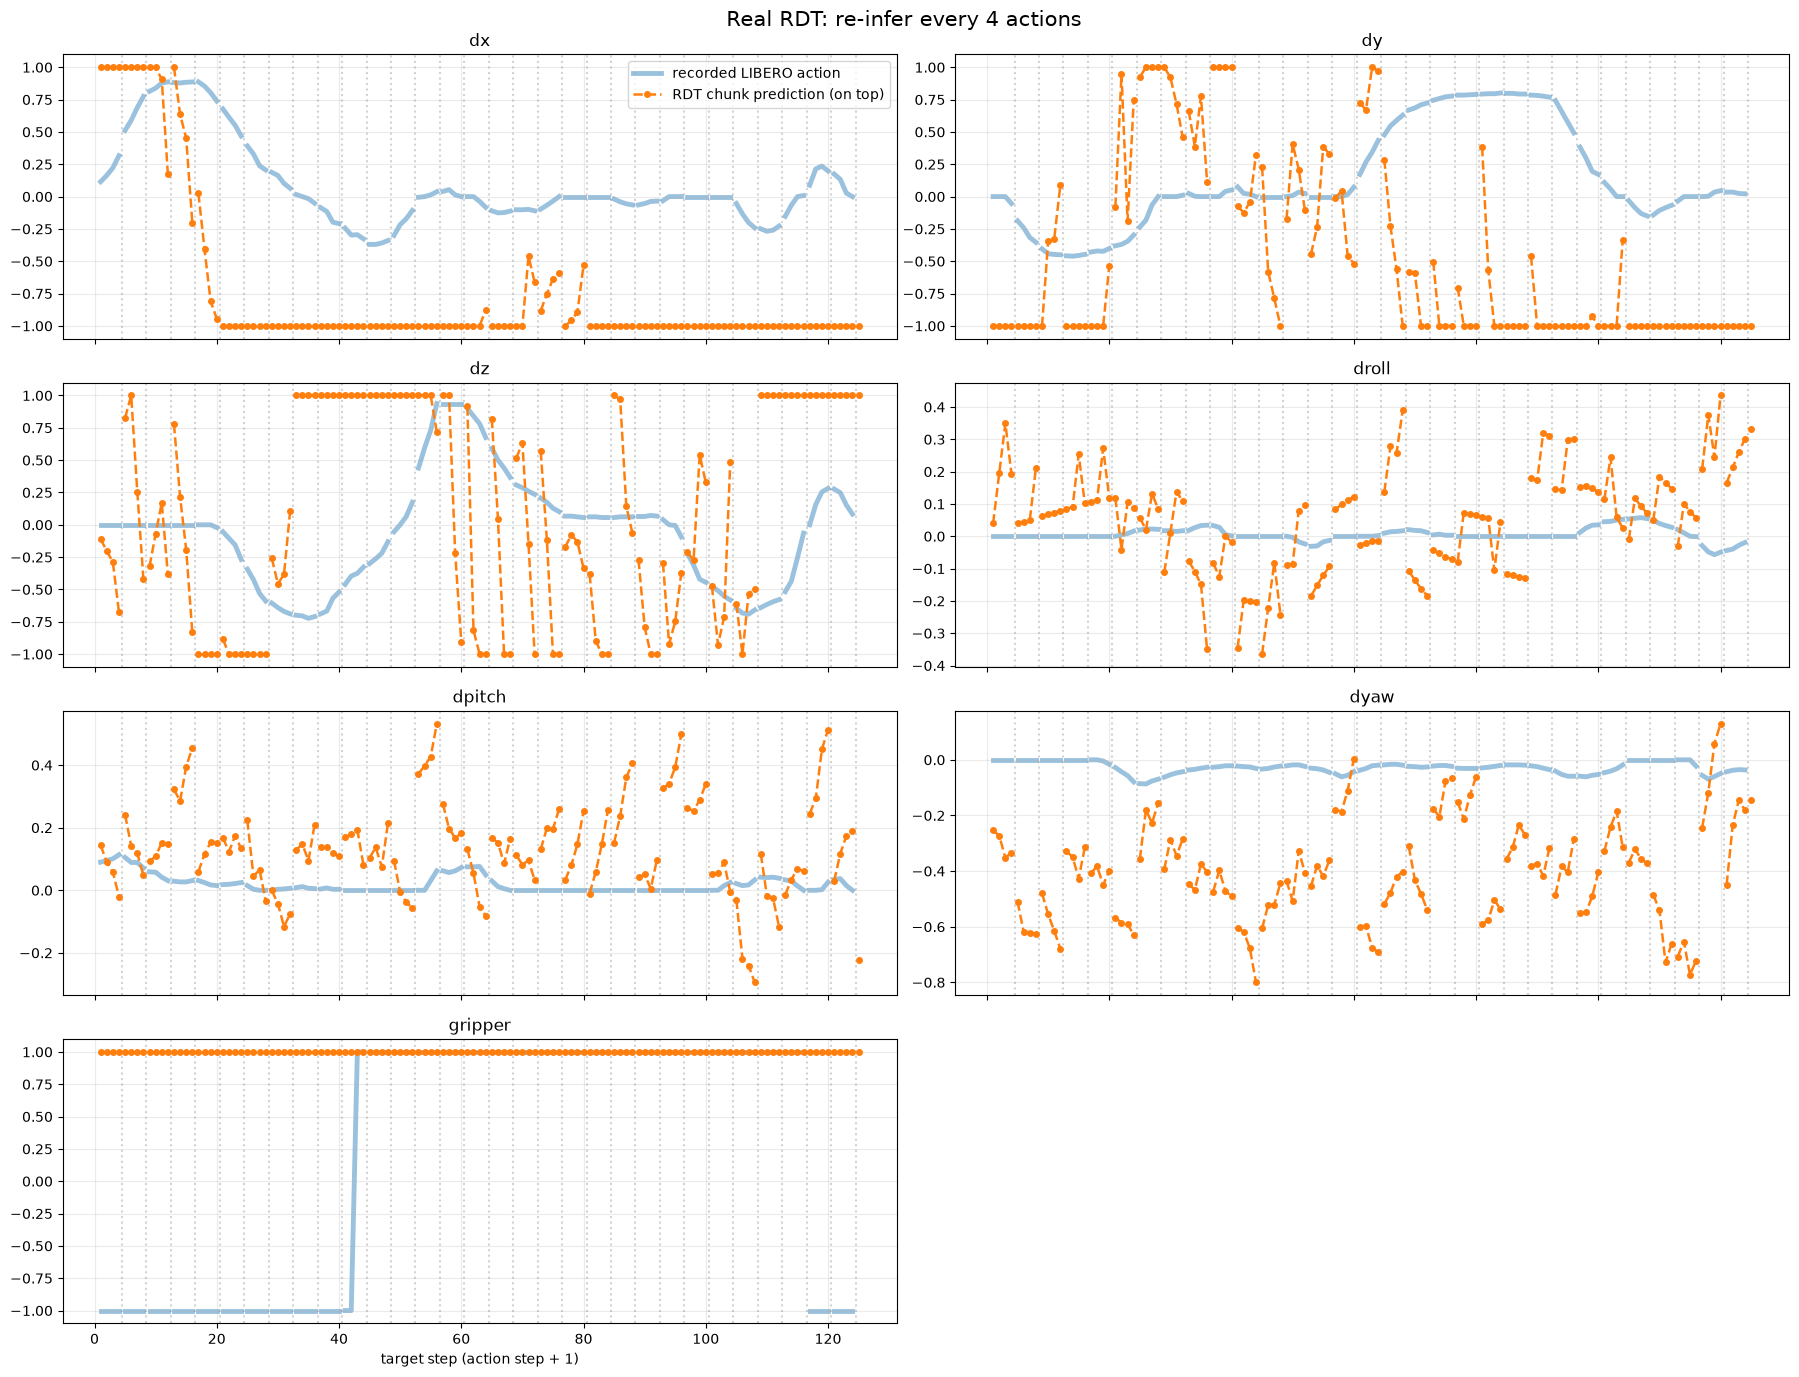

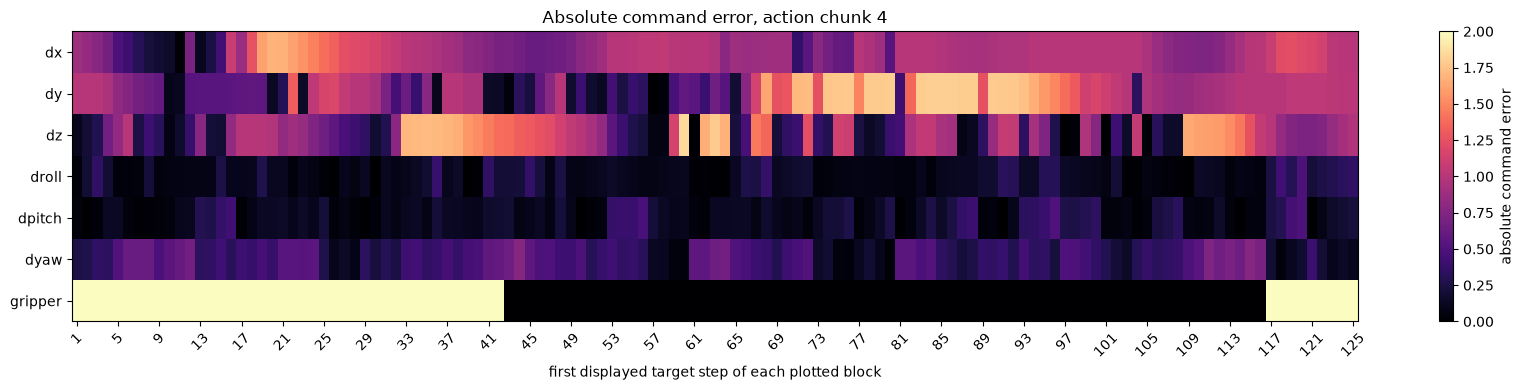

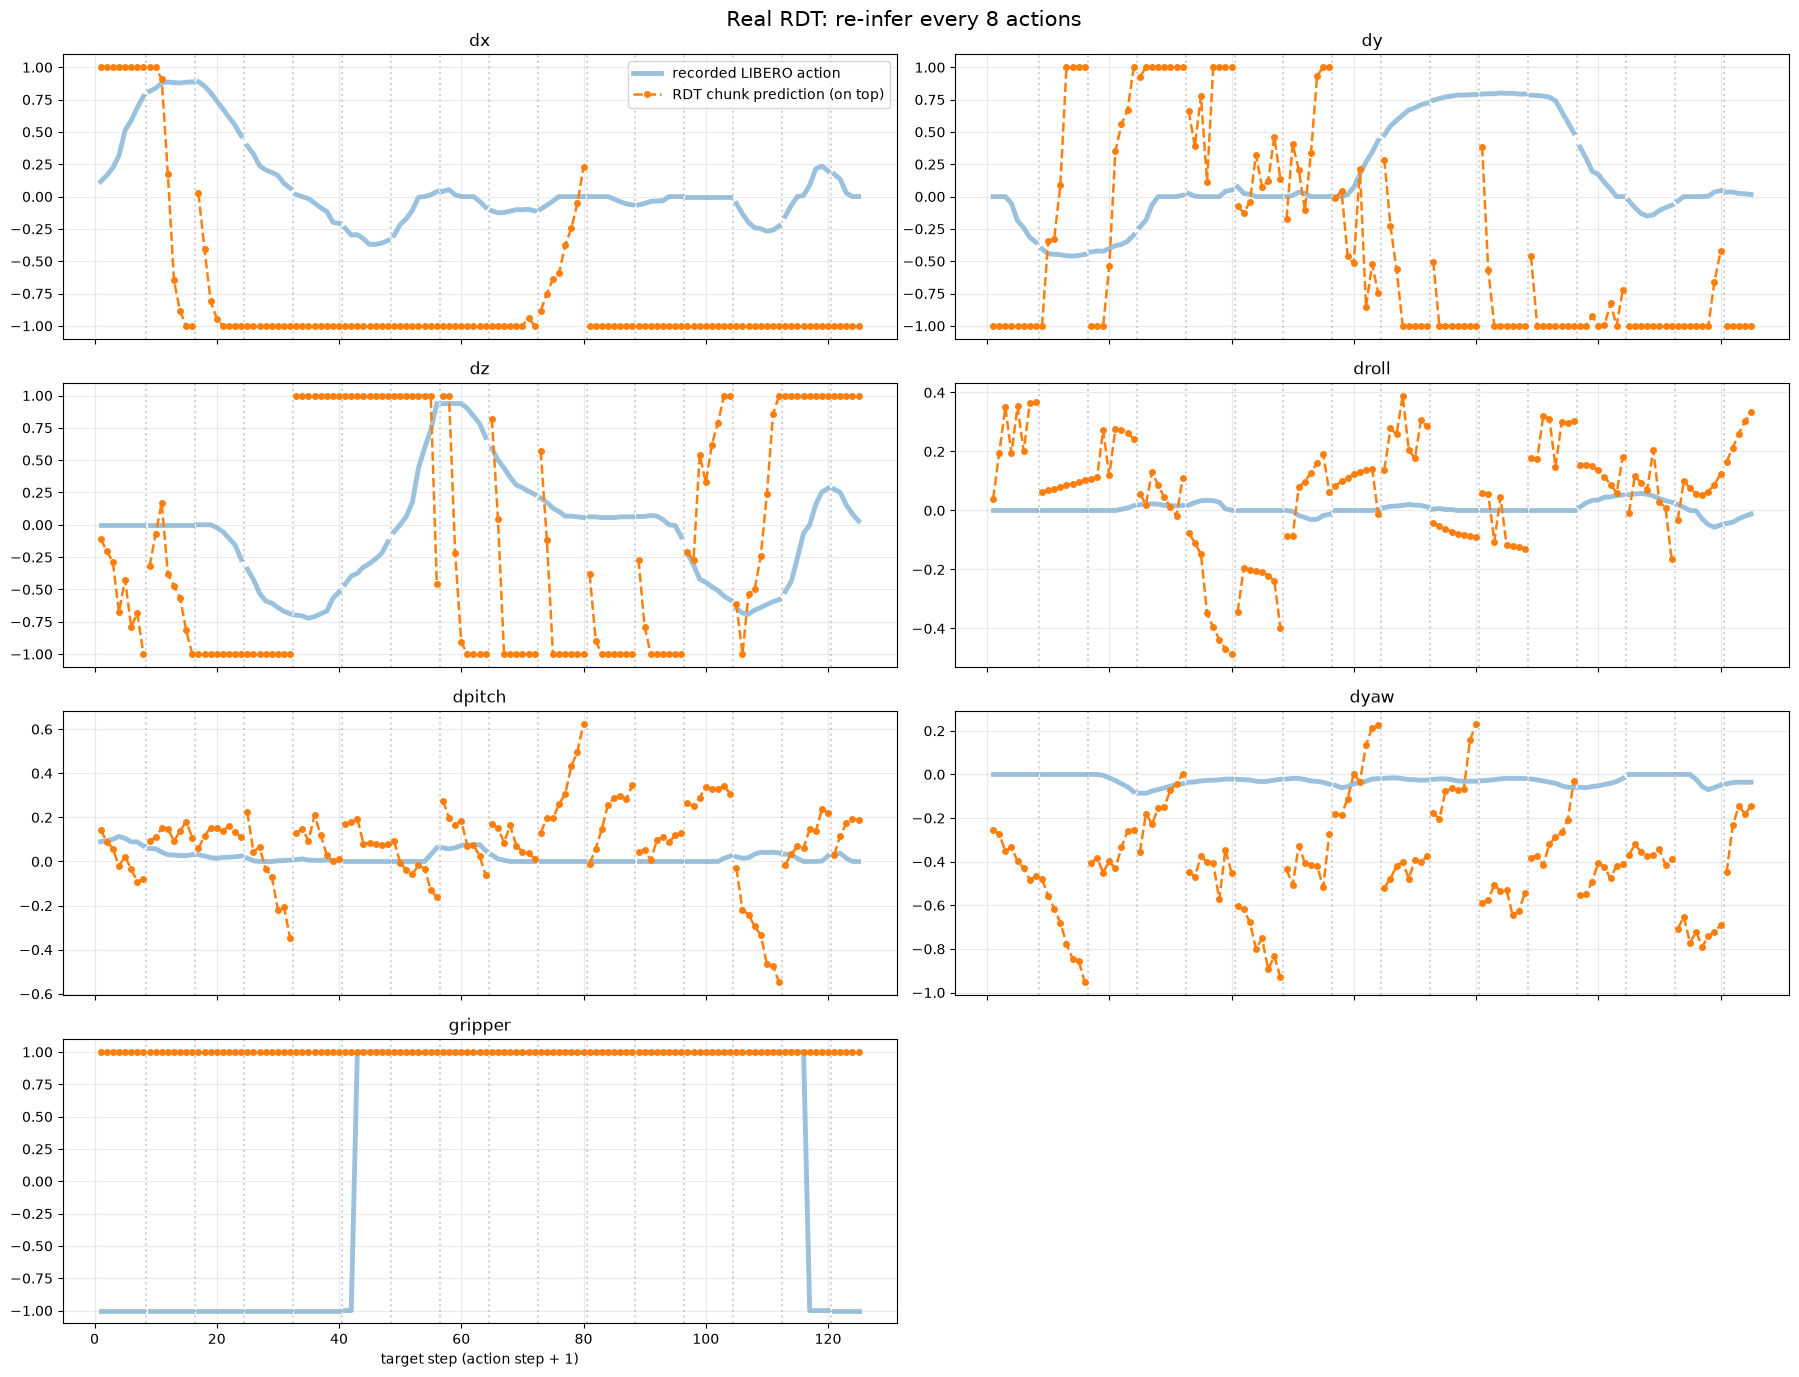

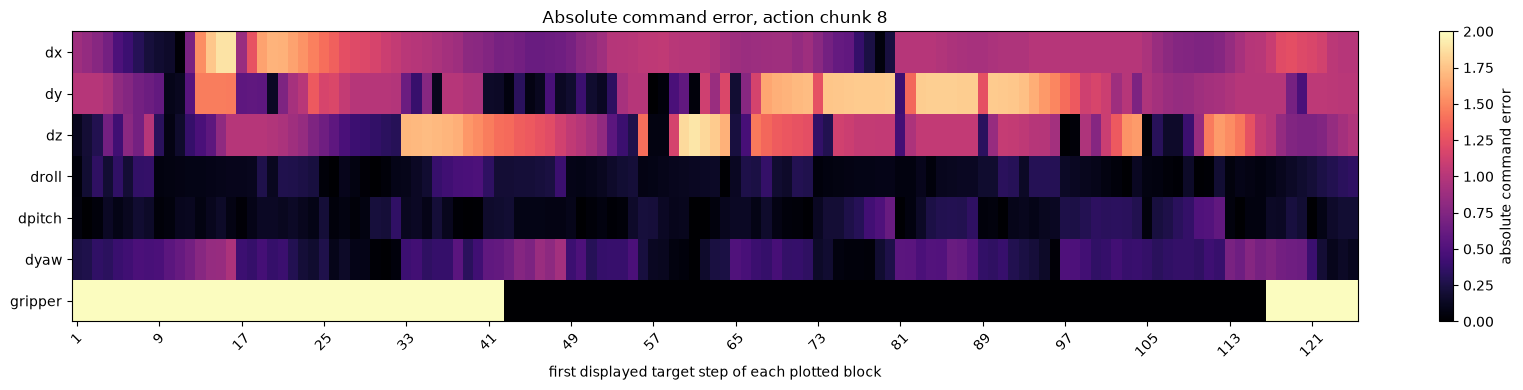

In [40]:
for chunk_size, rows in rdt_chunk_results.items():
    display_steps = np.asarray([row["display_step"] for row in rows])
    anchors = np.asarray([row["anchor"] for row in rows])
    predicted = np.stack([row["predicted_command"] for row in rows])
    recorded = np.stack([row["recorded_command"] for row in rows])

    fig, axes = plt.subplots(4, 2, figsize=(18, 14), sharex=True)
    axes = axes.ravel()
    unique_anchors = list(dict.fromkeys(anchors.tolist()))
    for dim, name in enumerate(chunk_command_names):
        for block_index, anchor in enumerate(unique_anchors):
            selected = anchors == anchor
            axes[dim].plot(
                display_steps[selected], recorded[selected, dim],
                color="tab:blue", linewidth=3.5, alpha=0.45, zorder=1,
                label="recorded LIBERO action" if block_index == 0 else None,
            )
            axes[dim].plot(
                display_steps[selected], predicted[selected, dim],
                color="tab:orange", linestyle="--", marker="o",
                markersize=4, linewidth=1.8, zorder=3,
                label="RDT chunk prediction (on top)" if block_index == 0 else None,
            )
            if block_index > 0:
                axes[dim].axvline(anchor + 0.5, color="gray", linestyle=":", alpha=0.35)
        axes[dim].set_title(name); axes[dim].grid(alpha=0.25)
        if dim == 0: axes[dim].legend()
    axes[-1].axis("off")
    for ax in axes[-2:]: ax.set_xlabel("target step (action step + 1)")
    fig.suptitle(f"Real RDT: re-infer every {chunk_size} actions", fontsize=15)
    plt.tight_layout()

    # Heatmap keeps block order and makes errors within each chunk easy to locate.
    absolute_error = np.abs(predicted - recorded)
    plt.figure(figsize=(17, 4))
    plt.imshow(absolute_error.T, aspect="auto", interpolation="nearest", cmap="magma")
    plt.yticks(np.arange(7), chunk_command_names)
    tick_positions = np.arange(0, len(rows), max(1, chunk_size))
    plt.xticks(tick_positions, [int(display_steps[index]) for index in tick_positions], rotation=45)
    plt.xlabel("first displayed target step of each plotted block")
    plt.title(f"Absolute command error, action chunk {chunk_size}")
    plt.colorbar(label="absolute command error"); plt.tight_layout()

### 11b. Free-sampling check: 5 versus 1,000 denoising steps

The logged `val/horizon_mse/step_XX` values are produced by `compute_loss`: RDT receives a randomly noised version of the ground-truth target chunk and reconstructs it in one forward pass. They are not per-horizon errors from five-step free sampling. Only `val/sample_mse` uses `sample_actions`, and it is aggregated over the entire horizon.

This experiment holds the cached observation and initial Gaussian noise fixed, then compares actual free sampling with 5 and 1,000 scheduler steps. It separately reports absolute-target error, predicted-to-oracle command error, oracle-to-recorded command error, and final predicted-to-recorded command error. The motion metrics exclude the currently known gripper-label/sign problem. **One thousand RDT-1B forwards per anchor is very expensive**; start with the two anchors below, or reduce to one anchor for a smoke test.

In [48]:
RDT_SAMPLER_STEP_COUNTS = (5, 1000)
RDT_SAMPLER_TEST_ANCHORS = (0, 64)  # Different phases; use (0,) first if desired
RDT_SAMPLER_CHUNK_SIZES = (4, 8)
RDT_SAMPLER_SEED = 24680

if "rdt_model" not in globals() or "rdt_siglip" not in globals():
    raise RuntimeError("Run the 'Load RDT and frozen SigLIP' cell first")

sampler_test_anchors = [
    int(anchor) for anchor in RDT_SAMPLER_TEST_ANCHORS
    if anchor in cached_index_by_step
    and all(anchor + offset in cached_index_by_step for offset in range(1, max(RDT_SAMPLER_CHUNK_SIZES) + 1))
]
if not sampler_test_anchors:
    raise RuntimeError("None of the requested sampler-test anchors has eight cached future states")
print("sampler-test anchors:", sampler_test_anchors)
print("sampler step counts:", RDT_SAMPLER_STEP_COUNTS)

rdt_sampler_step_predictions = {}
original_inference_steps = int(rdt_model.runner.num_inference_timesteps)
try:
    for anchor in sampler_test_anchors:
        sample = rdt_cached_dataset[cached_index_by_step[anchor]]
        batch = rdt_collator([sample])
        batch = add_online_siglip_features(
            batch, processor=rdt_siglip_processor, encoder=rdt_siglip,
            cfg=rdt_cfg, device=RDT_DEVICE,
        )
        batch_on_device = {
            key: value.to(RDT_DEVICE) if isinstance(value, torch.Tensor) else value
            for key, value in batch.items()
        }
        for inference_steps in RDT_SAMPLER_STEP_COUNTS:
            rdt_model.runner.num_inference_timesteps = int(inference_steps)
            # Same initial noise for every scheduler-step count at this anchor.
            torch.manual_seed(RDT_SAMPLER_SEED + anchor)
            torch.cuda.manual_seed_all(RDT_SAMPLER_SEED + anchor)
            with torch.inference_mode():
                prediction = rdt_model.sample_actions(batch_on_device)[0].float().cpu().numpy()
            rdt_sampler_step_predictions[(int(inference_steps), anchor)] = prediction
            print(f"finished anchor={anchor}, inference_steps={inference_steps}", flush=True)
        del batch_on_device, batch
        torch.cuda.empty_cache()
finally:
    rdt_model.runner.num_inference_timesteps = original_inference_steps

print("restored default inference steps:", rdt_model.runner.num_inference_timesteps)

sampler-test anchors: [0, 64]
sampler step counts: (5, 1000)
finished anchor=0, inference_steps=5
finished anchor=0, inference_steps=1000
finished anchor=64, inference_steps=5
finished anchor=64, inference_steps=1000
restored default inference steps: 5


[{'inference_steps': 5,
  'chunk_size': 4,
  'comparisons': 8,
  'target_xyz_RMSE_m': 0.03460358455777168,
  'target_rot_RMSE_rad': 0.04472299665212631,
  'predicted_vs_oracle_motion_command_RMSE': 0.5837394595146179,
  'oracle_vs_recorded_motion_command_RMSE': 0.048297856003046036,
  'predicted_vs_recorded_motion_command_RMSE': 0.574493944644928,
  'predicted_position_clip_fraction': 0.875,
  'predicted_rotation_clip_fraction': 0.0},
 {'inference_steps': 5,
  'chunk_size': 8,
  'comparisons': 16,
  'target_xyz_RMSE_m': 0.03456586226820946,
  'target_rot_RMSE_rad': 0.05131975933909416,
  'predicted_vs_oracle_motion_command_RMSE': 0.694248378276825,
  'oracle_vs_recorded_motion_command_RMSE': 0.04541187733411789,
  'predicted_vs_recorded_motion_command_RMSE': 0.6872473955154419,
  'predicted_position_clip_fraction': 0.7708333333333334,
  'predicted_rotation_clip_fraction': 0.0},
 {'inference_steps': 1000,
  'chunk_size': 4,
  'comparisons': 8,
  'target_xyz_RMSE_m': nan,
  'target_rot_R

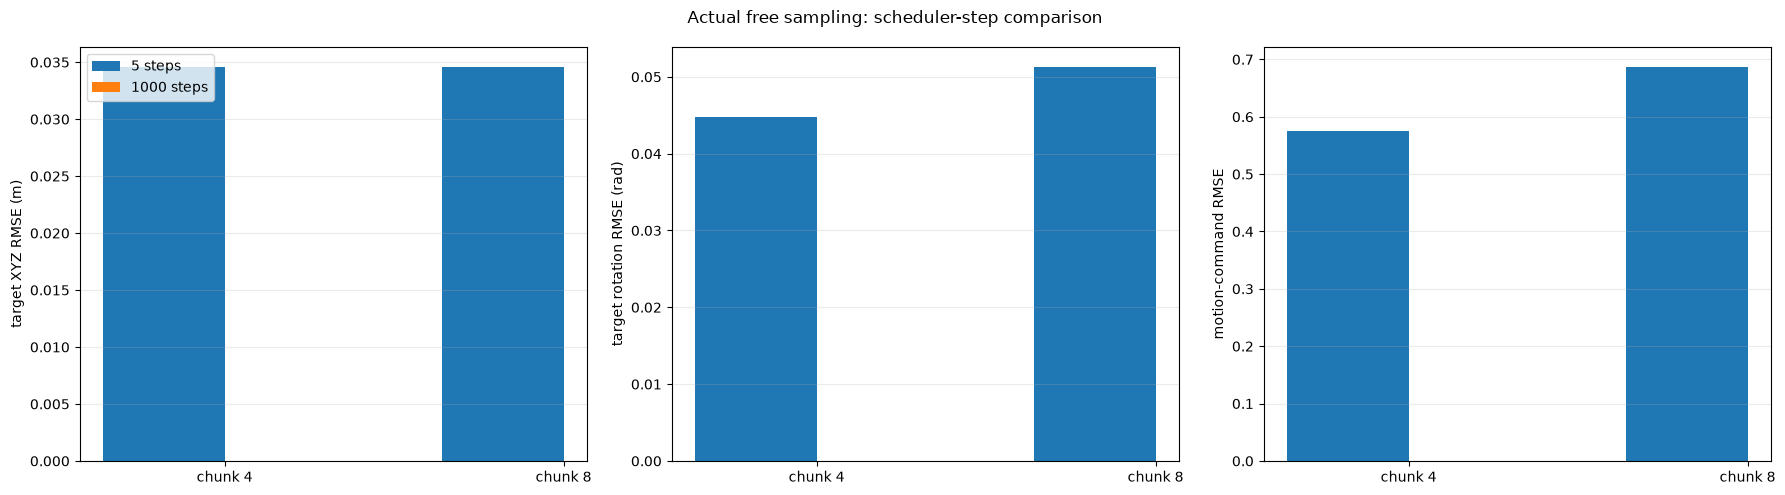

In [49]:
rdt_sampler_step_rows = []
rdt_sampler_offset_rows = []

for inference_steps in RDT_SAMPLER_STEP_COUNTS:
    for chunk_size in RDT_SAMPLER_CHUNK_SIZES:
        target_errors = []
        predicted_commands = []
        oracle_commands_for_test = []
        recorded_commands_for_test = []
        offsets = []
        for anchor in sampler_test_anchors:
            prediction = rdt_sampler_step_predictions[(int(inference_steps), anchor)]
            anchor_sample = rdt_cached_dataset[cached_index_by_step[anchor]]
            anchor_batch = rdt_collator([anchor_sample])
            recorded_targets = anchor_batch["actions"][0].float().numpy()
            valid_targets = anchor_batch["action_time_mask"][0].bool().numpy()
            for offset in range(1, chunk_size + 1):
                if not valid_targets[offset]:
                    continue
                action_step = anchor + offset - 1
                if action_step >= len(rdt_recorded_actions_all) or action_step not in recorded_open_state_by_step:
                    continue
                predicted_target = prediction[offset].copy()
                recorded_target = recorded_targets[offset].copy()
                current_state = recorded_open_state_by_step[action_step]
                target_error = predicted_target - recorded_target
                target_error[3:6] = wrap_to_pi(target_error[3:6])
                predicted_command = rdt_target_states_to_commands(predicted_target[None], current_state[None])[0]
                oracle_command = rdt_target_states_to_commands(recorded_target[None], current_state[None])[0]
                target_errors.append(target_error)
                predicted_commands.append(predicted_command)
                oracle_commands_for_test.append(oracle_command)
                recorded_commands_for_test.append(rdt_recorded_actions_all[action_step])
                offsets.append(offset)

        target_errors = np.asarray(target_errors, dtype=np.float32)
        predicted_commands = np.asarray(predicted_commands, dtype=np.float32)
        oracle_commands_for_test = np.asarray(oracle_commands_for_test, dtype=np.float32)
        recorded_commands_for_test = np.asarray(recorded_commands_for_test, dtype=np.float32)
        offsets = np.asarray(offsets, dtype=int)
        predicted_vs_oracle = predicted_commands[:, :6] - oracle_commands_for_test[:, :6]
        oracle_vs_recorded = oracle_commands_for_test[:, :6] - recorded_commands_for_test[:, :6]
        predicted_vs_recorded = predicted_commands[:, :6] - recorded_commands_for_test[:, :6]
        rdt_sampler_step_rows.append({
            "inference_steps": int(inference_steps),
            "chunk_size": int(chunk_size),
            "comparisons": int(len(target_errors)),
            "target_xyz_RMSE_m": float(np.sqrt(np.mean(target_errors[:, :3] ** 2))),
            "target_rot_RMSE_rad": float(np.sqrt(np.mean(target_errors[:, 3:6] ** 2))),
            "predicted_vs_oracle_motion_command_RMSE": float(np.sqrt(np.mean(predicted_vs_oracle ** 2))),
            "oracle_vs_recorded_motion_command_RMSE": float(np.sqrt(np.mean(oracle_vs_recorded ** 2))),
            "predicted_vs_recorded_motion_command_RMSE": float(np.sqrt(np.mean(predicted_vs_recorded ** 2))),
            "predicted_position_clip_fraction": float(np.mean(np.abs(predicted_commands[:, :3]) >= RDT_MAX_DELTA_POS - 1e-6)),
            "predicted_rotation_clip_fraction": float(np.mean(np.abs(predicted_commands[:, 3:6]) >= RDT_MAX_DELTA_ROT - 1e-6)),
        })
        for offset in range(1, chunk_size + 1):
            selected = offsets == offset
            if not np.any(selected):
                continue
            rdt_sampler_offset_rows.append({
                "inference_steps": int(inference_steps),
                "chunk_size": int(chunk_size),
                "offset": int(offset),
                "target_xyz_RMSE_m": float(np.sqrt(np.mean(target_errors[selected, :3] ** 2))),
                "target_rot_RMSE_rad": float(np.sqrt(np.mean(target_errors[selected, 3:6] ** 2))),
                "predicted_vs_recorded_motion_command_RMSE": float(np.sqrt(np.mean(predicted_vs_recorded[selected] ** 2))),
                "oracle_vs_recorded_motion_command_RMSE": float(np.sqrt(np.mean(oracle_vs_recorded[selected] ** 2))),
            })

display(rdt_sampler_step_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metric_specs = [
    ("target_xyz_RMSE_m", "target XYZ RMSE (m)"),
    ("target_rot_RMSE_rad", "target rotation RMSE (rad)"),
    ("predicted_vs_recorded_motion_command_RMSE", "motion-command RMSE"),
]
x = np.arange(len(RDT_SAMPLER_CHUNK_SIZES)); width = 0.36
for ax, (metric_key, ylabel) in zip(axes, metric_specs):
    for series_index, inference_steps in enumerate(RDT_SAMPLER_STEP_COUNTS):
        values = [next(row[metric_key] for row in rdt_sampler_step_rows if row["inference_steps"] == inference_steps and row["chunk_size"] == chunk) for chunk in RDT_SAMPLER_CHUNK_SIZES]
        ax.bar(x + (series_index - (len(RDT_SAMPLER_STEP_COUNTS) - 1) / 2) * width, values, width=width, label=f"{inference_steps} steps")
    ax.set_xticks(x, [f"chunk {chunk}" for chunk in RDT_SAMPLER_CHUNK_SIZES])
    ax.set_ylabel(ylabel); ax.grid(axis="y", alpha=0.25)
axes[0].legend(); fig.suptitle("Actual free sampling: scheduler-step comparison")
plt.tight_layout()

## 12. Infer directly from saved feature shard(s)

This evaluation reads complete samples directly from the saved training-feature cache. Every sample supplies its cached Qwen KV, cached T5 language embedding, compressed current/history image slots, current state, 64-step absolute-state target, and validity masks. SigLIP is recomputed from the compressed images exactly as it was during training.

The default selects **shard index 10**, which contains 32 samples. `RDT_FEATURE_SHARD_INDICES = [10]` means one shard whose zero-based manifest index is 10. To evaluate the first ten shards instead, use `list(range(10))`.

The cache's `actions` field is an absolute future-state target in model convention `[x, y, z, roll, pitch, yaw, gripper_open]`; it is not a raw LIBERO delta command. Therefore this section compares predicted versus ground-truth future states. Sections 10–11 perform the separate conversion to LIBERO commands. Run this before GPU cleanup.

In [44]:
RDT_FEATURE_SPLIT = "train"
RDT_FEATURE_SHARD_INDICES = [10]  # list(range(10)) evaluates the first 10 shards
RDT_FEATURE_BATCH_SIZE = 1
RDT_FEATURE_PLOT_TARGET_INDEX = 1  # target[0] is current state
RDT_FEATURE_RANDOM_SEED = 12345

if "rdt_model" not in globals() or "rdt_siglip" not in globals():
    raise RuntimeError("Run the 'Load RDT and frozen SigLIP' cell before saved-shard inference")
feature_manifest = RDT_CACHE_ROOT / RDT_FEATURE_SPLIT / "manifest.jsonl"
saved_feature_dataset = CachedFeatureDataset(
    feature_manifest, required_keys=ONLINE_SIGLIP_REQUIRED_KEYS,
)
manifest_rows = [
    json.loads(line) for line in feature_manifest.read_text(encoding="utf-8").splitlines()
    if line.strip()
]
for shard_index in RDT_FEATURE_SHARD_INDICES:
    if shard_index < 0 or shard_index >= len(saved_feature_dataset.contiguous_ranges):
        raise IndexError(f"Shard index {shard_index} is outside 0..{len(saved_feature_dataset.contiguous_ranges)-1}")

saved_feature_indices = []
selected_shard_rows = []
for shard_index in RDT_FEATURE_SHARD_INDICES:
    index_range = saved_feature_dataset.contiguous_ranges[shard_index]
    saved_feature_indices.extend(index_range)
    row = manifest_rows[shard_index]
    selected_shard_rows.append(row)
    print(
        f"shard index={shard_index} path={row.get('path')} "
        f"samples={len(index_range)} global_range=[{index_range.start}, {index_range.stop})"
    )
print("total selected cached samples:", len(saved_feature_indices))

shard index=10 path=shard_000000010.pt samples=32 global_range=[320, 352)
total selected cached samples: 32


In [45]:
# Make this section usable if the earlier inference cells were skipped after model loading.
if "rdt_collator" not in globals():
    from thinkflow_rdt.data import RDTOnlineSiglipBatchCollator
    rdt_collator = RDTOnlineSiglipBatchCollator(
        max_lang_tokens=rdt_cfg.model.max_lang_tokens,
        pred_horizon=rdt_cfg.model.pred_horizon,
        feature_dim=rdt_cfg.model.qwen_hidden_size,
        state_dim=rdt_cfg.model.state_dim,
        action_dim=rdt_cfg.model.action_dim,
        lang_token_dim=rdt_cfg.model.lang_token_dim,
        qwen_kv_dim=rdt_cfg.model.qwen_kv_dim,
    )

saved_feature_predictions = []
saved_feature_targets = []
saved_feature_time_masks = []
saved_feature_dim_masks = []
saved_feature_metadata_rows = []

for batch_start in range(0, len(saved_feature_indices), RDT_FEATURE_BATCH_SIZE):
    batch_indices = saved_feature_indices[batch_start:batch_start + RDT_FEATURE_BATCH_SIZE]
    samples = [saved_feature_dataset[index] for index in batch_indices]
    batch = rdt_collator(samples)
    batch = add_online_siglip_features(
        batch, processor=rdt_siglip_processor, encoder=rdt_siglip,
        cfg=rdt_cfg, device=RDT_DEVICE,
    )
    batch_on_device = {
        key: value.to(RDT_DEVICE) if isinstance(value, torch.Tensor) else value
        for key, value in batch.items()
    }
    torch.manual_seed(RDT_FEATURE_RANDOM_SEED + int(batch_indices[0]))
    torch.cuda.manual_seed_all(RDT_FEATURE_RANDOM_SEED + int(batch_indices[0]))
    with torch.inference_mode():
        prediction = rdt_model.sample_actions(batch_on_device).float().cpu()
    saved_feature_predictions.append(prediction)
    saved_feature_targets.append(batch["actions"].float().cpu())
    saved_feature_time_masks.append(batch["action_time_mask"].bool().cpu())
    saved_feature_dim_masks.append(batch["action_dim_mask"].bool().cpu())
    for dataset_index, sample in zip(batch_indices, samples):
        saved_feature_metadata_rows.append({
            "dataset_index": int(dataset_index),
            "episode_id": sample.get("episode_id"),
            "step_idx": int(sample.get("step_idx", -1)),
            "source": sample.get("_path"),
        })
    completed = min(batch_start + len(batch_indices), len(saved_feature_indices))
    print(f"inferred saved samples {completed}/{len(saved_feature_indices)}", flush=True)
    del batch_on_device, prediction
    torch.cuda.empty_cache()

saved_feature_predictions = torch.cat(saved_feature_predictions, dim=0).numpy()
saved_feature_targets = torch.cat(saved_feature_targets, dim=0).numpy()
saved_feature_time_masks = torch.cat(saved_feature_time_masks, dim=0).numpy()
saved_feature_dim_masks = torch.cat(saved_feature_dim_masks, dim=0).numpy()
saved_feature_valid = saved_feature_time_masks[:, :, None] & saved_feature_dim_masks[:, None, :]
print("prediction shape:", saved_feature_predictions.shape)
print("target shape:", saved_feature_targets.shape)
print("valid target elements:", int(saved_feature_valid.sum()))
display(saved_feature_metadata_rows[:5])

inferred saved samples 1/32
inferred saved samples 2/32
inferred saved samples 3/32
inferred saved samples 4/32
inferred saved samples 5/32
inferred saved samples 6/32
inferred saved samples 7/32
inferred saved samples 8/32
inferred saved samples 9/32
inferred saved samples 10/32
inferred saved samples 11/32
inferred saved samples 12/32
inferred saved samples 13/32
inferred saved samples 14/32
inferred saved samples 15/32
inferred saved samples 16/32
inferred saved samples 17/32
inferred saved samples 18/32
inferred saved samples 19/32
inferred saved samples 20/32
inferred saved samples 21/32
inferred saved samples 22/32
inferred saved samples 23/32
inferred saved samples 24/32
inferred saved samples 25/32
inferred saved samples 26/32
inferred saved samples 27/32
inferred saved samples 28/32
inferred saved samples 29/32
inferred saved samples 30/32
inferred saved samples 31/32
inferred saved samples 32/32
prediction shape: (32, 64, 7)
target shape: (32, 64, 7)
valid target elements: 14

[{'dataset_index': 320,
  'episode_id': 'pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo:demo_11',
  'step_idx': 64,
  'source': '/home/ubuntu/ThinkFlow-RDT-1B/thinkflow-libero-features-b0/libero_object/train/shard_000000010.pt'},
 {'dataset_index': 321,
  'episode_id': 'pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo:demo_11',
  'step_idx': 65,
  'source': '/home/ubuntu/ThinkFlow-RDT-1B/thinkflow-libero-features-b0/libero_object/train/shard_000000010.pt'},
 {'dataset_index': 322,
  'episode_id': 'pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo:demo_11',
  'step_idx': 66,
  'source': '/home/ubuntu/ThinkFlow-RDT-1B/thinkflow-libero-features-b0/libero_object/train/shard_000000010.pt'},
 {'dataset_index': 323,
  'episode_id': 'pick_up_the_alphabet_soup_and_place_it_in_the_basket_demo:demo_11',
  'step_idx': 67,
  'source': '/home/ubuntu/ThinkFlow-RDT-1B/thinkflow-libero-features-b0/libero_object/train/shard_000000010.pt'},
 {'dataset_index': 324,
  'episode_i

[{'dimension': 'x',
  'valid_values': 2020,
  'MAE': 0.04244327172636986,
  'RMSE': 0.056504592299461365,
  'correlation': -0.04007310485940181},
 {'dimension': 'y',
  'valid_values': 2020,
  'MAE': 0.14496208727359772,
  'RMSE': 0.18362589180469513,
  'correlation': 0.6244569312579594},
 {'dimension': 'z',
  'valid_values': 2020,
  'MAE': 0.049064114689826965,
  'RMSE': 0.059850070625543594,
  'correlation': 0.3290163893802748},
 {'dimension': 'roll',
  'valid_values': 2020,
  'MAE': 0.047425154596567154,
  'RMSE': 0.058496955782175064,
  'correlation': -0.538820100610502},
 {'dimension': 'pitch',
  'valid_values': 2020,
  'MAE': 0.10365632176399231,
  'RMSE': 0.15187649428844452,
  'correlation': -0.1087239614989474},
 {'dimension': 'yaw',
  'valid_values': 2020,
  'MAE': 0.1351647824048996,
  'RMSE': 0.15737660229206085,
  'correlation': 0.5397200829967249},
 {'dimension': 'gripper_open',
  'valid_values': 2020,
  'MAE': 0.03980415314435959,
  'RMSE': 0.1519005000591278,
  'correlat

gripper-open classification accuracy: 0.9787128712871287


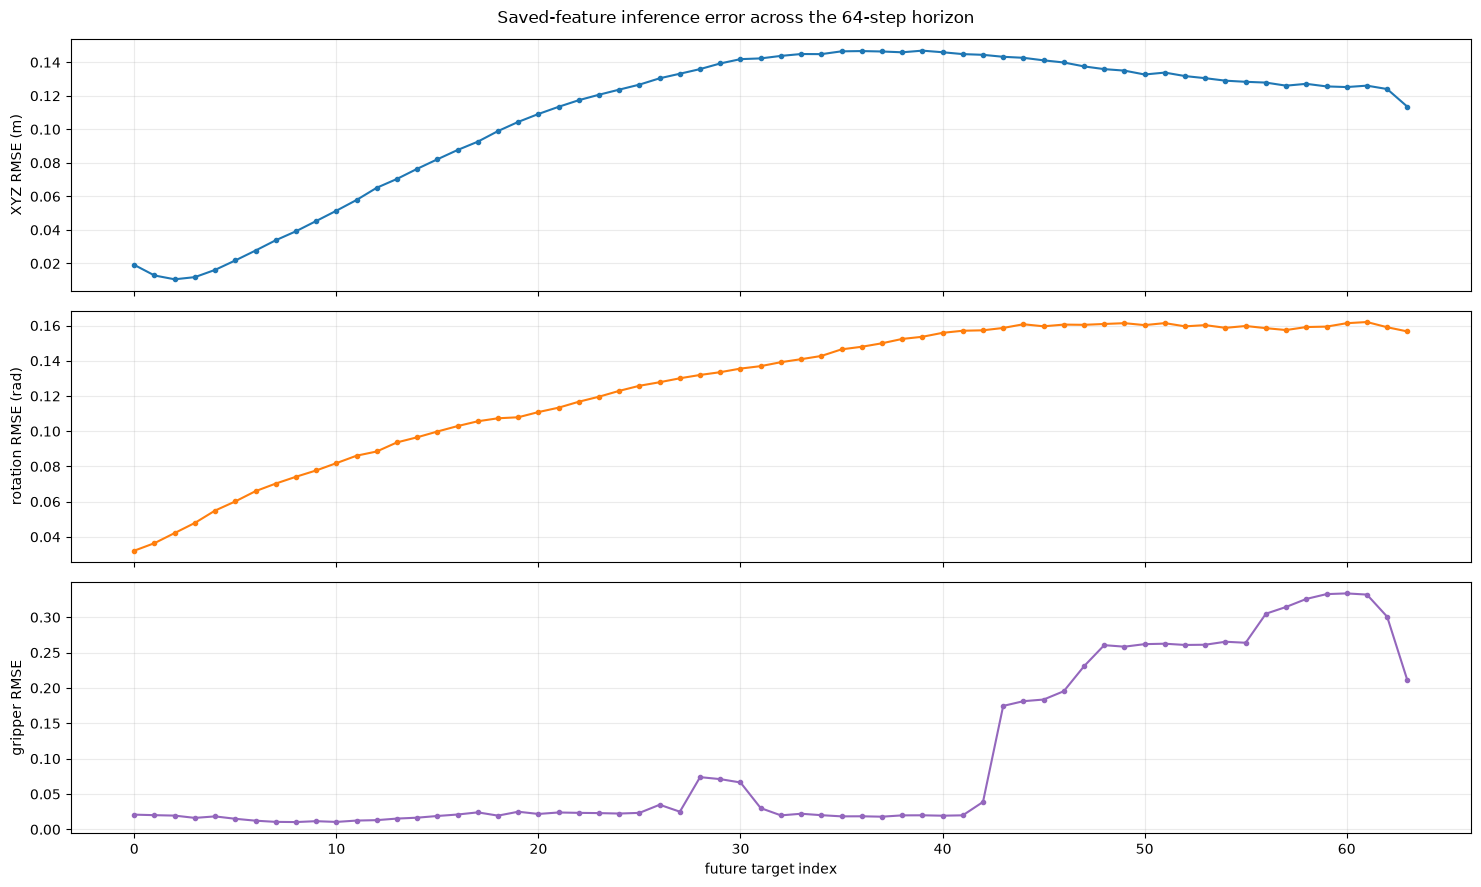

In [46]:
saved_state_names = ["x", "y", "z", "roll", "pitch", "yaw", "gripper_open"]
saved_feature_error = saved_feature_predictions - saved_feature_targets
saved_feature_error[:, :, 3:6] = np.arctan2(
    np.sin(saved_feature_error[:, :, 3:6]),
    np.cos(saved_feature_error[:, :, 3:6]),
)
saved_feature_metrics = []
for dim, name in enumerate(saved_state_names):
    valid = saved_feature_valid[:, :, dim]
    errors = saved_feature_error[:, :, dim][valid]
    predicted_values = saved_feature_predictions[:, :, dim][valid]
    target_values = saved_feature_targets[:, :, dim][valid]
    correlation = np.corrcoef(target_values, predicted_values)[0, 1] if target_values.std() > 1e-8 and predicted_values.std() > 1e-8 else np.nan
    saved_feature_metrics.append({
        "dimension": name,
        "valid_values": int(valid.sum()),
        "MAE": float(np.mean(np.abs(errors))),
        "RMSE": float(np.sqrt(np.mean(errors ** 2))),
        "correlation": float(correlation),
    })
display(saved_feature_metrics)
gripper_valid = saved_feature_valid[:, :, 6]
gripper_accuracy = np.mean(
    (saved_feature_predictions[:, :, 6][gripper_valid] >= 0.5)
    == (saved_feature_targets[:, :, 6][gripper_valid] >= 0.5)
)
print("gripper-open classification accuracy:", float(gripper_accuracy))

# Component RMSE as prediction distance increases from target[0] to target[63].
def masked_horizon_rmse(start, stop):
    component_error = saved_feature_error[:, :, start:stop]
    component_valid = saved_feature_valid[:, :, start:stop]
    numerator = np.sum((component_error ** 2) * component_valid, axis=(0, 2))
    denominator = np.maximum(np.sum(component_valid, axis=(0, 2)), 1)
    return np.sqrt(numerator / denominator)

saved_xyz_horizon_rmse = masked_horizon_rmse(0, 3)
saved_rotation_horizon_rmse = masked_horizon_rmse(3, 6)
saved_gripper_horizon_rmse = masked_horizon_rmse(6, 7)
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
axes[0].plot(saved_xyz_horizon_rmse, marker="o", markersize=3); axes[0].set_ylabel("XYZ RMSE (m)")
axes[1].plot(saved_rotation_horizon_rmse, marker="o", markersize=3, color="tab:orange"); axes[1].set_ylabel("rotation RMSE (rad)")
axes[2].plot(saved_gripper_horizon_rmse, marker="o", markersize=3, color="tab:purple"); axes[2].set_ylabel("gripper RMSE"); axes[2].set_xlabel("future target index")
for ax in axes: ax.grid(alpha=0.25)
fig.suptitle("Saved-feature inference error across the 64-step horizon")
plt.tight_layout()

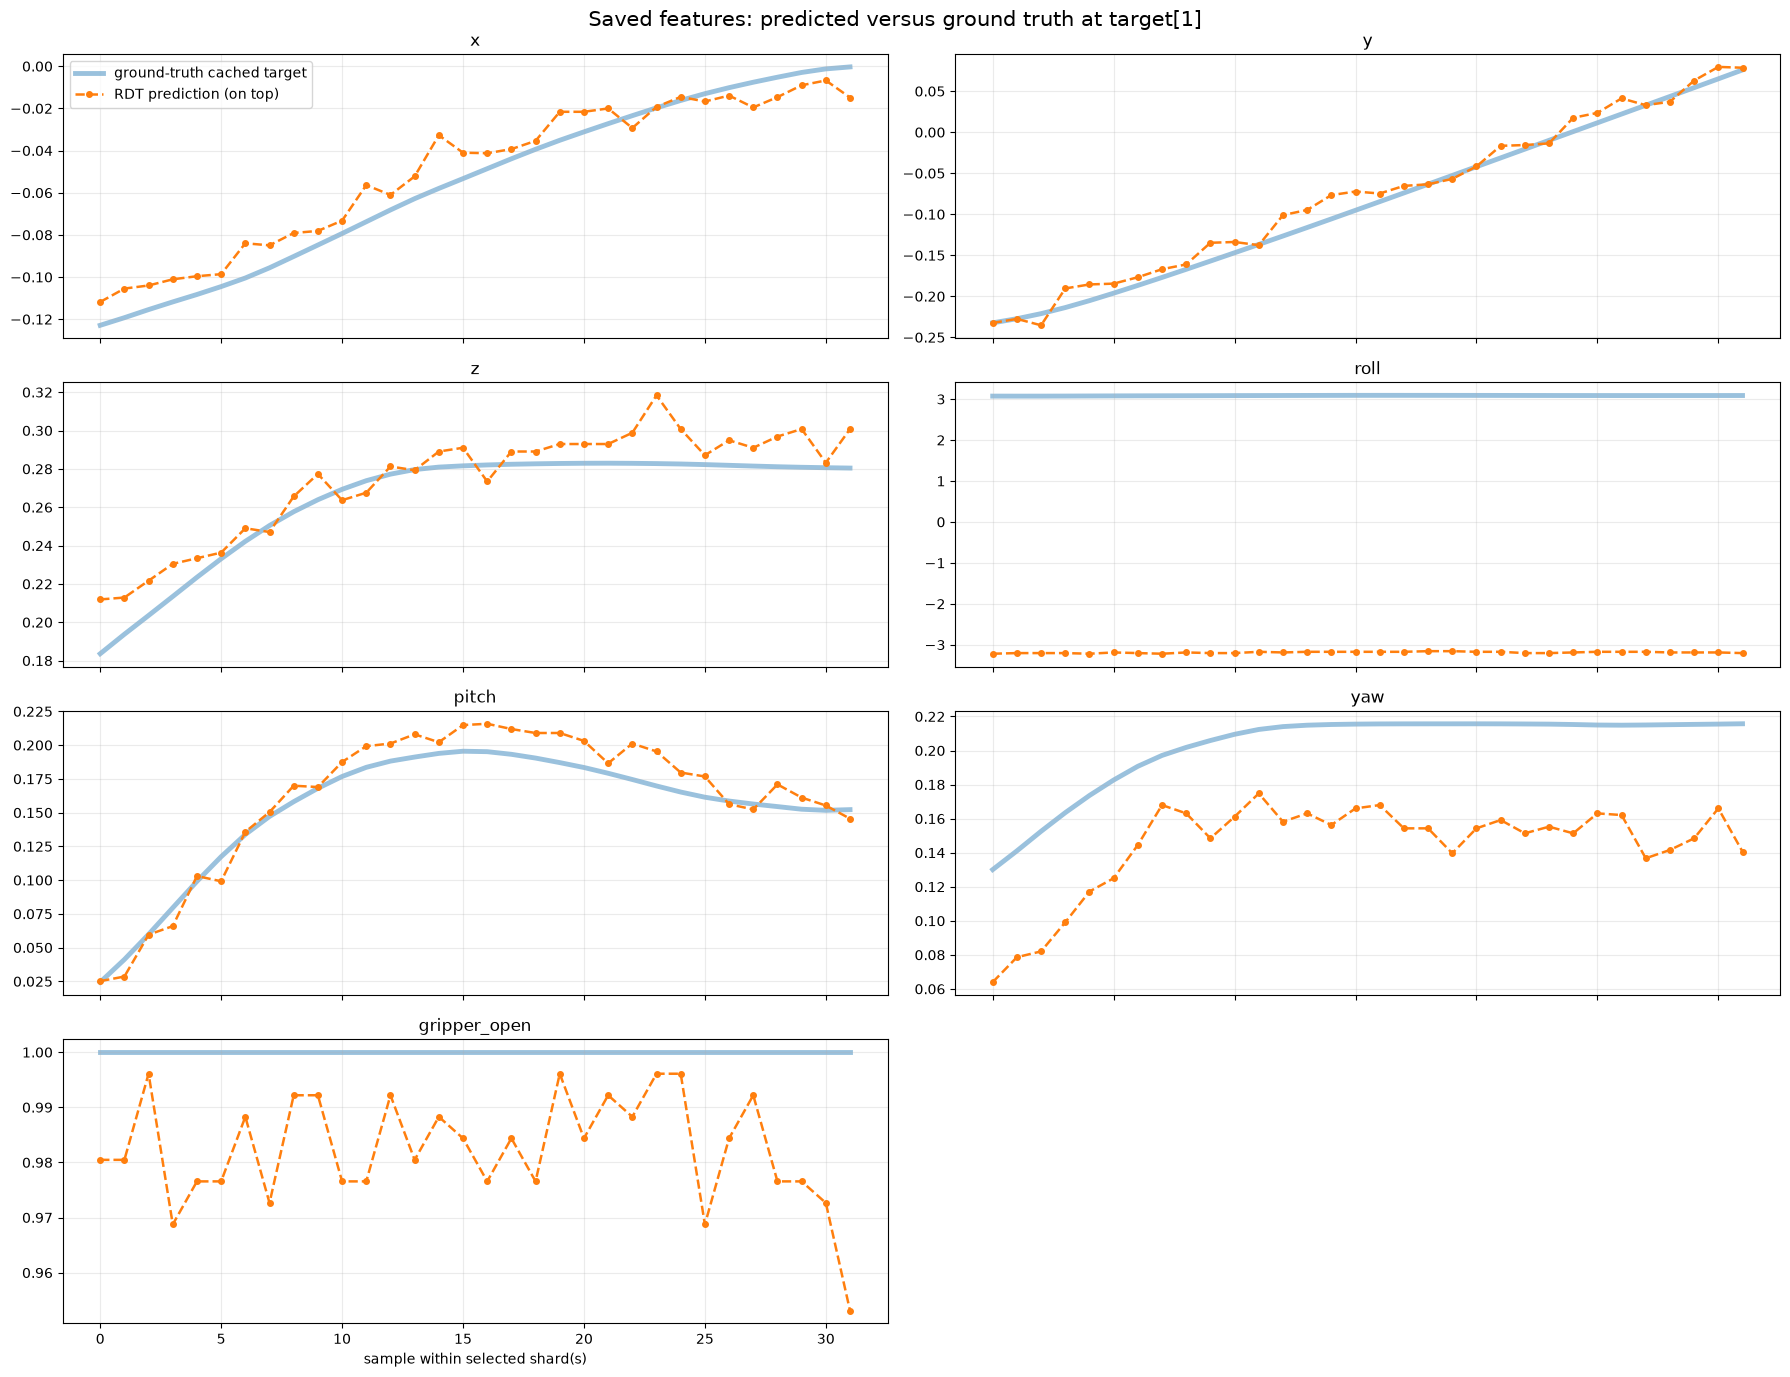

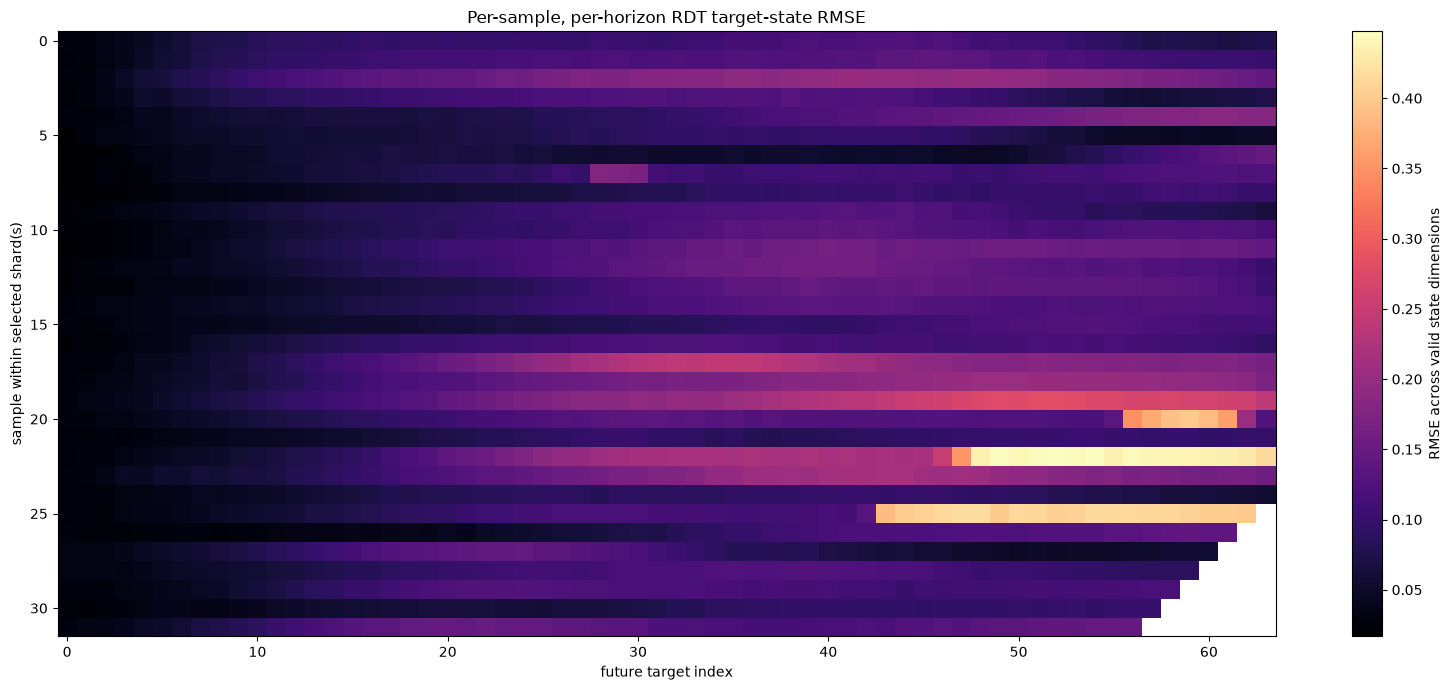

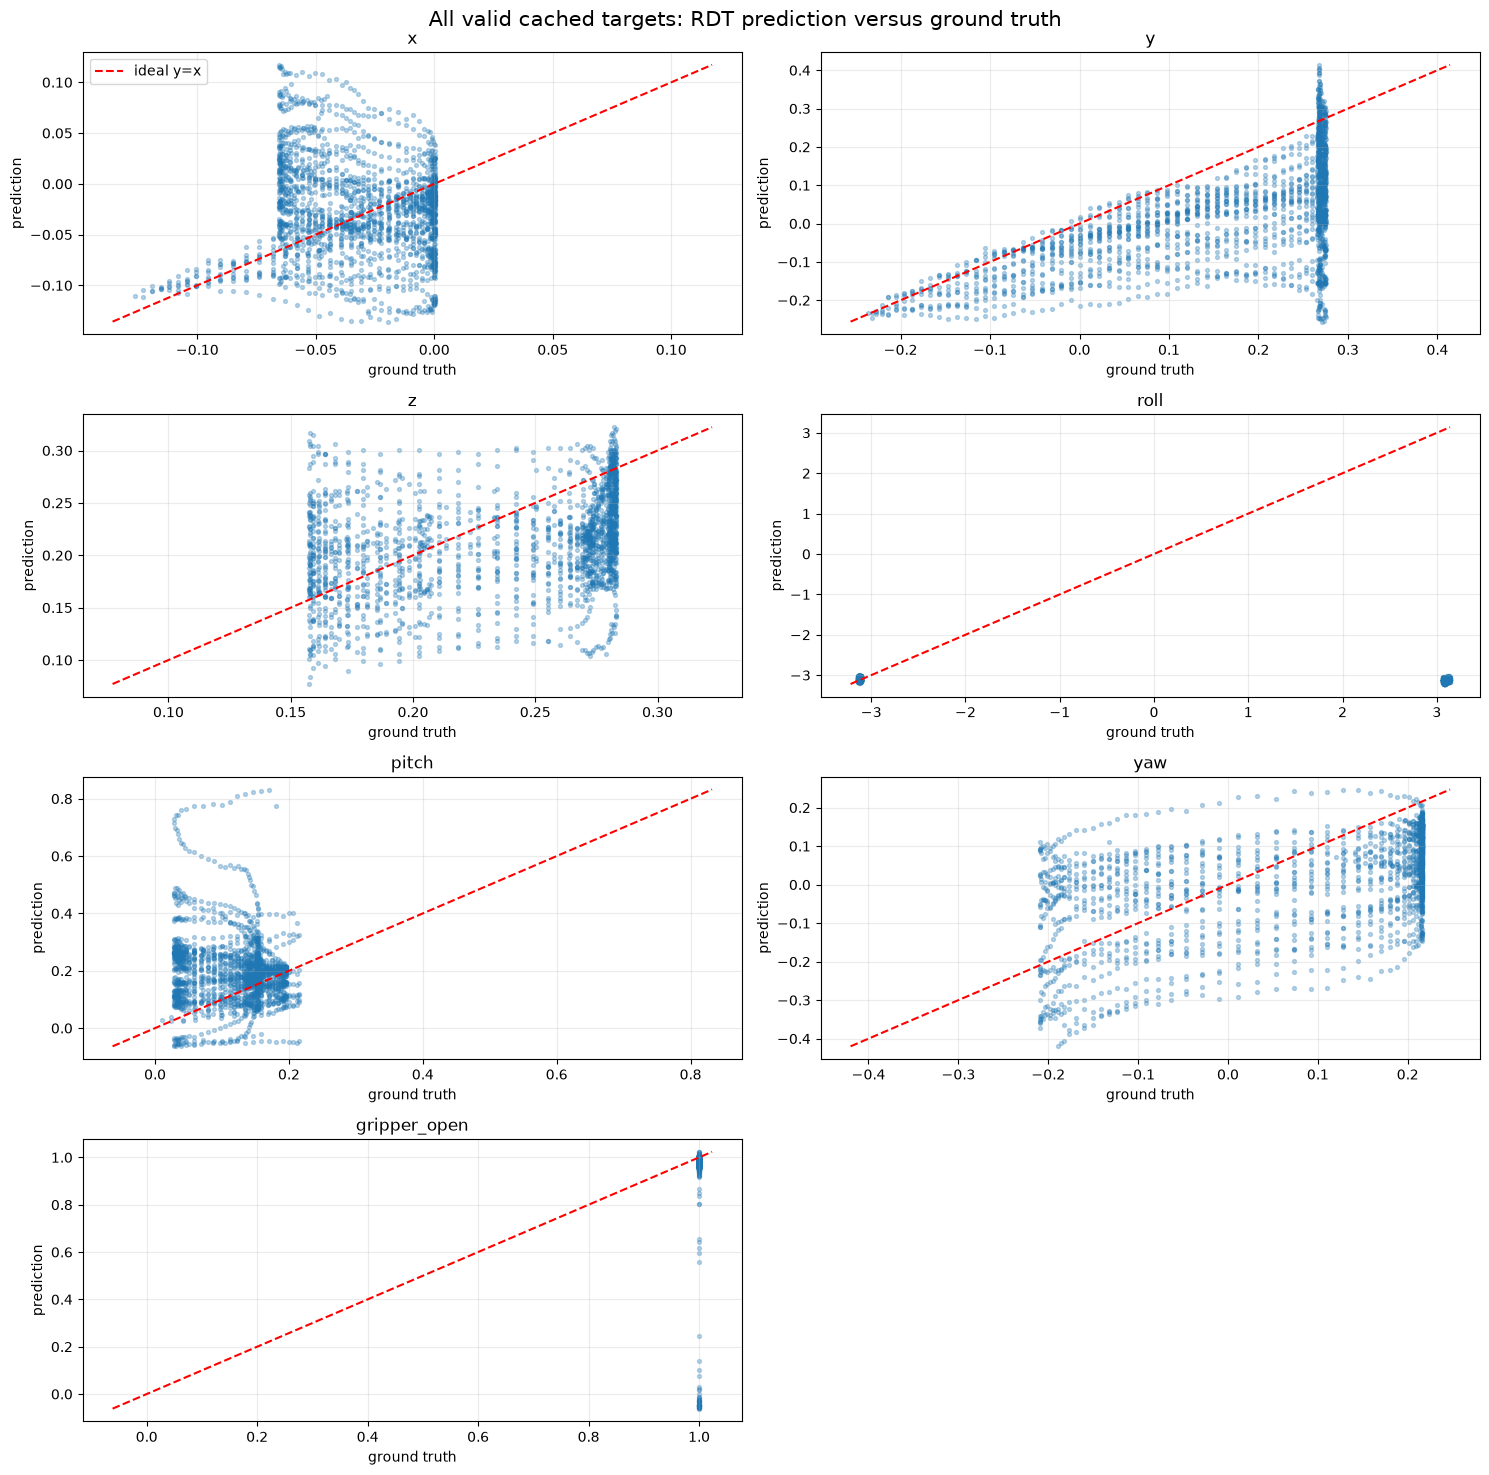

In [47]:
plot_target_index = min(RDT_FEATURE_PLOT_TARGET_INDEX, rdt_cfg.model.pred_horizon - 1)
sample_axis = np.arange(len(saved_feature_predictions))
fig, axes = plt.subplots(4, 2, figsize=(18, 14), sharex=True)
axes = axes.ravel()
for dim, name in enumerate(saved_state_names):
    valid_samples = saved_feature_valid[:, plot_target_index, dim]
    axes[dim].plot(
        sample_axis[valid_samples], saved_feature_targets[valid_samples, plot_target_index, dim],
        color="tab:blue", linewidth=3.5, alpha=0.45, zorder=1, label="ground-truth cached target",
    )
    axes[dim].plot(
        sample_axis[valid_samples], saved_feature_predictions[valid_samples, plot_target_index, dim],
        color="tab:orange", linestyle="--", marker="o", markersize=4, linewidth=1.8, zorder=3, label="RDT prediction (on top)",
    )
    axes[dim].set_title(name); axes[dim].grid(alpha=0.25)
    if dim == 0: axes[dim].legend()
axes[-1].axis("off")
for ax in axes[-2:]: ax.set_xlabel("sample within selected shard(s)")
fig.suptitle(f"Saved features: predicted versus ground truth at target[{plot_target_index}]", fontsize=15)
plt.tight_layout()

# Sample-by-horizon heatmap: mean error across the seven state dimensions.
masked_squared_error = (saved_feature_error ** 2) * saved_feature_valid
valid_dims_per_token = np.maximum(saved_feature_valid.sum(axis=2), 1)
sample_horizon_rmse = np.sqrt(masked_squared_error.sum(axis=2) / valid_dims_per_token)
sample_horizon_rmse[~saved_feature_time_masks] = np.nan
plt.figure(figsize=(16, 7))
plt.imshow(sample_horizon_rmse, aspect="auto", interpolation="nearest", cmap="magma")
plt.xlabel("future target index"); plt.ylabel("sample within selected shard(s)")
plt.title("Per-sample, per-horizon RDT target-state RMSE")
plt.colorbar(label="RMSE across valid state dimensions"); plt.tight_layout()

# Predicted-versus-ground-truth scatter over all valid samples and horizons.
fig, axes = plt.subplots(4, 2, figsize=(15, 15))
axes = axes.ravel()
for dim, name in enumerate(saved_state_names):
    valid = saved_feature_valid[:, :, dim]
    target_values = saved_feature_targets[:, :, dim][valid]
    predicted_values = saved_feature_predictions[:, :, dim][valid]
    axes[dim].scatter(target_values, predicted_values, s=8, alpha=0.3)
    low = min(float(target_values.min()), float(predicted_values.min()))
    high = max(float(target_values.max()), float(predicted_values.max()))
    axes[dim].plot([low, high], [low, high], color="red", linestyle="--", label="ideal y=x")
    axes[dim].set_title(name); axes[dim].set_xlabel("ground truth"); axes[dim].set_ylabel("prediction"); axes[dim].grid(alpha=0.25)
    if dim == 0: axes[dim].legend()
axes[-1].axis("off")
fig.suptitle("All valid cached targets: RDT prediction versus ground truth", fontsize=15)
plt.tight_layout()

In [ ]:
# Optional: release GPU memory after preserving NumPy predictions and plots.
del rdt_model, rdt_siglip, rdt_siglip_processor
gc.collect(); torch.cuda.empty_cache()
print("Released RDT and SigLIP GPU memory")